In [ ]:
! pip install -q torchattacks 

In [2]:
import os
import json
import torch
import torchvision
from PIL import Image
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.auto import tqdm
import random
import gc
from torch.amp import autocast, GradScaler
import torch.nn as nn
from scipy.stats import norm
import cv2
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import math
import numpy as np
from torchvision.datasets import CIFAR10
import glob
from torchvision import transforms
import torchattacks
import torch.nn.functional as F
import pandas as pd

%config InlineBackend.figure_format = 'retina'

In [3]:
class JNDModel:
    
    def __init__(self, L_min, L_max, t = 1, phi_d = 1e-3, p = 0.75):
        self.L_min = L_min
        self.L_max = L_max
        self.t = t
        self.phi_d = phi_d
        self.p = p
        self.L0 = 1e-6

    def _K(self, lambd, b1 = 0.98, b2 = 0.1, lambd1 = 2e-2):
        lambd = np.asarray(lambd, dtype = np.float64)
        return np.where(lambd <= 1, b1 * (1 + lambd1 / lambd), lambd ** b2)
    
    def _A(self, La, a1 = 4.8e6, a2 = 7.1e3, a3 = 4.5e-4): 
        return 1 + (a1 * La) ** 0.5 + a2 * La * (1 + (a3 * La) ** 0.5)
    
    def _Lambda(self, lambd):
        return lambd * self._K(lambd)
    
    def _eta(self, La, L3 = 1e6, L4 = 1, a4 = 600):
        return 1 + L3 / (1 + a4 * La * (L4 + La))
    
    def _C(self, La, t):
        tao_min = 0.05
        T = t / (tao_min * self._eta(La))
        return 1 + 1 / T 
    
    def _func_phi_1(self, La, c2 = 0.25, L1 = 10, L2 = 2.6e-5):
        return (1 + L1 / (L2 + La)) ** c2
    
    def _S(self, La, theta_1 = 6.1, a_d = 2, inf_phi_1 = 1):
        phi_0_min = 0.5 * (1 / 60) * (np.pi / 180)
        phi_1 = self._func_phi_1(La)
        phi_0 = phi_1 * phi_0_min / inf_phi_1
        
        return (theta_1 * phi_0 / self.phi_d + 1.0) ** a_d
    
    def _l(self, La):
        return self.L0 * self._A(La)
    
    def _P(self, p, p_ref = 0.75):
        return abs(norm.ppf(p) / norm.ppf(p_ref))

    def _D(self, L, La):
        lambd = L / (10 ** 2 * self._l(La))
        return self.L0 * self._A(La) * self._C(La, self.t) * self._Lambda(lambd) * self._S(La, self.phi_d) * self._P(self.p)

    def find_La(self, L_matrix):
        start_La = np.mean(L_matrix)
        EPS = 1e-12
        logL = np.log(np.maximum(L_matrix, EPS))
    
        # Границы можно расширить, если адаптация может лежать вне диапазона яркостей картинки.
        log_La_min = float(logL.min())
        log_La_max = float(logL.max())
    
        def S_score(L_matrix, start_La):
            numerator = self._D(L_matrix, start_La)
            denominator = self._D(L_matrix, L_matrix)
            return float(np.mean(np.log(numerator / denominator)))
        
        def objective_log_La(log_La):
            return S_score(L_matrix, math.exp(float(log_La)))
        
        result = minimize_scalar(
            objective_log_La,
            bounds=(log_La_min, log_La_max),
            method='bounded',
            options={'xatol': 1e-6},
        )
        
        log_La_star = float(result.x)
        self.La = math.exp(log_La_star)
        
        return self.La

    def build_level_boundaries(self):
        L_right_bounds = []
        L_curr = self.La
        while L_curr < self.L_max:
            L_curr += self._D(L_curr, self.La)
            L_right_bounds.append(min(L_curr, self.L_max))

        L_left_bounds = []
        L_curr = self.La
        while L_curr > self.L0:
            L_curr -= self._D(L_curr, self.La)
            L_left_bounds.append(max(L_curr, self.L0))

        self.len_left = len(L_left_bounds)

        L_left_bounds.reverse()

        self.bounds = np.array(L_left_bounds + [self.La] + L_right_bounds)

        return self.bounds
    
    def L_to_k(self, L):
        return np.searchsorted(self.bounds, L, side = 'right') - 1 - self.len_left
    
    def k_to_L(self, k):
        return self.bounds[k + self.len_left]

In [4]:
class ImageConverter:

    def __init__(self):
        self.M = np.array([
            [0.4124564,  0.3575761,  0.1804375],
            [0.2126729,  0.7151522,  0.0721750],
            [0.0193339,  0.1191920,  0.9503041]
        ])

        """
        M_inv: обратная матрица цветового преобразования (XYZ->LinRGB)
        """

        self.M_inv = np.array([
            [ 3.1338561, -1.6168667, -0.4906146],
            [-0.9787684,  1.9161415,  0.0334540],
            [ 0.0719453, -0.2289914,  1.4052427]
        ])
        
    def read_img(self, image):
        V = cv2.imread(image)
        V = cv2.cvtColor(V, cv2.COLOR_BGR2RGB)
        V = V.astype(np.float64)
        return V
    
    def normalize_image(self, image):
        if image.max() > 1:
            image = image / 255.0
        
        return image
    
    def Inverse_sRGB_Companding(self, image):
        
        mask = image <= 0.04045
        image[mask] = image[mask] / 12.92
        image[~mask] = ((image[~mask] + 0.055) / 1.055) ** 2.4
    
        return image
    
    def Linear_RGB_to_XYZ(self, image):
        XYZ_image = image.reshape(-1, 3)
        XYZ_image =  (XYZ_image @ self.M.T).reshape(image.shape)
    
        # канал Y = яркость
        # print("Яркость изображения linRGB -> XYZ формате")
        # plt.imshow(XYZ_image[:, :, 1], cmap="grey")
        # plt.colorbar()
        # plt.axis("off")
        # plt.show()
        
        return XYZ_image
    
    def XYZ_to_xyY(self, XYZ_image, L_max=617.0, coord_white=(0.3127, 0.3290)):
        """
        XYZ_image: входное изображениe формата XYZ
        coord_white: координаты x, y для белого цвета (D65 CIE)
        """
        # сумма каналов X + Y + Z для каждого пикселя
        sum_xyz = XYZ_image.sum(axis=-1, keepdims=True)
        # eps, чтобы избежать деления на 0
        eps = 1e-10 
        
        # нормализация координат xy
        xy = XYZ_image[..., :2] / (sum_xyz + eps)
        
        # маска черного цвета (сумма каналов ~0)
        is_black = (sum_xyz.squeeze(-1) < eps)
        
        # если пиксель черный, установка координат белой точки
        if np.any(is_black):
            xy[is_black] = coord_white
            
        # Y канал не меняется
        Y = XYZ_image[..., 1]
        
        # изображение xyY
        xyY_image = np.stack([xy[..., 0], xy[..., 1], Y], axis=-1)
    
        # нормировка яркости на L_max
        L_norm = np.clip(Y / L_max, 0, 1)
    
        # Изображение xyL
        xyL_norm_image = np.stack([xy[..., 0], xy[..., 1], L_norm], axis=-1)
        
        return xyL_norm_image

    def xyL_to_sRGB(self, xyL_image, L_max=617.0):
     
        x = xyL_image[:, :, 0]
        y = xyL_image[:, :, 1]
        L = xyL_image[:, :, 2]
        
        # восстановление абсолютной яркости
        Y = L * L_max
        
        # восстановление каналов
        eps = 1e-10
        factor = Y / (y + eps) 
        
        X = x * factor
        Z = (1.0 - x - y) * factor
        
        XYZ_img = np.stack([X, Y, Z], axis=-1)
        
        # XYZ -> Linear RGB
        lin_RGB = XYZ_img @ self.M_inv
        
        # Linear RGB -> sRGB
        mask_low = lin_RGB <= 0.0031308
        srgb = np.where(
            mask_low, 
            12.92 * lin_RGB, 
            1.055 * np.power(np.clip(lin_RGB, 0, None), 1.0/2.4) - 0.055
        )
        
        return np.clip(srgb, 0, 1)

    def RGB_to_xyL(self, img, L_min, L_max):
        
        """
        Переход из sRGB в физическую яркость: sGRB -> linRGB -> XYZ -> L -> xLy (<-> sRGB)
        L_min - минимальная яркость дисплея
        L_max - максимальная яркость дисплея
        """
        
        V = self.read_img(img)
    
        # [0, 1]
        norm_img = self.normalize_image(V)
    
        # sRGB -> linRGB
        linRGBimg = self.Inverse_sRGB_Companding(norm_img)
    
        #linRGB -> XYZ
        XYZ_image = self.Linear_RGB_to_XYZ(linRGBimg)
    
        xyL_image = self.XYZ_to_xyY(XYZ_image, L_max)

        return xyL_image

    def RGB_to_XL_normZ(self, img, L_min, L_max):
        
        V = self.read_img(img)
    
        norm_img = self.normalize_image(V)
    
        linRGBimg = self.Inverse_sRGB_Companding(norm_img)
    
        XYZ_image = self.Linear_RGB_to_XYZ(linRGBimg)
    
        xyL_image = self.XYZ_to_xyY(XYZ_image, L_max)

        X_absolute = XYZ_image[..., 0]
        
        Z_absolute = XYZ_image[..., 2]
        
        L_norm = xyL_image[..., 2]

        XL_normZ_image = np.stack([X_absolute, L_norm, Z_absolute], axis=-1)

        return XL_normZ_image

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
random.seed(42)
torch.manual_seed(42)

data_path = '/kaggle/input/datasets/gazu468/cifar10-classification-image/cifar10'

train_path = f'{data_path}/train'
val_path = f'{data_path}/test'

In [7]:
RjndB_train_path = '/kaggle/working/cifar10_train_RjndB'
RjndB_val_path = '/kaggle/working/cifar10_val_RjndB'

if not (os.path.exists(RjndB_train_path) and os.path.exists(RjndB_val_path)):
    
    from multiprocessing import Pool

    L_MIN = 0.1
    L_MAX = 300.0
    NUM_WORKERS = 4  
    
    converter = None
    jnd_model = None
    
    def init_worker():
        global converter, jnd_model
        import sys
        import numpy as np
        import math
        from scipy.stats import norm
        from scipy.optimize import minimize_scalar
        
        sys.modules['np'] = np
        globals()['np'] = np
        sys.modules['math'] = math
        globals()['math'] = math
        globals()['norm'] = norm
        globals()['minimize_scalar'] = minimize_scalar
        converter = ImageConverter()
        jnd_model = JNDModel(L_MIN, L_MAX)
    
    def process_single_image(task):
        img_path, save_path = task
        
        try:
            if os.path.exists(save_path):
                return True
                
            xyL_image = converter.RGB_to_xyL(img_path, L_MIN, L_MAX)
            
            L_norm = xyL_image[..., 2]
            
            L_physical = L_MIN + (L_MAX - L_MIN) * L_norm
            
            jnd_model.find_La(L_physical)
            jnd_model.build_level_boundaries()
            k_map = jnd_model.L_to_k(L_physical) 
            
            orig_img = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32)
            R_channel = orig_img[..., 0]
            B_channel = orig_img[..., 2]
            
            RkB_tensor = np.stack([R_channel, k_map, B_channel], axis=-1)
            
            np.save(save_path, RkB_tensor.astype(np.float32))
            
            del xyL_image, L_norm, L_physical, k_map, RkB_tensor
            
            return True
            
        except Exception as e:
            print(f"Ошибка во время обработки {img_path}: {e}")
            return False
    
    def save_jnd_folder(input_dir, output_dir):
        os.makedirs(output_dir, exist_ok=True)
        classes = sorted(os.listdir(input_dir))
        tasks = []
        
        for cls_name in classes:
            os.makedirs(os.path.join(output_dir, cls_name), exist_ok=True)
            cls_folder = os.path.join(input_dir, cls_name)
            file_paths = glob.glob(os.path.join(cls_folder, "*.png"))
            
            for path in file_paths:
                file_name = os.path.basename(path)
                save_name = file_name.replace(".png", ".npy")
                save_path = os.path.join(output_dir, cls_name, save_name)
                tasks.append((path, save_path))
        
        with Pool(processes=NUM_WORKERS, initializer=init_worker) as pool:
            with tqdm(total=len(tasks), desc=f"Создание {os.path.basename(output_dir)}") as pbar:
                for _ in pool.imap_unordered(process_single_image, tasks):
                    pbar.update(1)

    save_jnd_folder(train_path, RjndB_train_path)
    save_jnd_folder(val_path, RjndB_val_path)
    
    print('Done!')

Создание cifar10_train_RjndB:   0%|          | 0/50000 [00:00<?, ?it/s]

Создание cifar10_val_RjndB:   0%|          | 0/10000 [00:00<?, ?it/s]

Done!


In [8]:
class Cifar10Dataset(Dataset):
    def __init__(self, data_dir, is_jnd, is_train, layers = None):
        self.layers = layers
        self.is_train = is_train
        self.data_dir = data_dir
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.is_jnd = is_jnd
        self.samples = []
        
        extension = "*.npy" if is_jnd else "*.png"
        
        for cls_name in self.classes:
            cls_folder = os.path.join(data_dir, cls_name)
            
            file_paths = glob.glob(os.path.join(cls_folder, extension))
            
            class_idx = self.class_to_idx[cls_name]
            
            for path in file_paths:
                self.samples.append((path, class_idx))

    def __len__(self):
        return len(self.samples)

    def apply_augmentations(self, image):
        if not self.is_train:
            return image

        if torch.rand(1) > 0.5:
            image = TF.hflip(image)
            
        angle = random.uniform(-10, 10)
        
        image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.NEAREST)
        
        image = TF.pad(image, padding=4, padding_mode='reflect')
        
        i, j, h, w = transforms.RandomCrop.get_params(image, output_size=(32, 32))
        
        image = TF.crop(image, i, j, h, w)
        
        return image
    
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        if self.is_jnd:
            jnd_matrix = np.load(file_path).astype(np.float32)
            if self.layers == 'x_y_jnd':
                image = torch.from_numpy(jnd_matrix).permute(2, 0, 1)
            elif self.layers == 'jnd_jnd_jnd':
                k_map = jnd_matrix[:, :, 2]
                jnd_3channel = np.stack([k_map, k_map, k_map], axis=-1)
                image = torch.from_numpy(jnd_3channel).permute(2, 0, 1)
            elif self.layers == 'X_jnd_Z':
                image = torch.from_numpy(jnd_matrix).permute(2, 0, 1)
            elif self.layers == 'R_jnd_B':
                image = torch.from_numpy(jnd_matrix).permute(2, 0, 1)
        else:
            image = Image.open(file_path).convert('RGB')
            image = TF.to_tensor(image)

        image = self.apply_augmentations(image)

        return image, torch.tensor(label, dtype=torch.long)

In [9]:
train_dataset_rgb = Cifar10Dataset(train_path, is_jnd=False, is_train=True)
val_dataset_rgb = Cifar10Dataset(val_path, is_jnd=False, is_train=False)

train_loader_rgb = DataLoader(
    train_dataset_rgb, 
    batch_size=128, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
)

val_loader_rgb = DataLoader(
    val_dataset_rgb, 
    batch_size=128, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
)

train_dataset_RjndB = Cifar10Dataset(RjndB_train_path, is_jnd=True, is_train=True, layers = 'R_jnd_B')
val_dataset_RjndB = Cifar10Dataset(RjndB_val_path, is_jnd=True, is_train=False, layers = 'R_jnd_B')

train_loader_RjndB = DataLoader(
    train_dataset_RjndB, 
    batch_size=128, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
)

val_loader_RjndB = DataLoader(
    val_dataset_RjndB, 
    batch_size=128, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True, 
    persistent_workers=True
)

In [12]:
def train_eval(model, optimizer, criterion, scheduler, epochs, train_loader, val_loader, model_name, device = device):
    loses_history = []
    metric_history = []
    best_acc = 0.0
    
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        loses_history.append(avg_train_loss)

        model.eval()
        correct_predictions = 0
        total_samples = 0
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                _, preds = torch.max(outputs, dim=1)
                
                correct_predictions += torch.sum(preds == labels).item()
                total_samples += labels.size(0)
        
        epoch_accuracy = correct_predictions / total_samples
        metric_history.append(epoch_accuracy)

        scheduler.step()

        if epoch_accuracy > best_acc:
            best_acc = epoch_accuracy
            torch.save(model.state_dict(), f'{model_name}_weight.pth')

        print(f'Epoch: {epoch + 1}/{epochs}. Train loss: {avg_train_loss:.4f}. Accuracy: {epoch_accuracy:.4f}')

    return loses_history, metric_history

In [14]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(0.1, inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample
    
    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.LeakyReLU(0.1, inplace=True)

        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

In [15]:
model_RjndB = ResNet18().to(device)

criterion = nn.CrossEntropyLoss()

optimizer_RjndB = torch.optim.AdamW(model_RjndB.parameters(), lr = 1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_RjndB, T_max=100)

In [16]:
loses_history, metric_history = train_eval(model = model_RjndB, optimizer = optimizer_RjndB, criterion = criterion, scheduler = scheduler, epochs = 100, train_loader = train_loader_RjndB, val_loader = val_loader_RjndB, model_name = 'model_RjndB')

Epoch 1/100 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 1/100. Train loss: 1.6271. Accuracy: 0.4625


Epoch 2/100 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/100 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 99/100. Train loss: 0.0069. Accuracy: 0.9341


Epoch 100/100 [Train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch: 100/100. Train loss: 0.0063. Accuracy: 0.9336


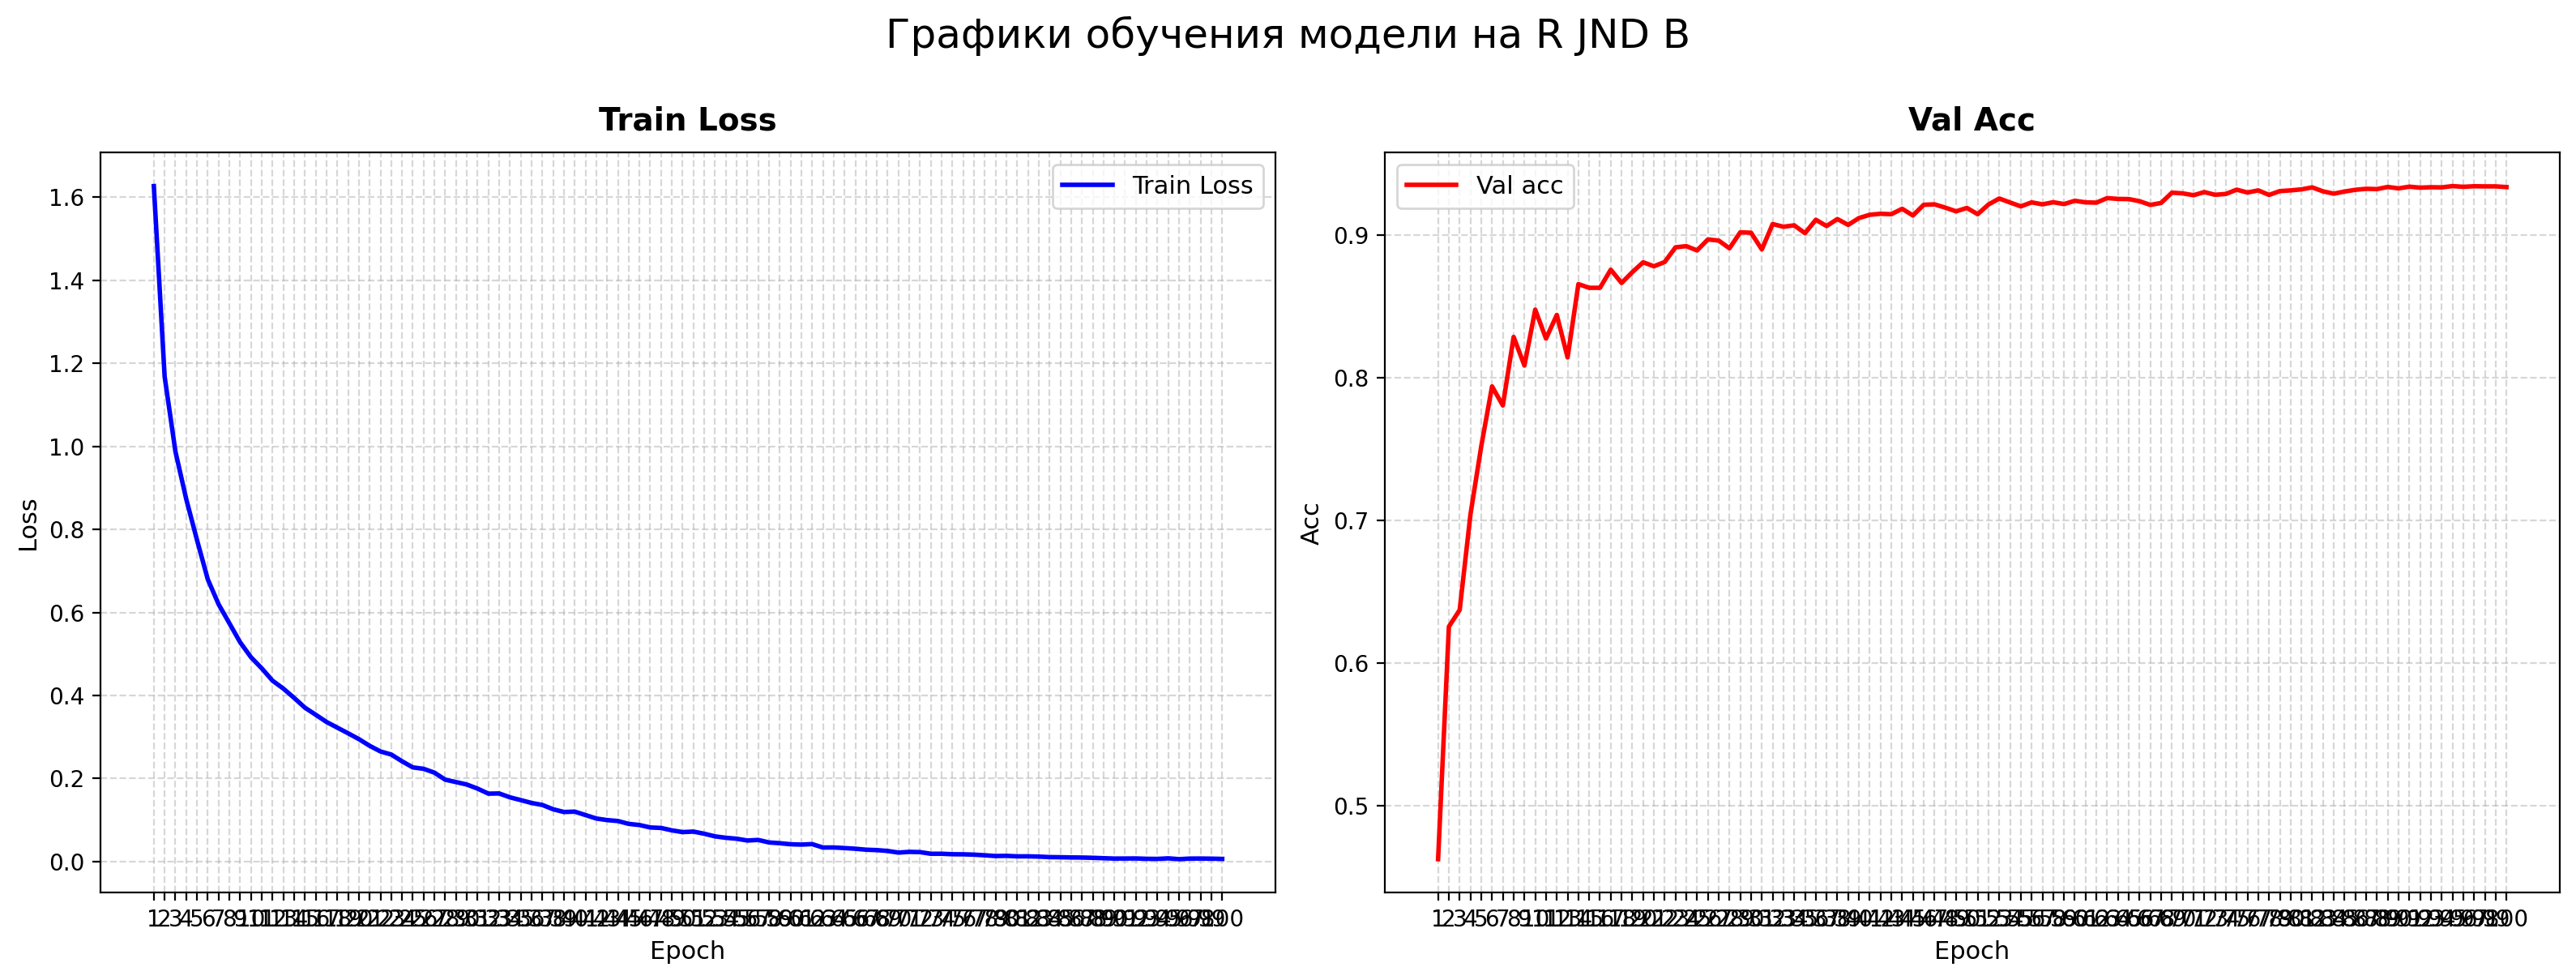

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

epochs_range = range(1, len(loses_history) + 1)

fig.suptitle('Графики обучения модели на R JND B', fontsize=18, y=1)

ax1.plot(epochs_range, loses_history, linewidth=2, color = 'blue', label='Train Loss')
ax1.set_title('Train Loss', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=11)

ax2.plot(epochs_range, metric_history, linewidth=2, color = 'red', label='Val acc')
ax2.set_title('Val Acc', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Acc', fontsize=11)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

plt.tight_layout()

plt.show()

In [36]:
model_jnd = ResNet18().to(device)
model_rgb = ResNet18().to(device)
model_3jnd = ResNet18().to(device)
model_XjndZ = ResNet18().to(device)
model_RjndB = ResNet18().to(device)

model_jnd.load_state_dict(torch.load('model_jnd_weight.pth'))
model_rgb.load_state_dict(torch.load('model_rgb_weight.pth'))
model_3jnd.load_state_dict(torch.load('model_3jnd_weight.pth'))
model_XjndZ.load_state_dict(torch.load('model_XjndZ_weight.pth'))
model_RjndB.load_state_dict(torch.load('model_RjndB_weight.pth'))

<All keys matched successfully>

In [87]:
random.seed(42)

indices = list(random.sample(range(10000), 1000))
#indices = list(random.sample(range(10000), 10))
subset_dataset = Subset(val_dataset_rgb, indices)

val_loader_1000_rgb = DataLoader(subset_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

#val_loader_10000_rgb = DataLoader(val_dataset_rgb, batch_size=16, shuffle=False)

In [75]:
def rgb_tensor_to_tensor(rgb_tensor, converter, jnd_model, L_MIN, L_MAX, layers=None):
    """
    Принимает тензор RGB [B, 3, H, W] в диапазоне [0, 1].
    Конвертирует его в нужный JND-формат в зависимости от значения layers:
    - 'x_y_jnd':     [x, y, k_map]
    - 'jnd_jnd_jnd': [k_map, k_map, k_map]
    - 'X_jnd_Z':     [X, k_map, Z]
    Возвращает тензор [B, 3, H, W]
    """

    rgb_np = rgb_tensor.permute(0, 2, 3, 1).cpu().numpy().astype(np.float64)
    
    jnd_batch = []
    for i in range(rgb_np.shape[0]):
        img = rgb_np[i].copy()

        r_channel = img[..., 0]
        b_channel = img[..., 2]

        norm_img = converter.normalize_image(img)
        linRGBimg = converter.Inverse_sRGB_Companding(norm_img)
        XYZ_image = converter.Linear_RGB_to_XYZ(linRGBimg)
        xLy_image = converter.XYZ_to_xyY(XYZ_image, L_MAX)
        
        x_coord = xLy_image[..., 0]
        y_coord = xLy_image[..., 1]
        L_norm = xLy_image[..., 2]
        
        L_physical = L_MIN + (L_MAX - L_MIN) * L_norm
        
        jnd_model.find_La(L_physical)
        jnd_model.build_level_boundaries()
        k_map = jnd_model.L_to_k(L_physical)
        
        if layers == 'x_y_jnd':
            output_matrix = np.stack([x_coord, y_coord, k_map], axis=-1)
            
        elif layers == 'jnd_jnd_jnd':
            output_matrix = np.stack([k_map, k_map, k_map], axis=-1)
            
        elif layers == 'X_jnd_Z':
            eps = 1e-10
            
            factor = L_physical / (y_coord + eps)
            
            X_absolute = x_coord * factor
            Z_absolute = (1.0 - x_coord - y_coord) * factor
            
            output_matrix = np.stack([X_absolute, k_map, Z_absolute], axis=-1)
            
        elif layers == 'R_jnd_B':
            output_matrix = np.stack([r_channel * 255.0, k_map, b_channel * 255.0], axis=-1)
            
        else:
            raise ValueError(f"Неизвестный режим слоев: {layers}")
            
        jnd_batch.append(output_matrix)
        
    jnd_batch_np = np.stack(jnd_batch, axis=0)
    
    jnd_tensor = torch.from_numpy(jnd_batch_np.astype(np.float32)).permute(0, 3, 1, 2).to(rgb_tensor.device)
    return jnd_tensor


In [88]:
def get_results_for_model(model, attack_model, loader, converter, jnd_model, L_MIN, L_MAX, layers="rgb"):
    data = []
    attacks = [torchattacks.FGSM, torchattacks.BIM, torchattacks.PGD, torchattacks.CW]
    names = ["FGSM", "BIM", "PGD", "CW"]
    params = [
        {"eps": 8/255},
        {"eps": 8/255, "alpha": 2/255, "steps": 10},
        {"eps": 8/255, "alpha": 1/255, "steps": 10, "random_start": True},
        {"c": 1, "kappa": 0, "steps": 50, "lr": 0.01}
    ]
    
    for i, attack_class in tqdm(enumerate(attacks), desc=f'Тестирование режима {layers}', total=4):
        res = evaluate_single_model_robustness(
            model=model,
            attack_model=attack_model,
            attack_class=attack_class,
            loader=loader,
            converter=converter,
            jnd_model=jnd_model,
            L_MIN=L_MIN,
            L_MAX=L_MAX,
            layers=layers,
            **params[i]
        )
        res["Attack"] = names[i]
        data.append(res)
        
    return pd.DataFrame(data).set_index("Attack")

In [89]:
def evaluate_single_model_robustness(model, attack_model, attack_class, loader, converter, jnd_model, L_MIN, L_MAX, layers="rgb", **kwargs):
    model.eval()
    attack_model.eval()
    
    total_clean_correct, total_adv_correct = 0, 0
    total_clean_conf, total_adv_conf = 0.0, 0.0
    total_images = 0
    
    attack = attack_class(attack_model, **kwargs)
    
    device = next(model.parameters()).device
    
    for images, labels in tqdm(loader, desc=f"Атака {attack_class.__name__}", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        adv_images_rgb = attack(images, labels)
        
        def prepare_inputs(input_rgb):
            if layers == "rgb":
                return input_rgb
            
            layer_mapping = {
                    "jnd_xyk": "x_y_jnd",
                    "jnd_kkk": "jnd_jnd_jnd",
                    "jnd_xkz": "X_jnd_Z",
                    "jnd_rkb": "R_jnd_B",
            }
            target_layer = layer_mapping.get(layers)

            return rgb_tensor_to_tensor(input_rgb, converter, jnd_model, L_MIN, L_MAX, layers=target_layer)

        clean_inputs = prepare_inputs(images)
        adv_inputs = prepare_inputs(adv_images_rgb)
        
        outputs_clean = model(clean_inputs)
        _, predicted_clean = torch.max(outputs_clean.data, 1)
        total_clean_correct += (predicted_clean == labels).sum().item()
        probs_clean = F.softmax(outputs_clean, dim=1)
        total_clean_conf += probs_clean.gather(1, labels.view(-1, 1)).squeeze().sum().item()
        
        outputs_adv = model(adv_inputs)
        _, predicted_adv = torch.max(outputs_adv.data, 1)
        total_adv_correct += (predicted_adv == labels).sum().item()
        probs_adv = F.softmax(outputs_adv, dim=1)
        total_adv_conf += probs_adv.gather(1, labels.view(-1, 1)).squeeze().sum().item()
        
        total_images += len(labels)
        
    return {
        "Clean Acc": 100 * total_clean_correct / total_images,
        "Adv Acc": 100 * total_adv_correct / total_images,
        "Drop": 100 * (total_clean_correct - total_adv_correct) / total_images,
        "Clean Conf": total_clean_conf / total_images,
        "Adv Conf": total_adv_conf / total_images,
    }

In [90]:
L_MIN = 0.1
L_MAX = 300.0
converter = ImageConverter()
jnd_model = JNDModel(L_MIN, L_MAX)

df_rgb = get_results_for_model(
    model_rgb, attack_model=model_rgb, loader=val_loader_1000_rgb, 
    converter=converter, jnd_model=jnd_model, L_MIN=L_MIN, L_MAX=L_MAX, layers="rgb"
)

df_jnd_xyk = get_results_for_model(
    model_jnd, attack_model=model_rgb, loader=val_loader_1000_rgb, 
    converter=converter, jnd_model=jnd_model, L_MIN=L_MIN, L_MAX=L_MAX, layers="jnd_xyk"
)

df_jnd_kkk = get_results_for_model(
    model_3jnd, attack_model=model_rgb, loader=val_loader_1000_rgb, 
    converter=converter, jnd_model=jnd_model, L_MIN=L_MIN, L_MAX=L_MAX, layers="jnd_kkk"
)

df_jnd_XkZ = get_results_for_model(
    model_XjndZ, attack_model=model_rgb, loader=val_loader_1000_rgb, 
    converter=converter, jnd_model=jnd_model, L_MIN=L_MIN, L_MAX=L_MAX, layers="jnd_xkz"
)

df_jnd_RkB = get_results_for_model(
    model_RjndB, attack_model=model_rgb, loader=val_loader_1000_rgb, 
    converter=converter, jnd_model=jnd_model, L_MIN=L_MIN, L_MAX=L_MAX, layers="jnd_rkb"
)

Тестирование режима rgb:   0%|          | 0/4 [00:00<?, ?it/s]

Атака FGSM:   0%|          | 0/8 [00:00<?, ?it/s]

Атака BIM:   0%|          | 0/8 [00:00<?, ?it/s]

Атака PGD:   0%|          | 0/8 [00:00<?, ?it/s]

Атака CW:   0%|          | 0/8 [00:00<?, ?it/s]

...

Тестирование режима jnd_rkb:   0%|          | 0/4 [00:00<?, ?it/s]

Атака FGSM:   0%|          | 0/8 [00:00<?, ?it/s]

Атака BIM:   0%|          | 0/8 [00:00<?, ?it/s]

Атака PGD:   0%|          | 0/8 [00:00<?, ?it/s]

Атака CW:   0%|          | 0/8 [00:00<?, ?it/s]

In [91]:
print('Таблица модели RGB')
display(df_rgb)

print('Таблица модели xyk')
display(df_jnd_xyk)

print('Таблица модели kkk')
display(df_jnd_kkk)

print('Таблица модели XkZ')
display(df_jnd_XkZ)

print('Таблица модели RkB')
display(df_jnd_RkB)

Таблица модели RGB


,Clean Acc,Adv Acc,Drop,Clean Conf,Adv Conf
Attack,,,,,
FGSM,93.9,8.2,85.7,0.933561,8.608249e-02
BIM,93.9,0.0,93.9,0.933561,2.254581e-12
PGD,93.9,0.0,93.9,0.933561,3.764000e-04
CW,93.9,0.0,93.9,0.933561,5.335724e-02


Таблица модели xyk


,Clean Acc,Adv Acc,Drop,Clean Conf,Adv Conf
Attack,,,,,
FGSM,89.8,50.9,38.9,0.892535,0.502335
BIM,89.8,29.0,60.8,0.892535,0.288573
PGD,89.8,36.3,53.5,0.892535,0.362542
CW,89.8,83.2,6.6,0.892535,0.824659


Таблица модели kkk


,Clean Acc,Adv Acc,Drop,Clean Conf,Adv Conf
Attack,,,,,
FGSM,72.4,64.4,8.0,0.713119,0.630178
BIM,72.4,62.6,9.8,0.713119,0.614170
PGD,72.4,64.7,7.7,0.713119,0.641172
CW,72.4,70.5,1.9,0.713119,0.690998


Таблица модели XkZ


,Clean Acc,Adv Acc,Drop,Clean Conf,Adv Conf
Attack,,,,,
FGSM,89.1,40.8,48.3,0.887859,0.401285
BIM,89.1,16.8,72.3,0.887859,0.169754
PGD,89.1,25.4,63.7,0.887859,0.251679
CW,89.1,78.1,11.0,0.887859,0.765977


Таблица модели RkB


,Clean Acc,Adv Acc,Drop,Clean Conf,Adv Conf
Attack,,,,,
FGSM,88.2,37.9,50.3,0.875323,0.381038
BIM,88.2,13.6,74.6,0.875323,0.137037
PGD,88.2,21.0,67.2,0.875323,0.211509
CW,88.2,73.2,15.0,0.875323,0.723473


Атака: FGSM


Модели под FGSM:   0%|          | 0/5 [00:00<?, ?it/s]

Тестирование eps для rgb:   0%|          | 0/10 [00:00<?, ?it/s]

Чистый accuracy:   0%|          | 0/8 [00:00<?, ?it/s]

Атака eps = 0.0039:   0%|          | 0/8 [00:00<?, ?it/s]

...

Атака eps = 0.0196:   0%|          | 0/8 [00:00<?, ?it/s]

Атака eps = 0.0314:   0%|          | 0/8 [00:00<?, ?it/s]

Атака eps = 0.0392:   0%|          | 0/8 [00:00<?, ?it/s]

Атака eps = 0.0627:   0%|          | 0/8 [00:00<?, ?it/s]

Атака eps = 0.0784:   0%|          | 0/8 [00:00<?, ?it/s]

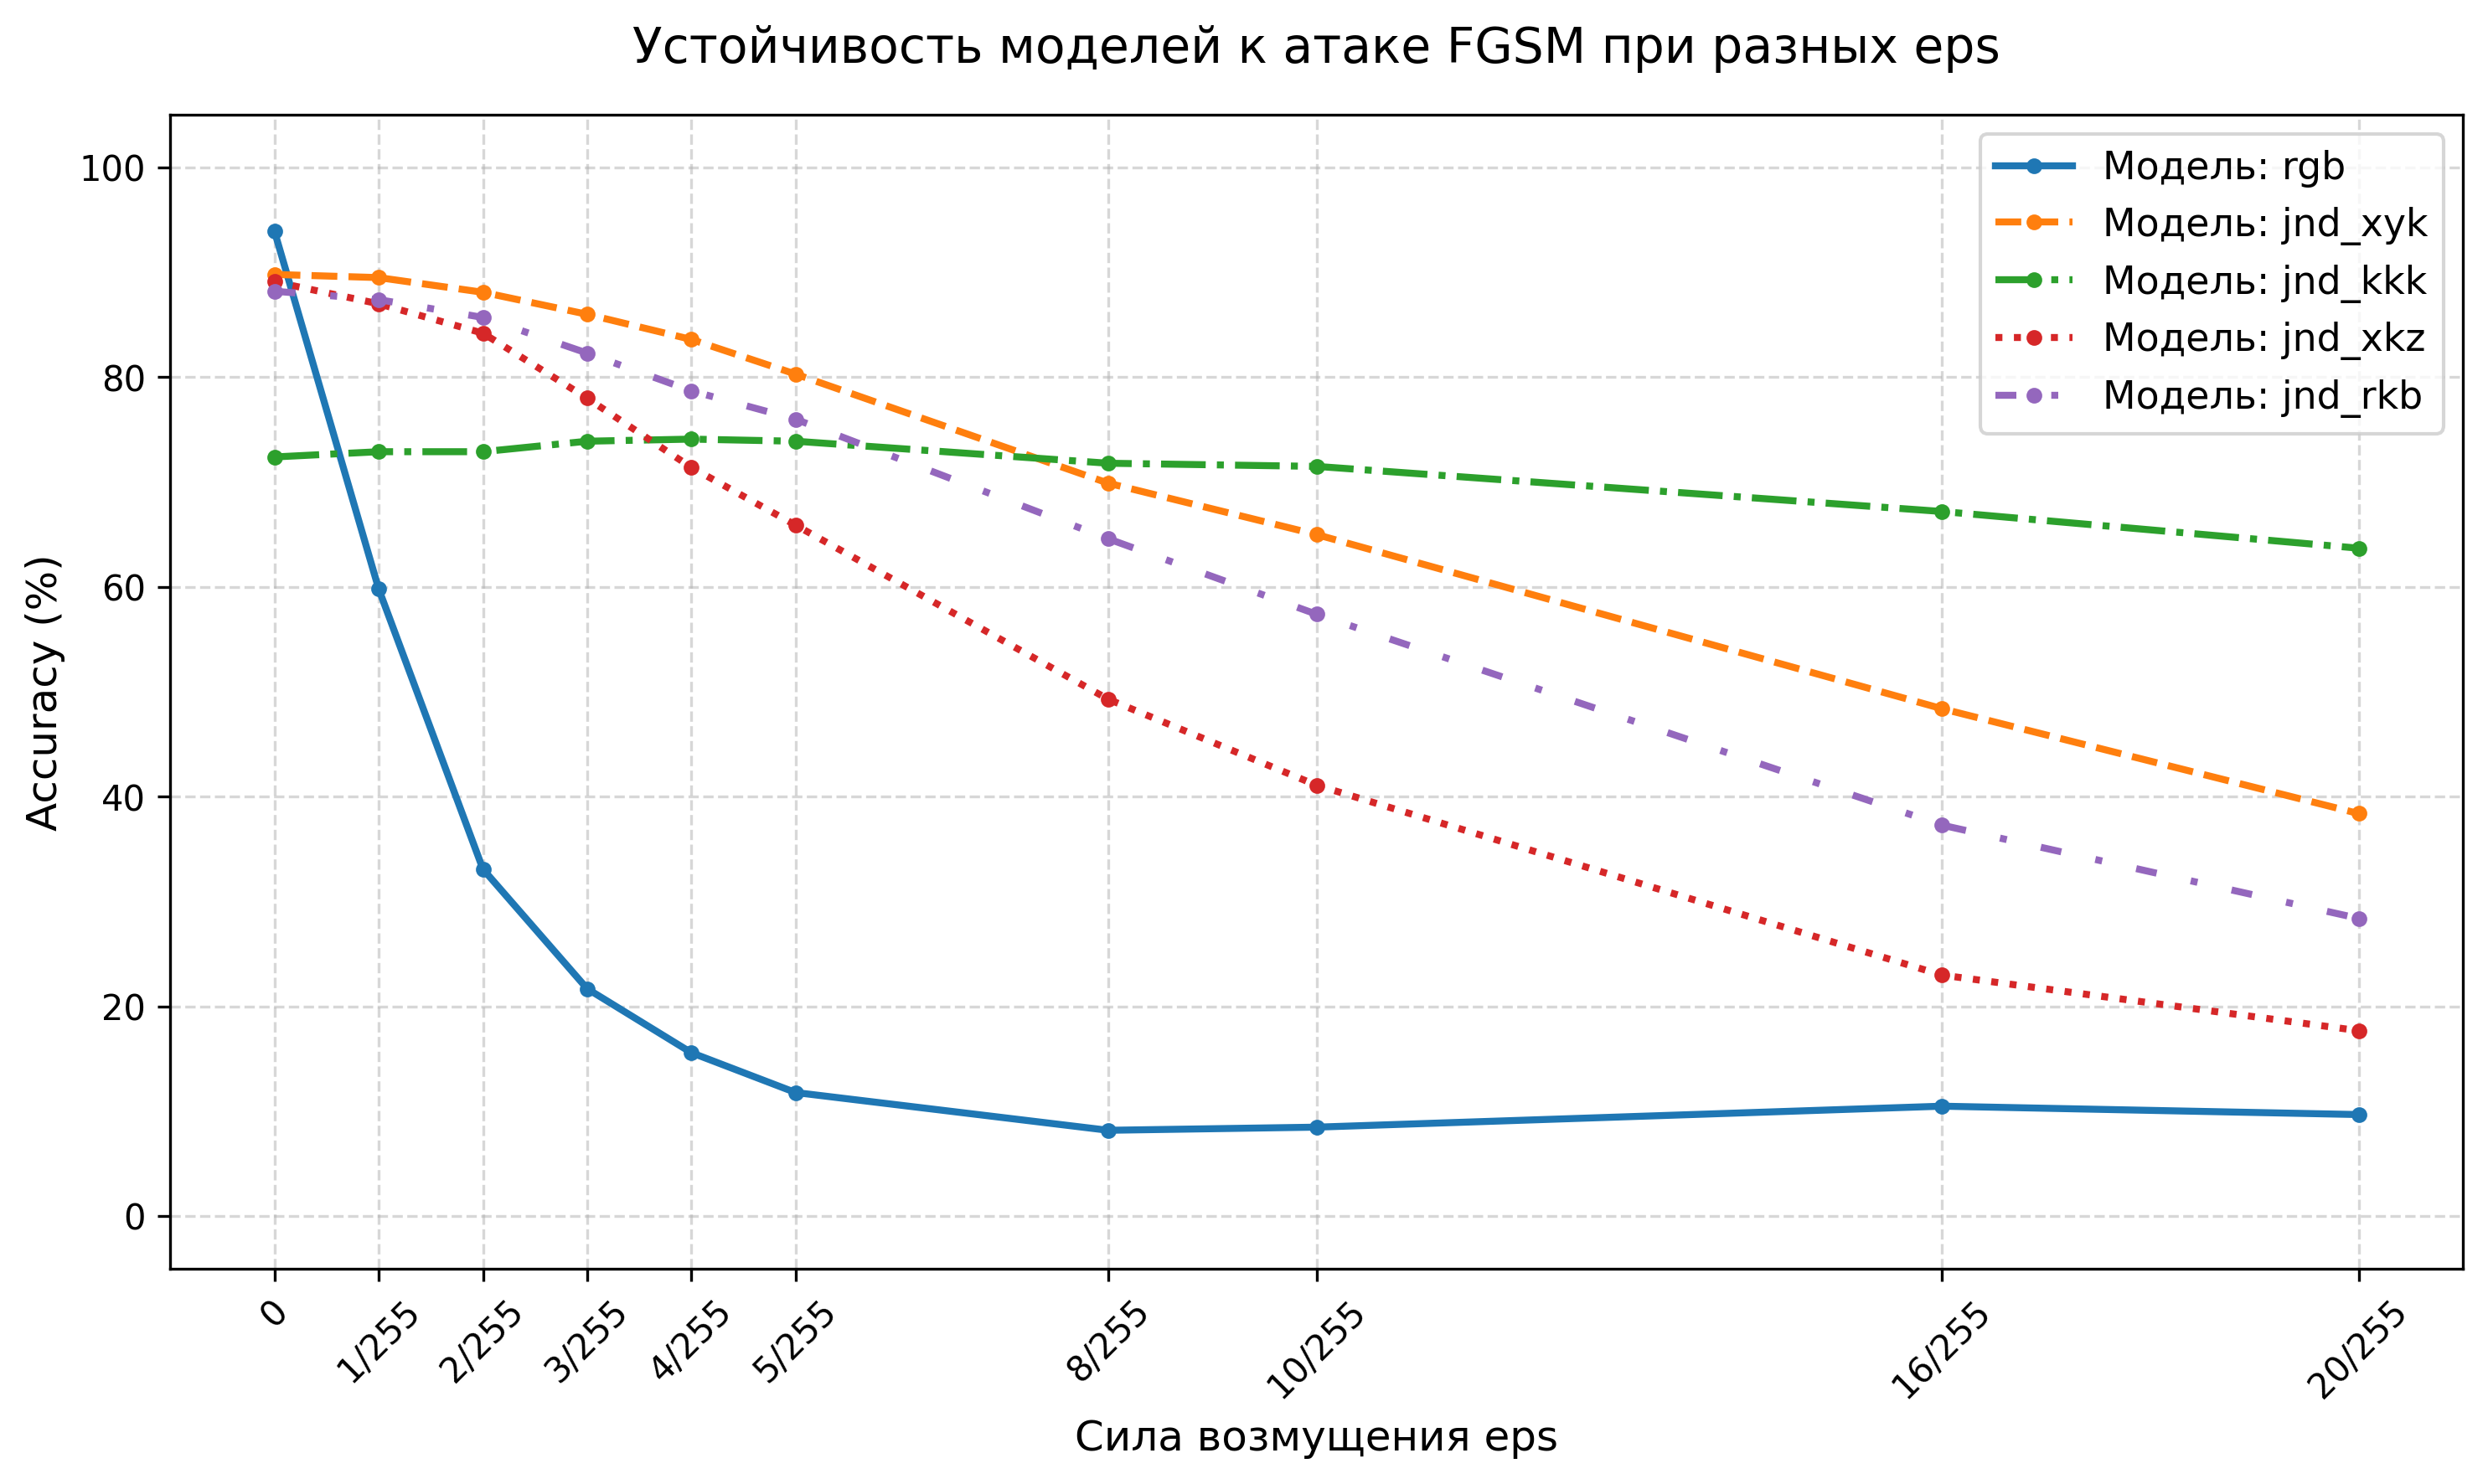

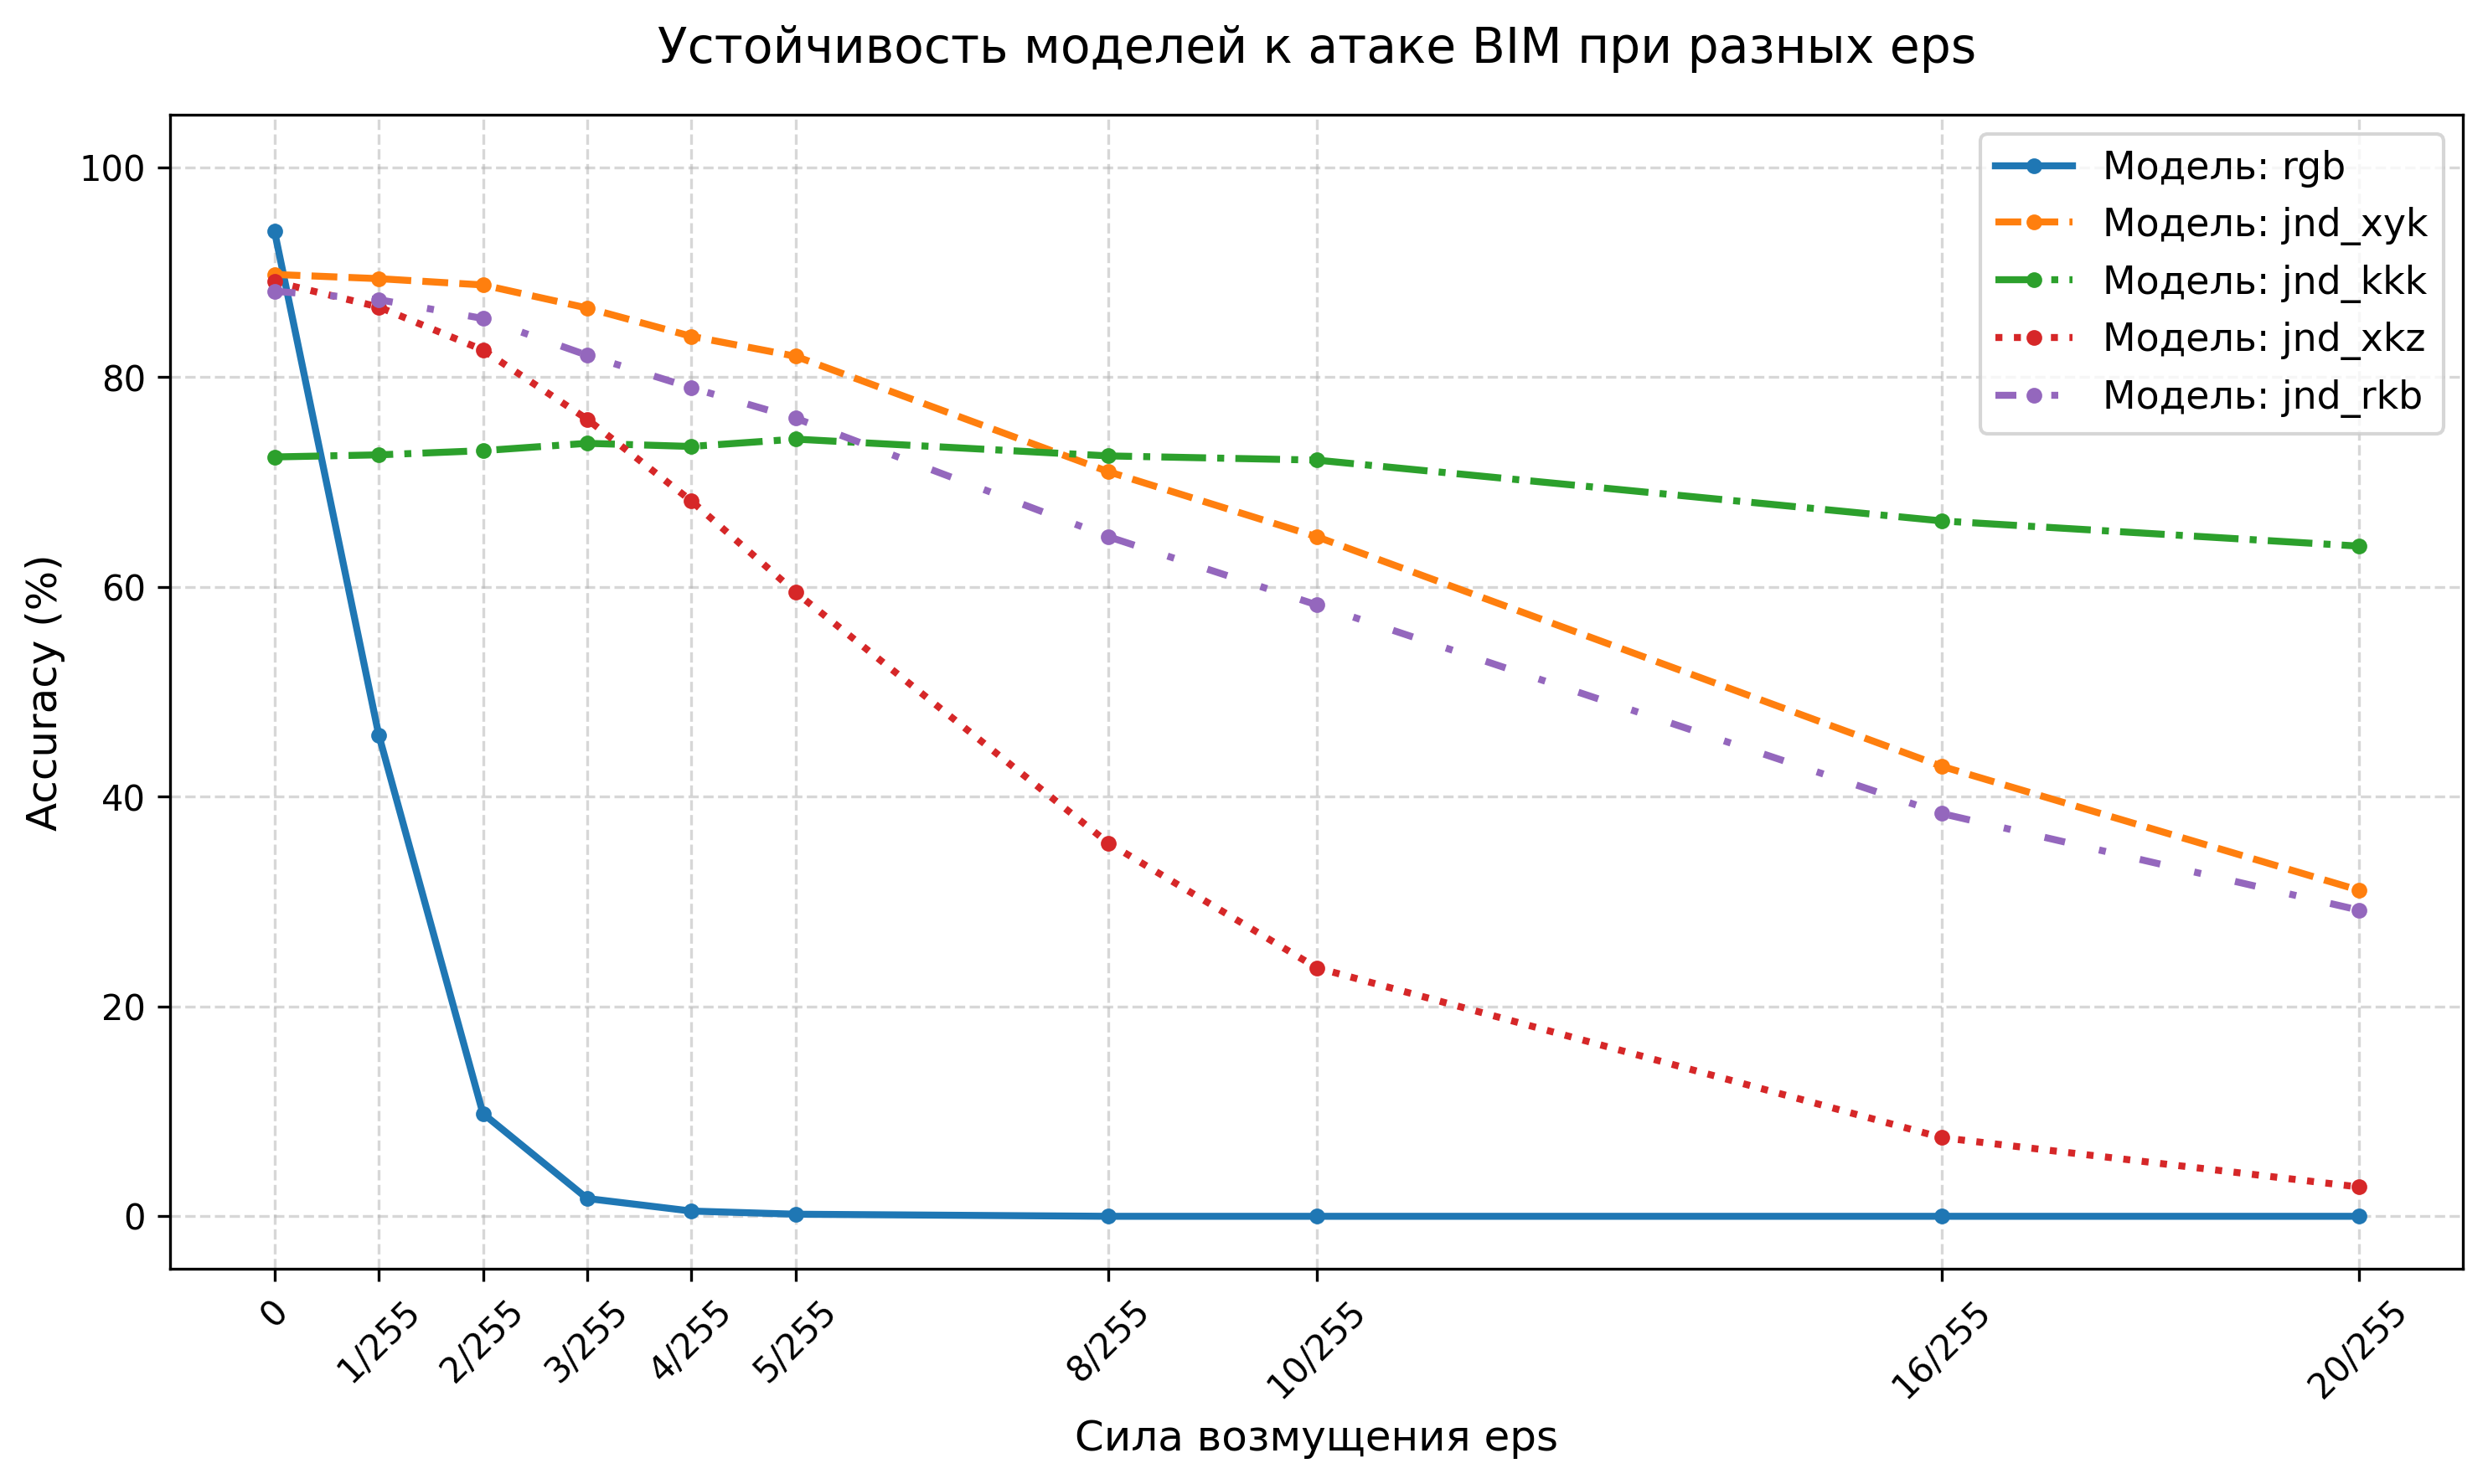

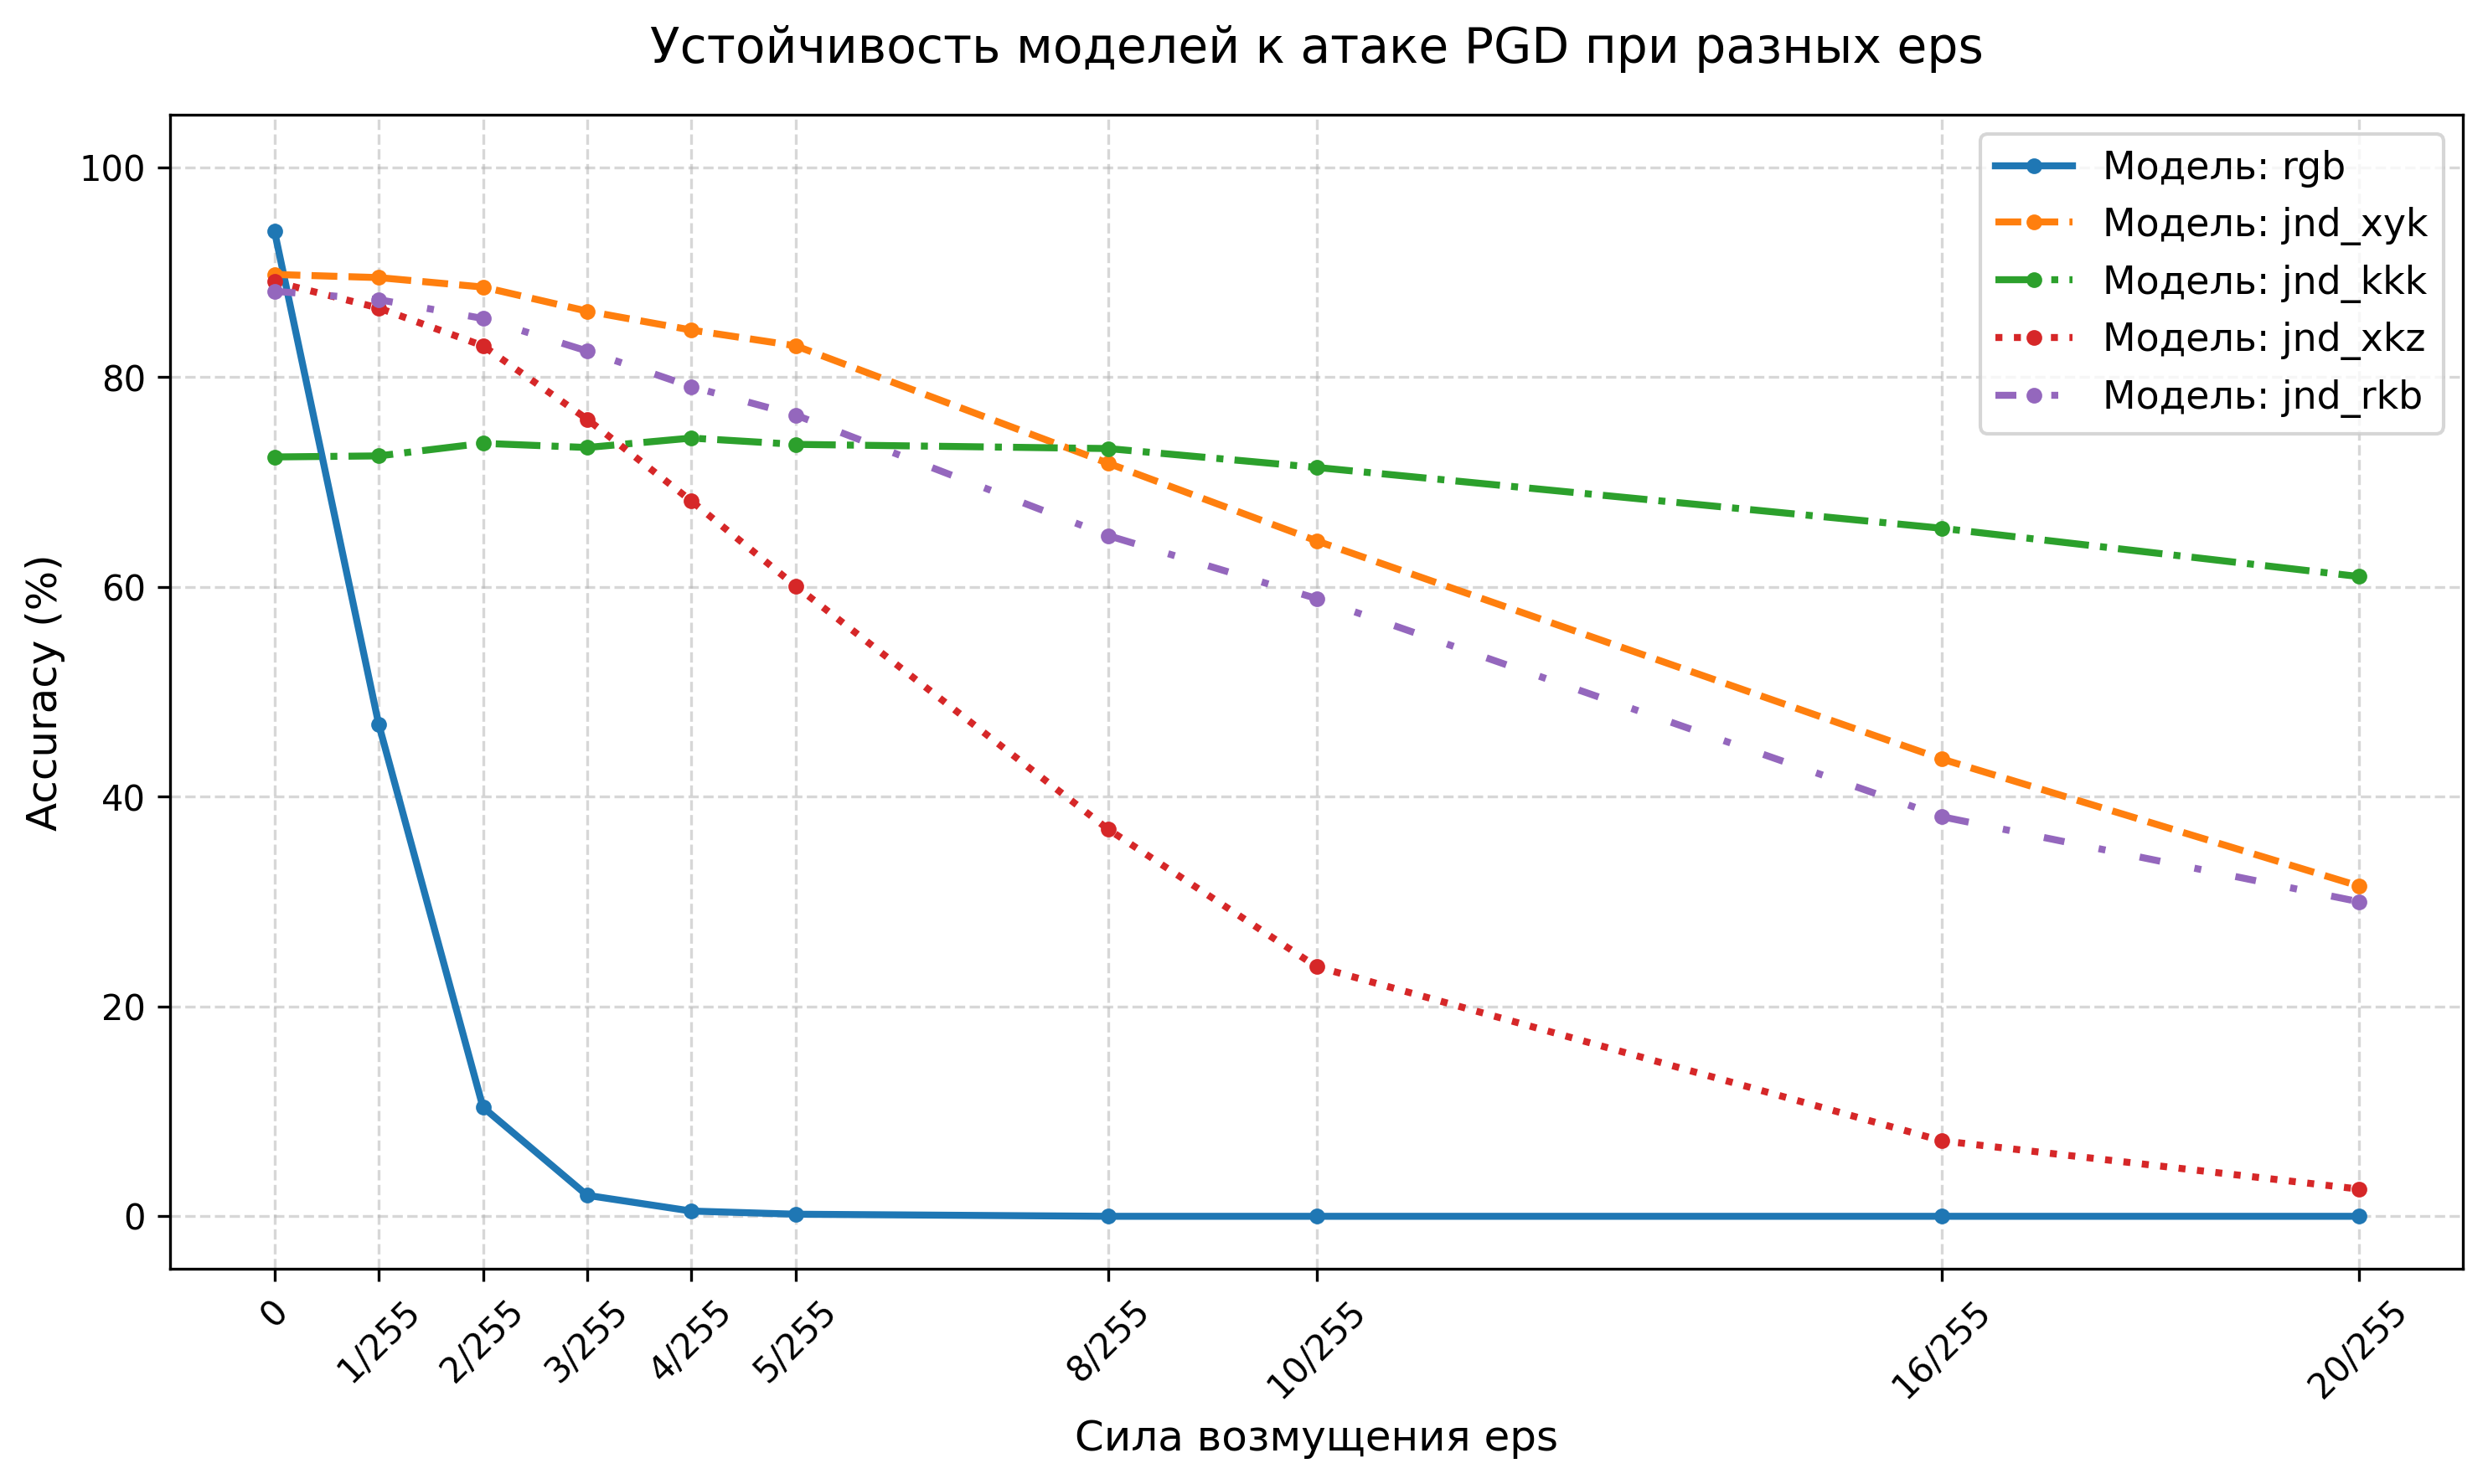

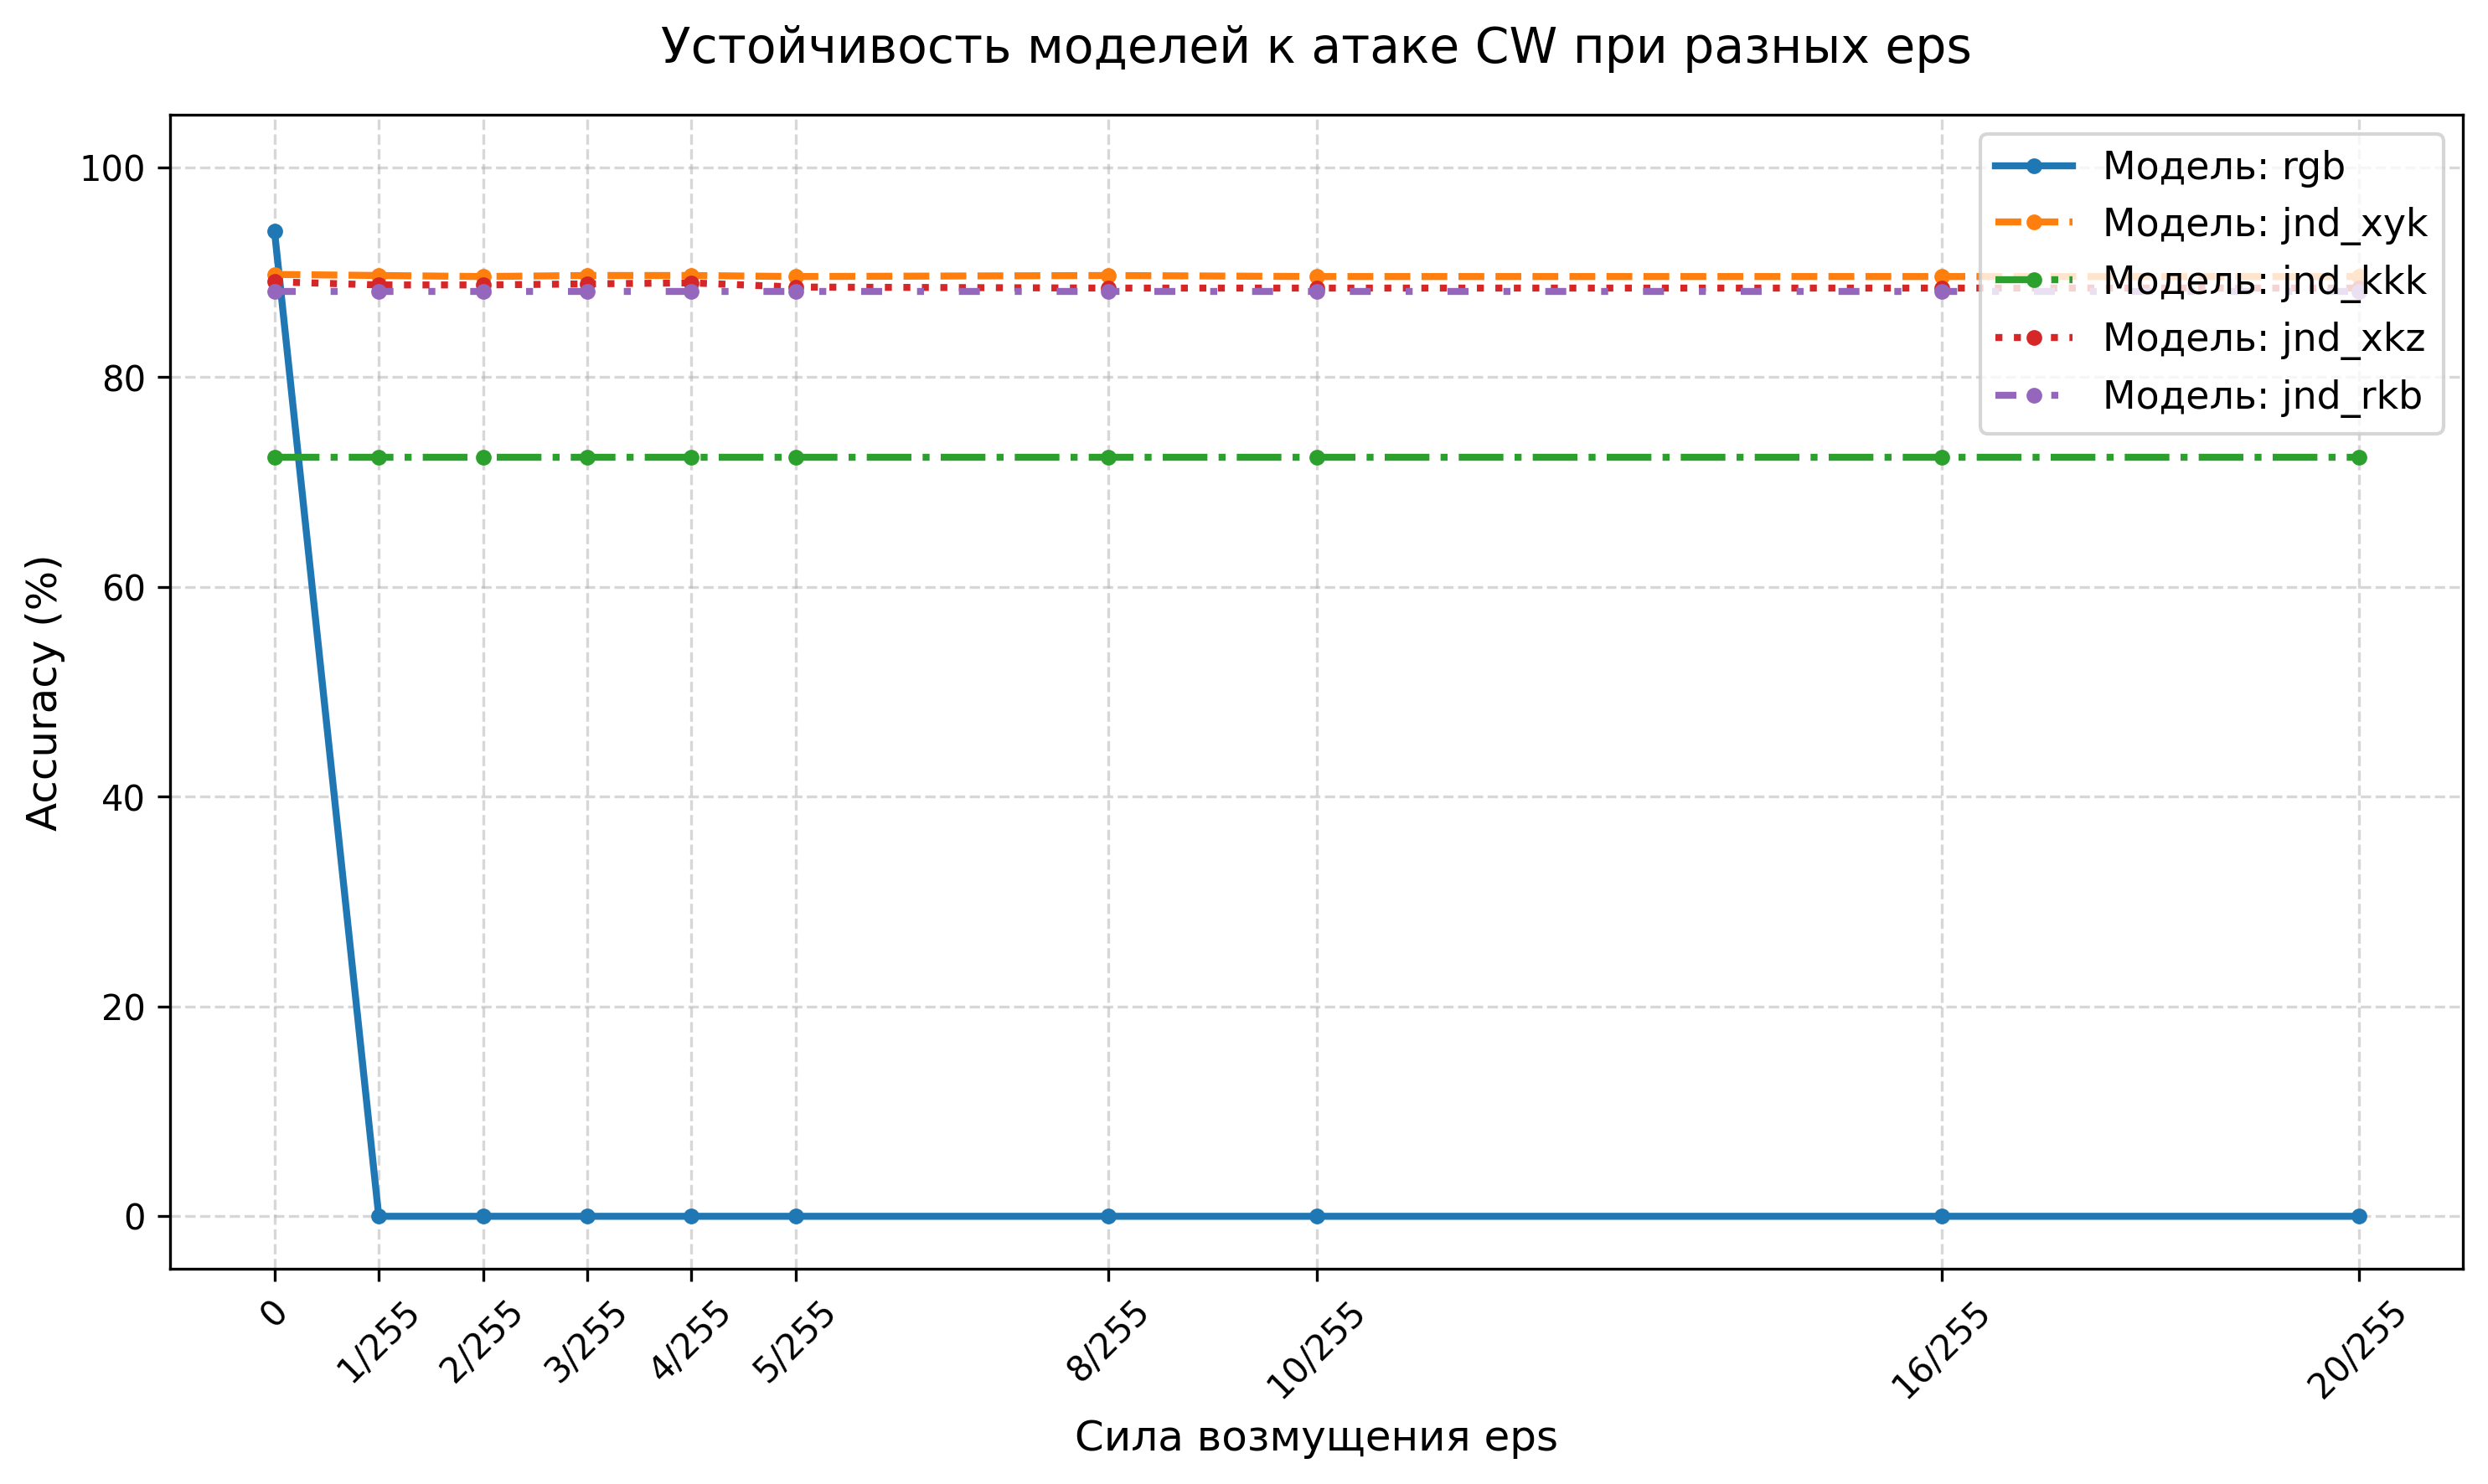

Визуализация атак при разных eps


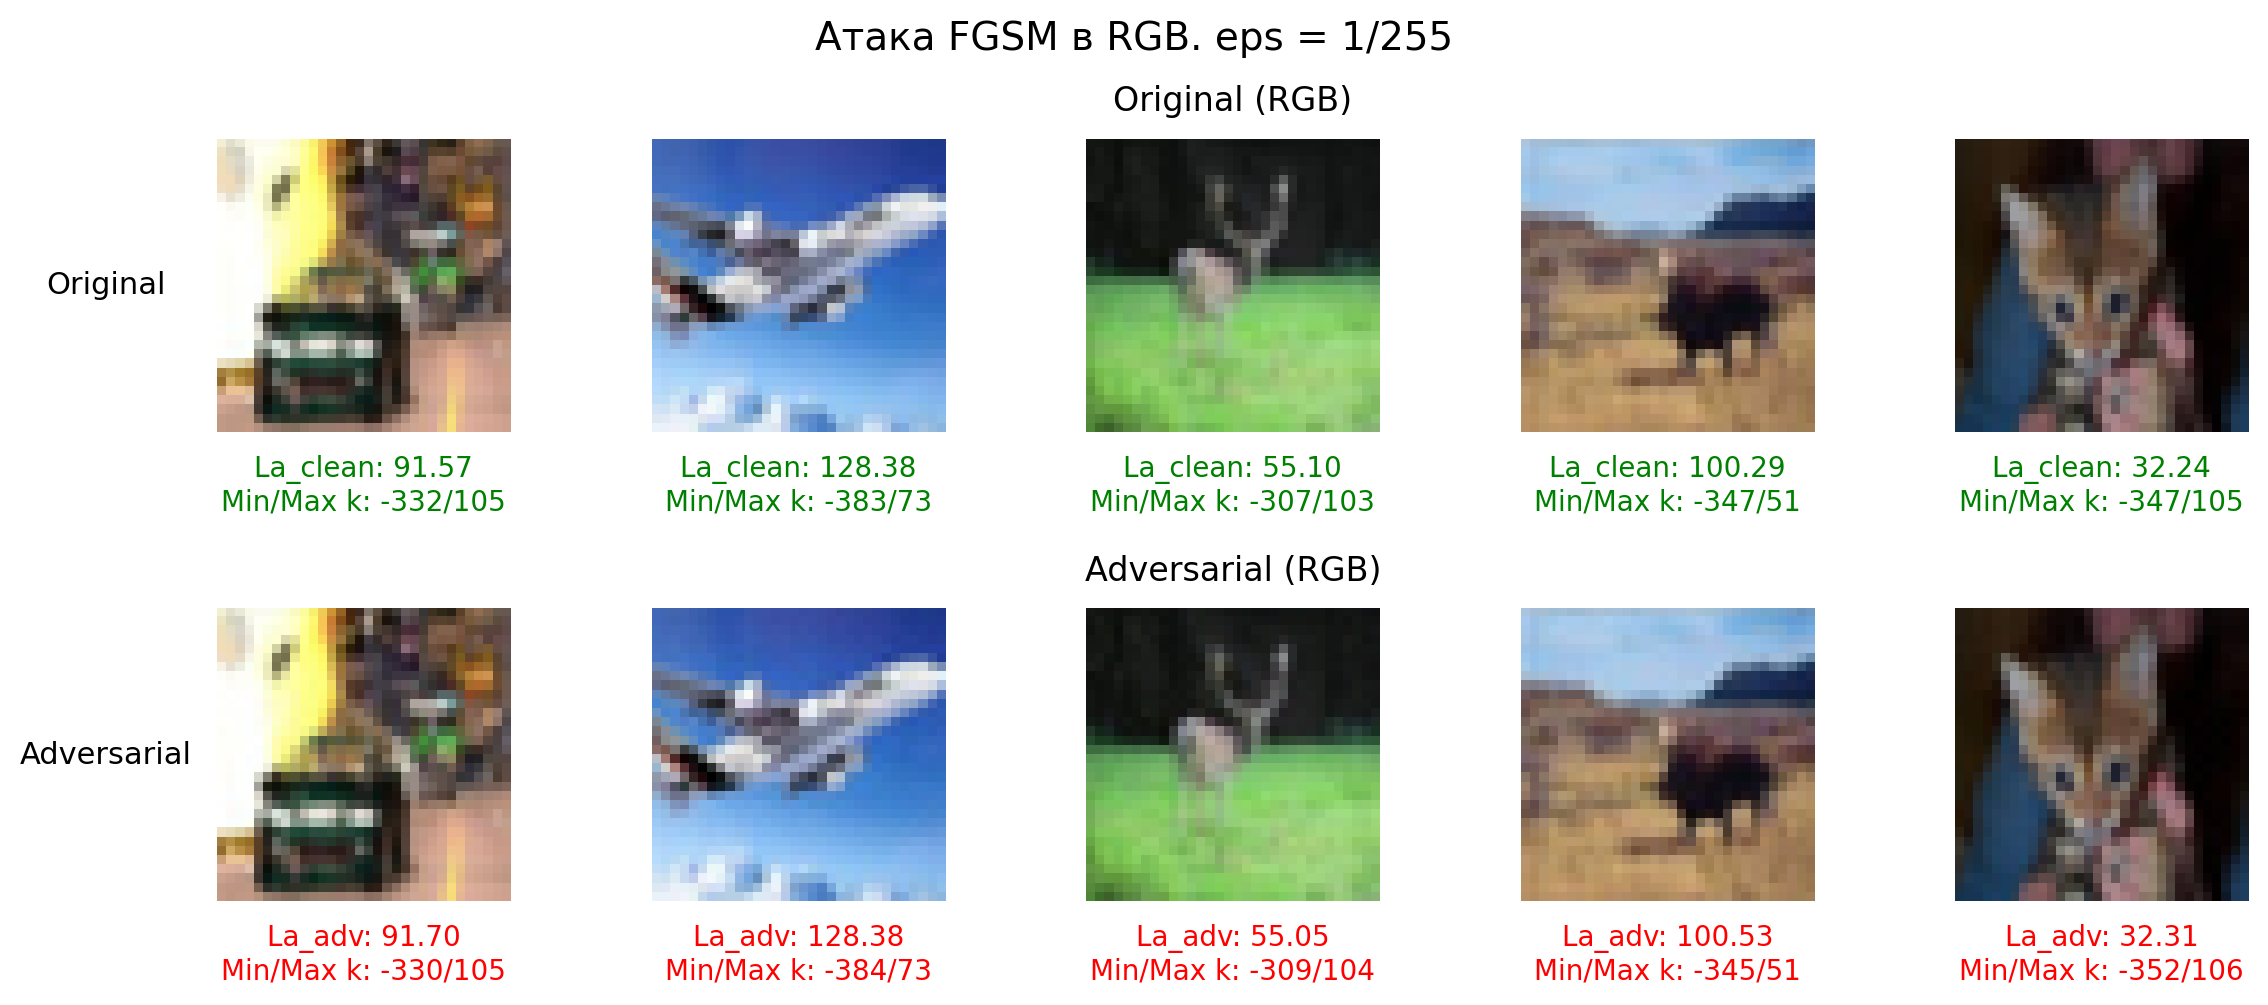

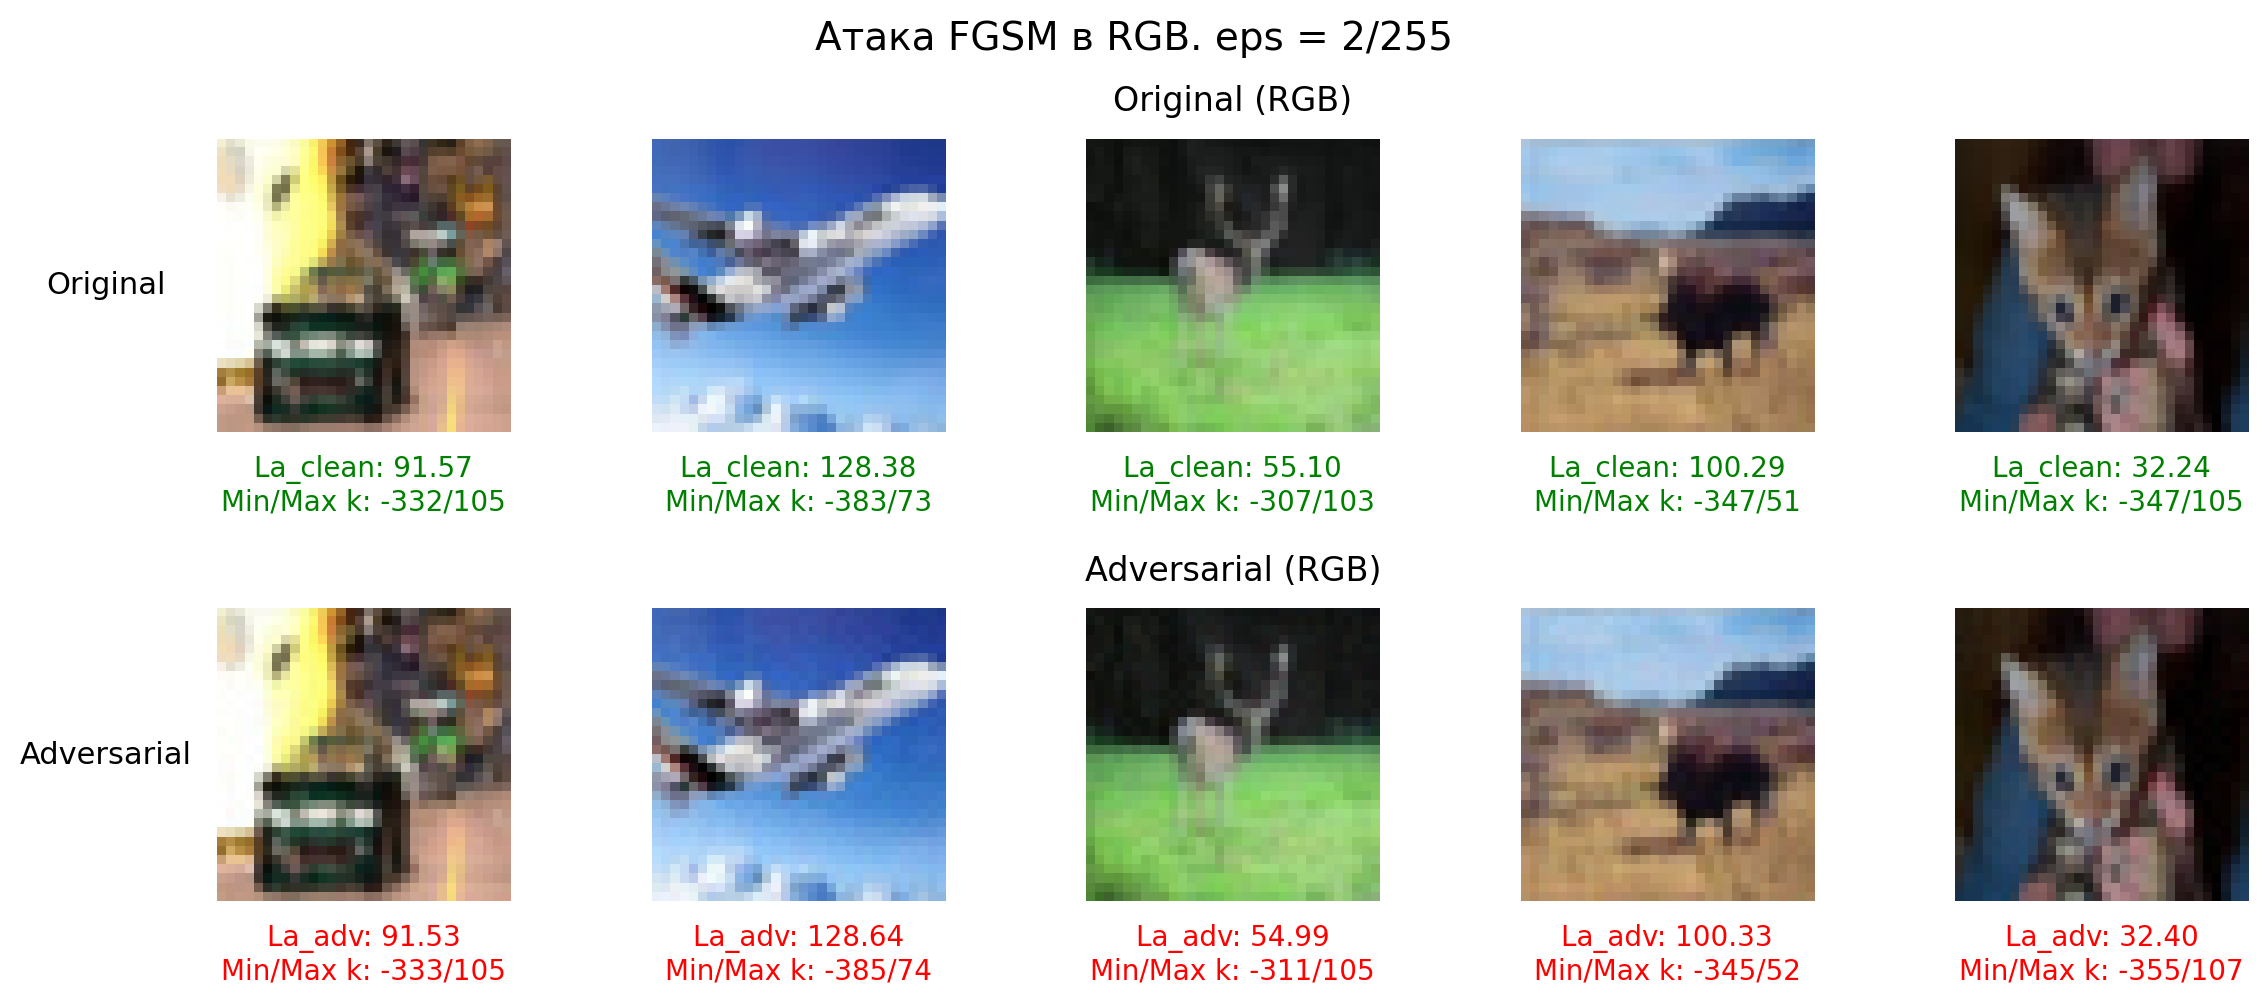

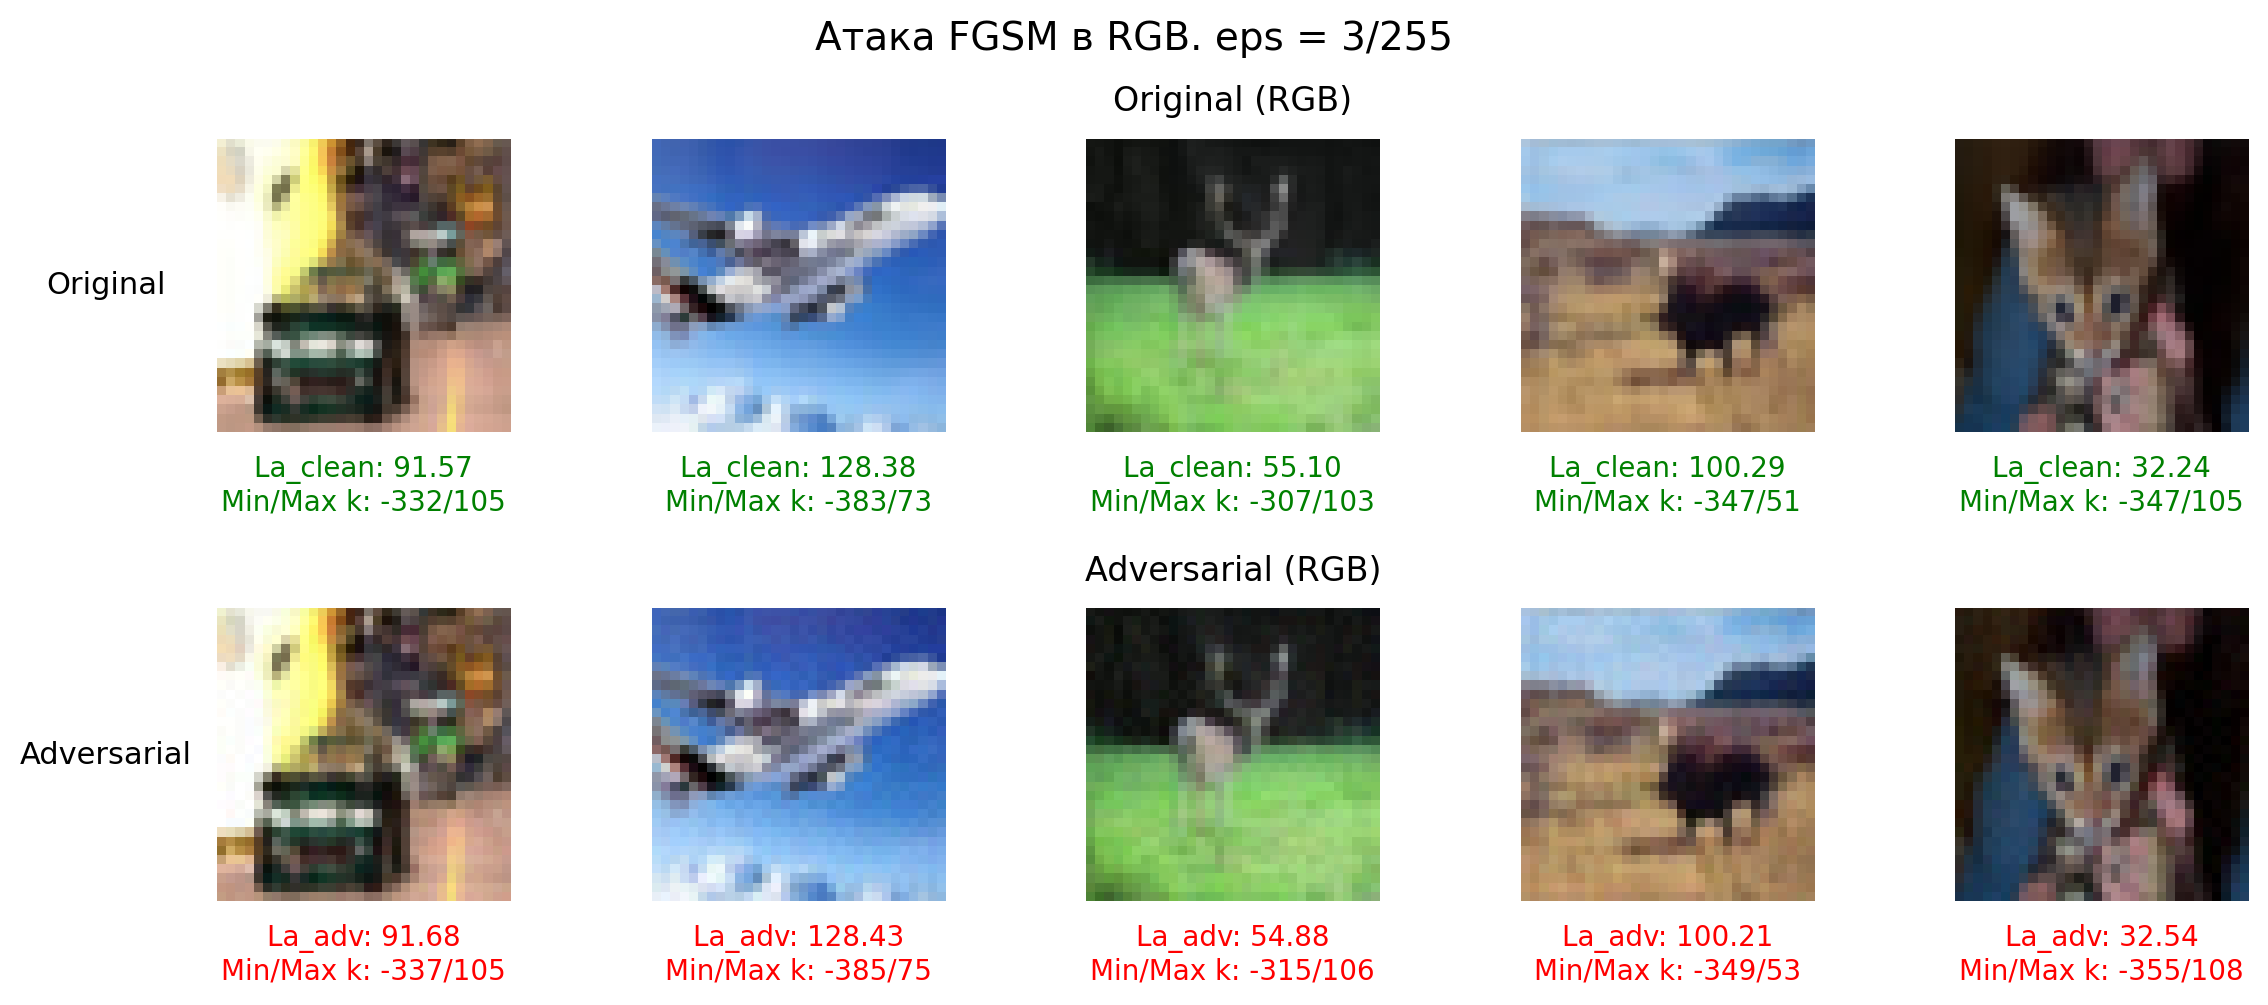

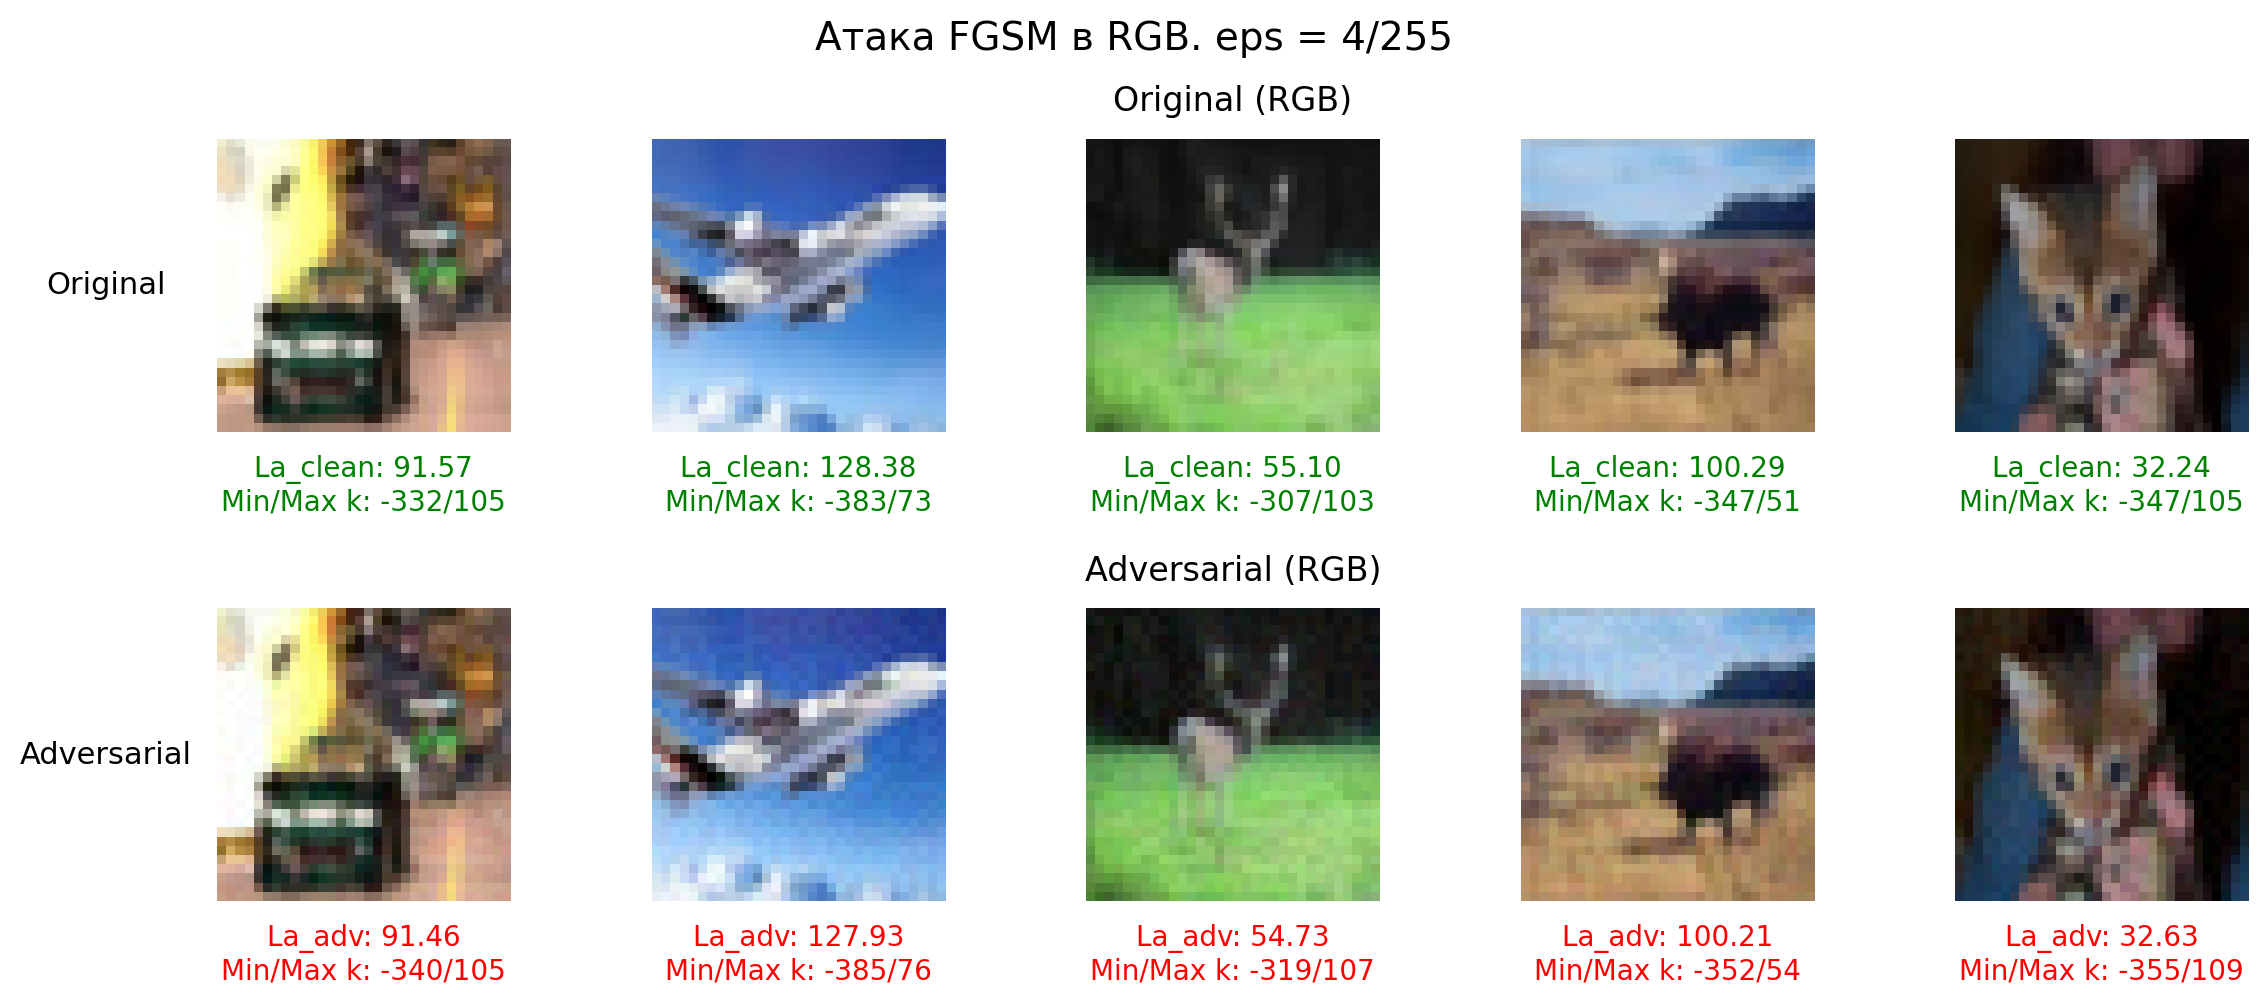

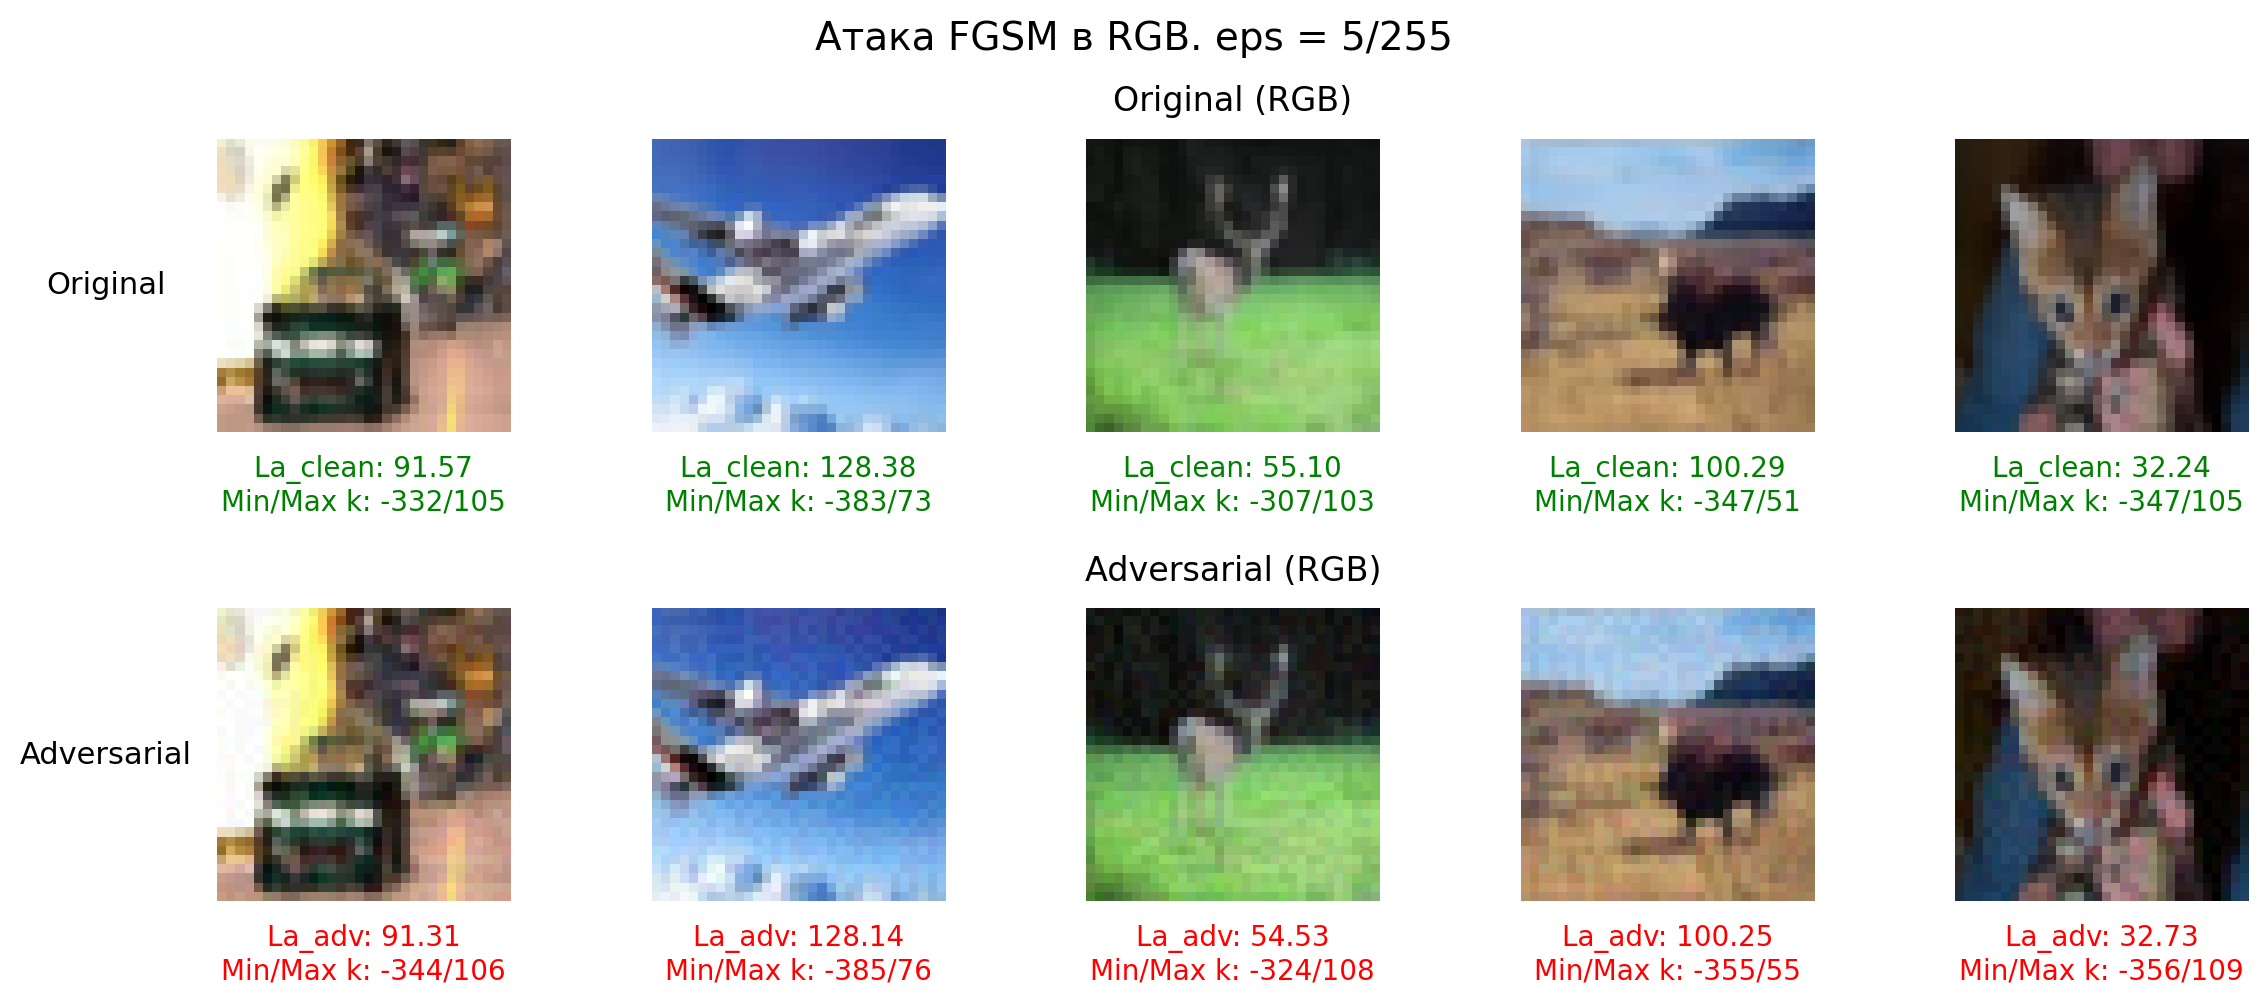

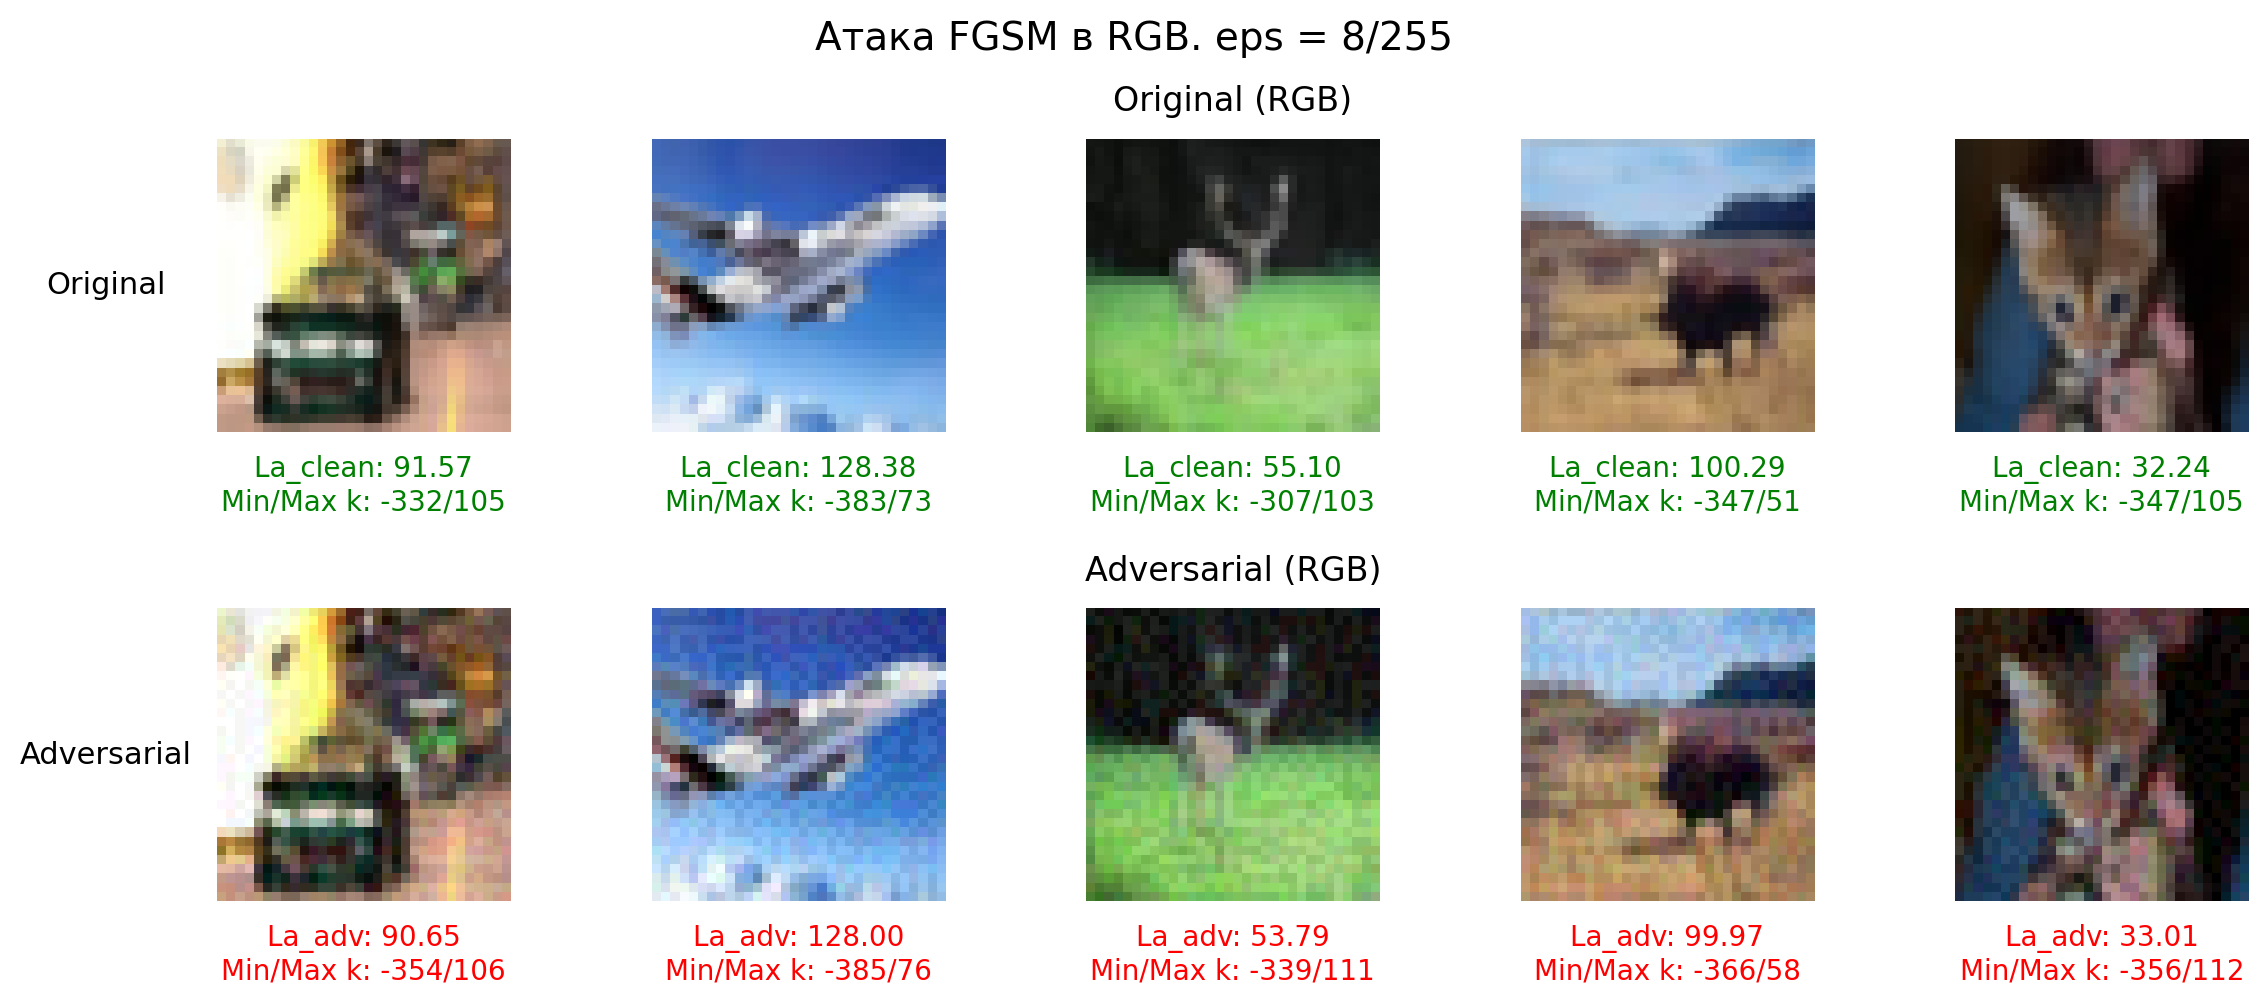

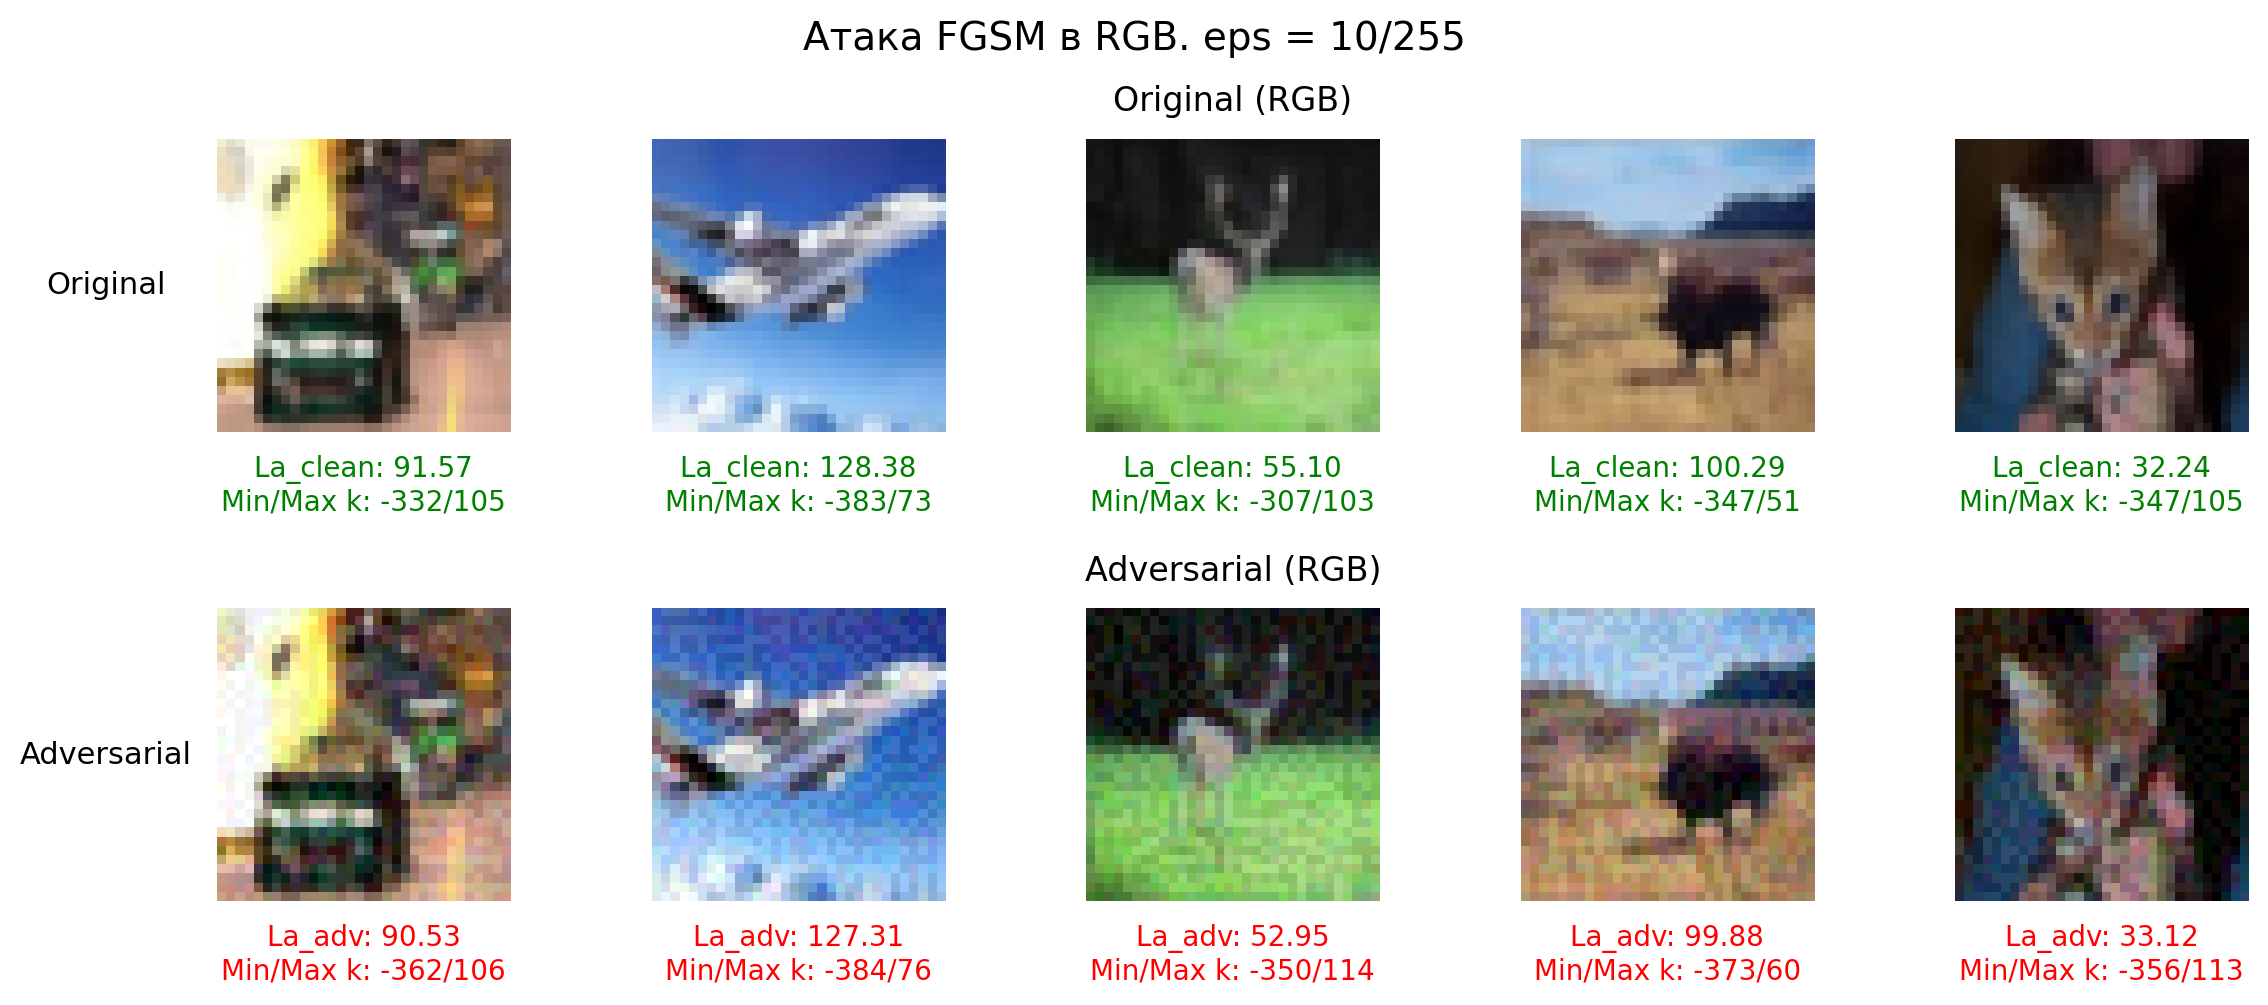

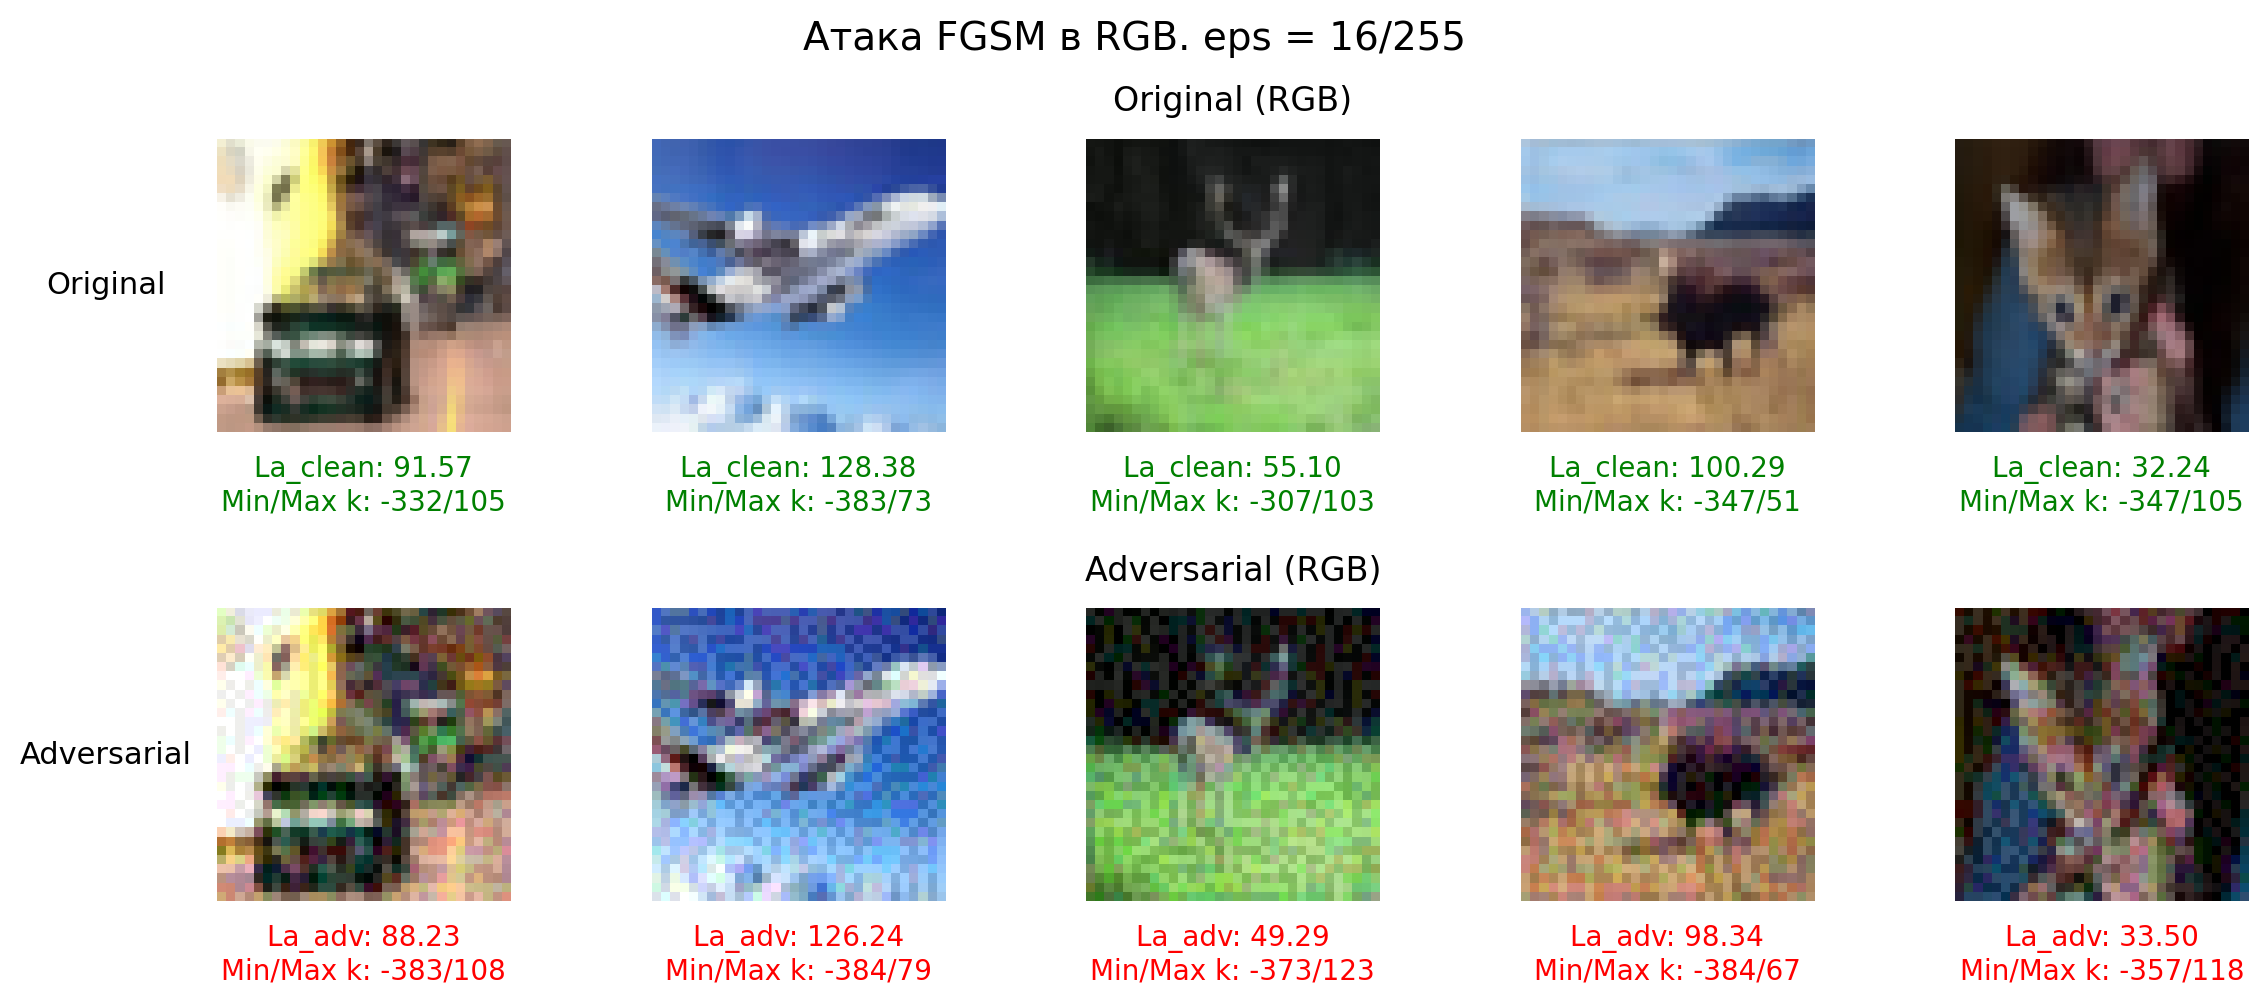

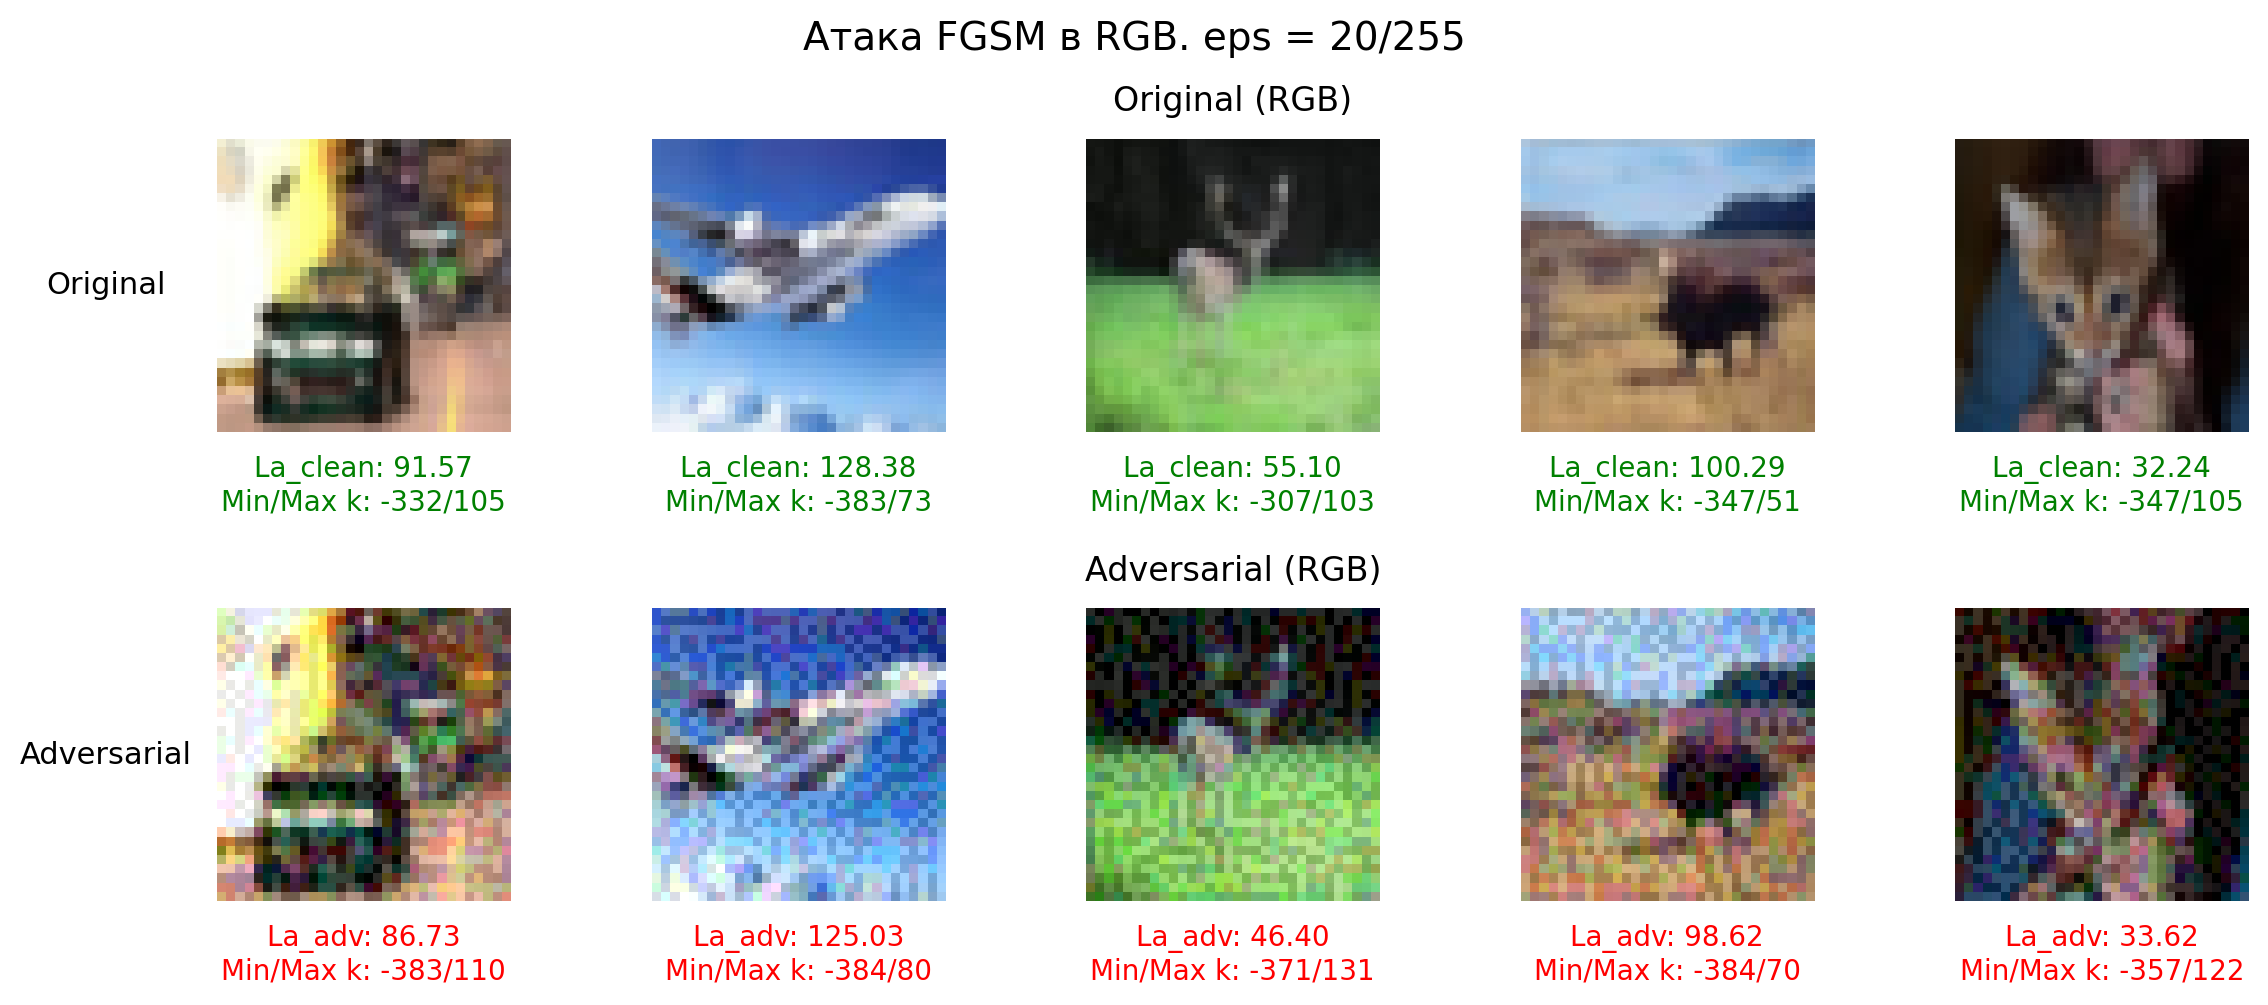

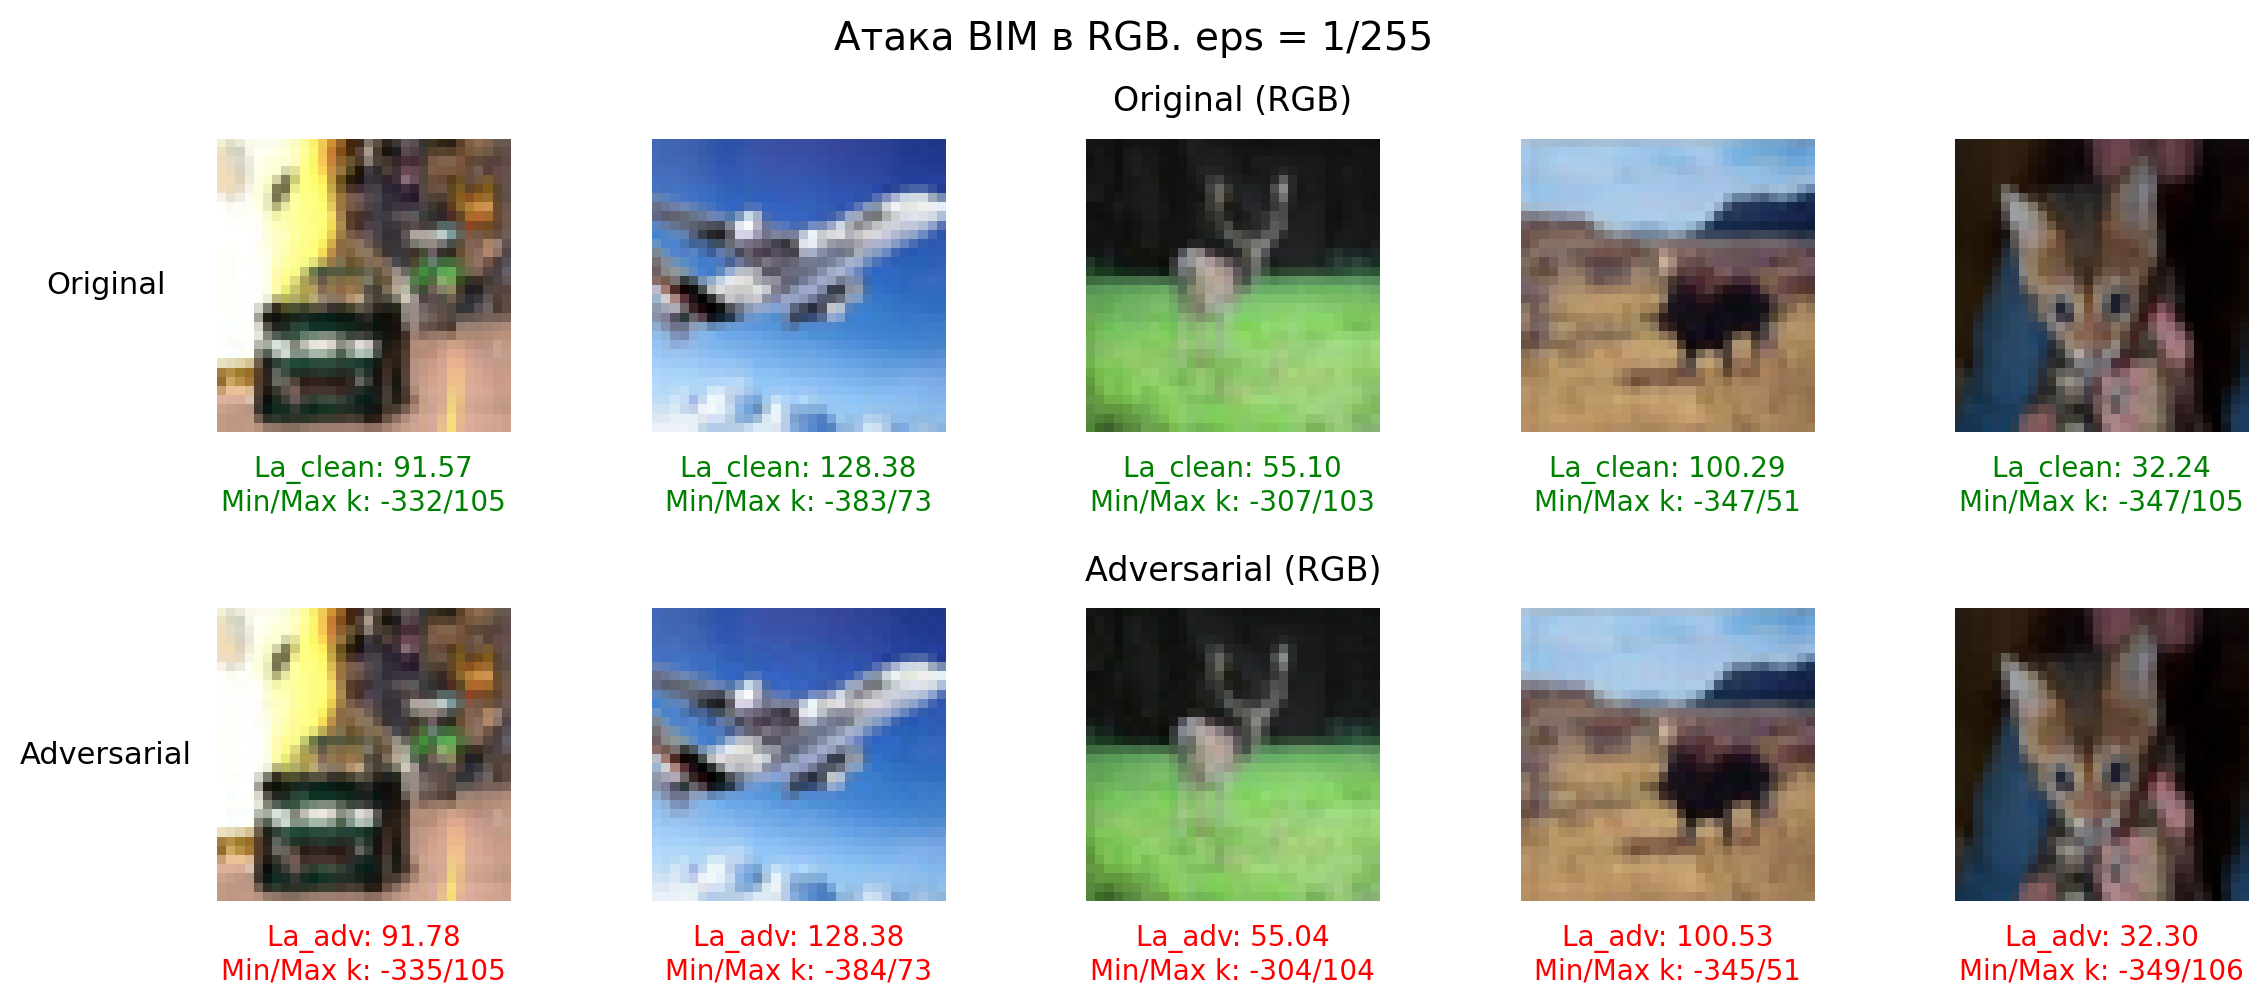

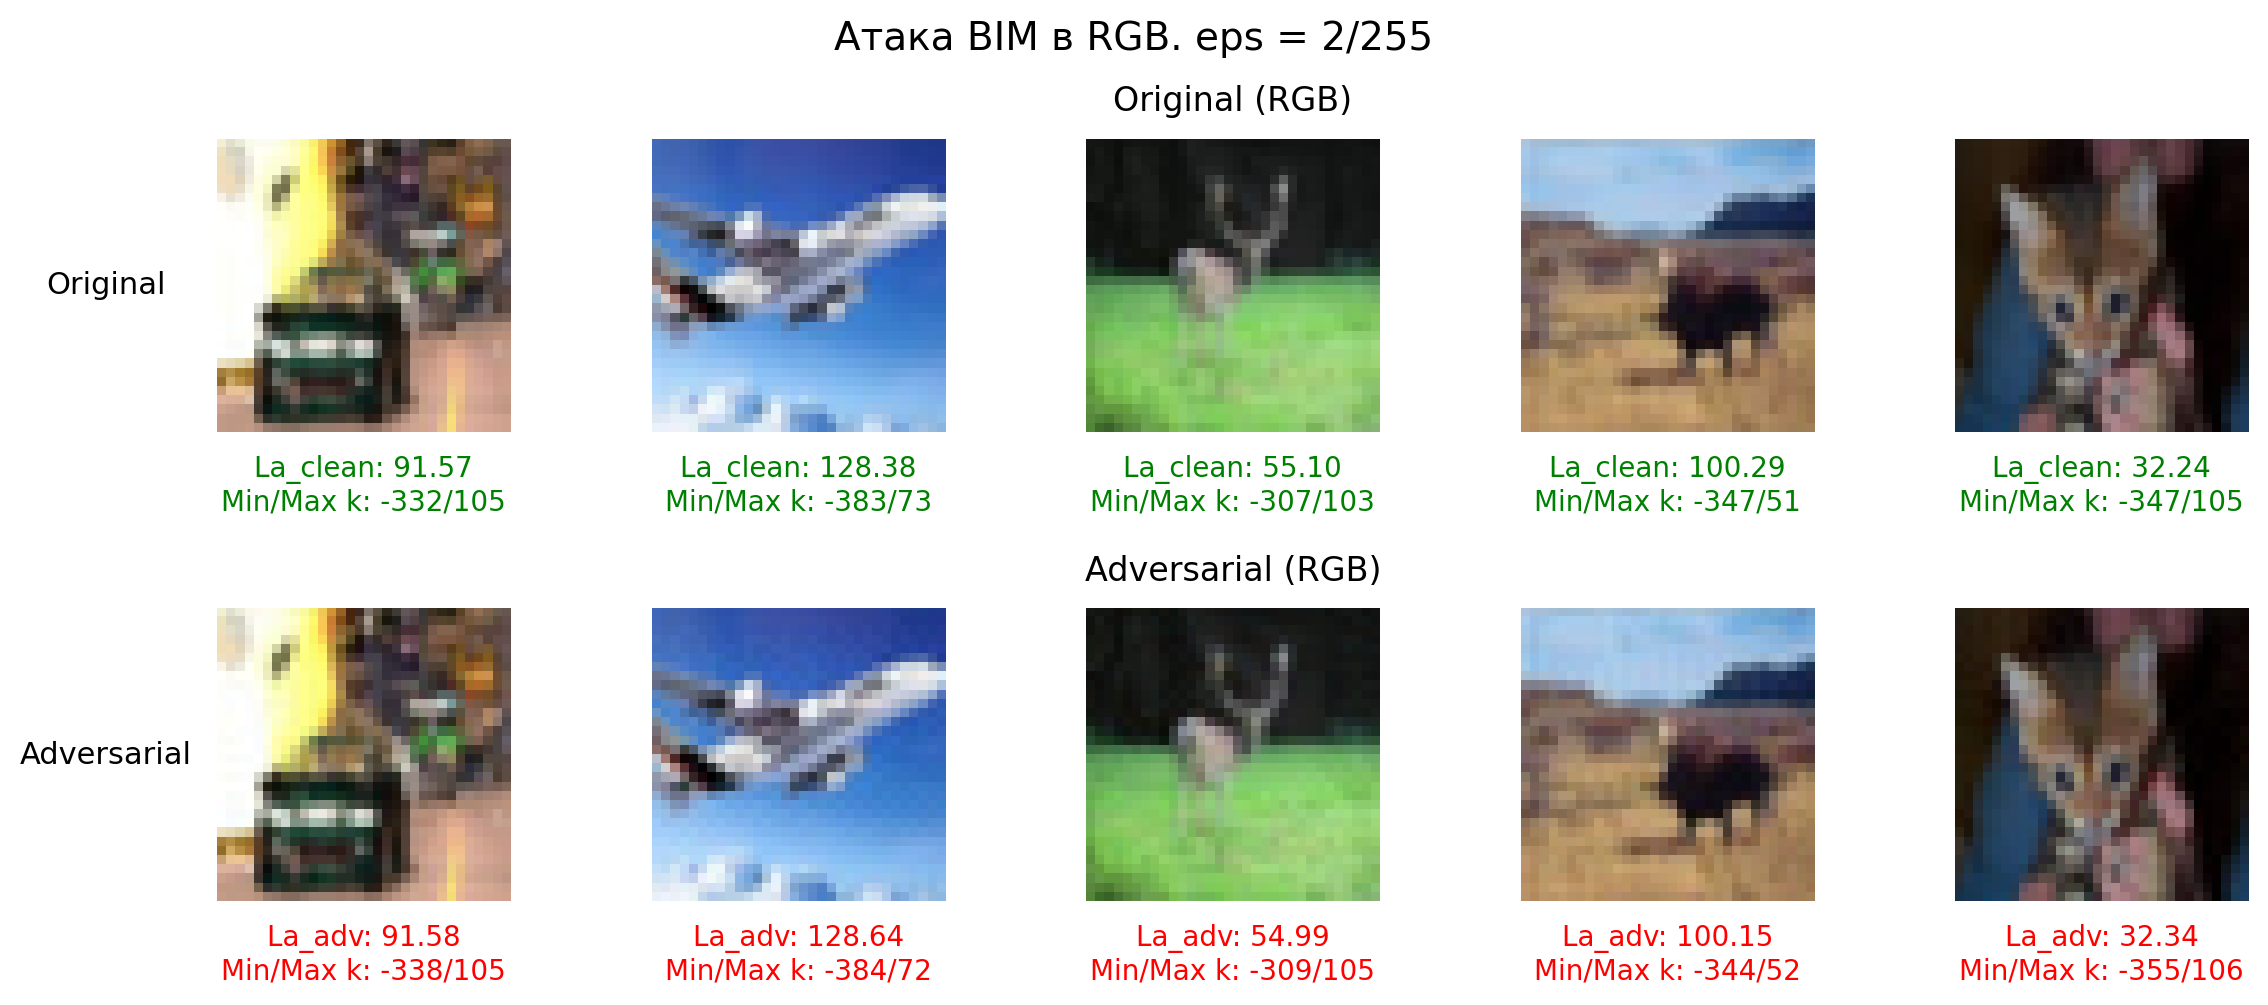

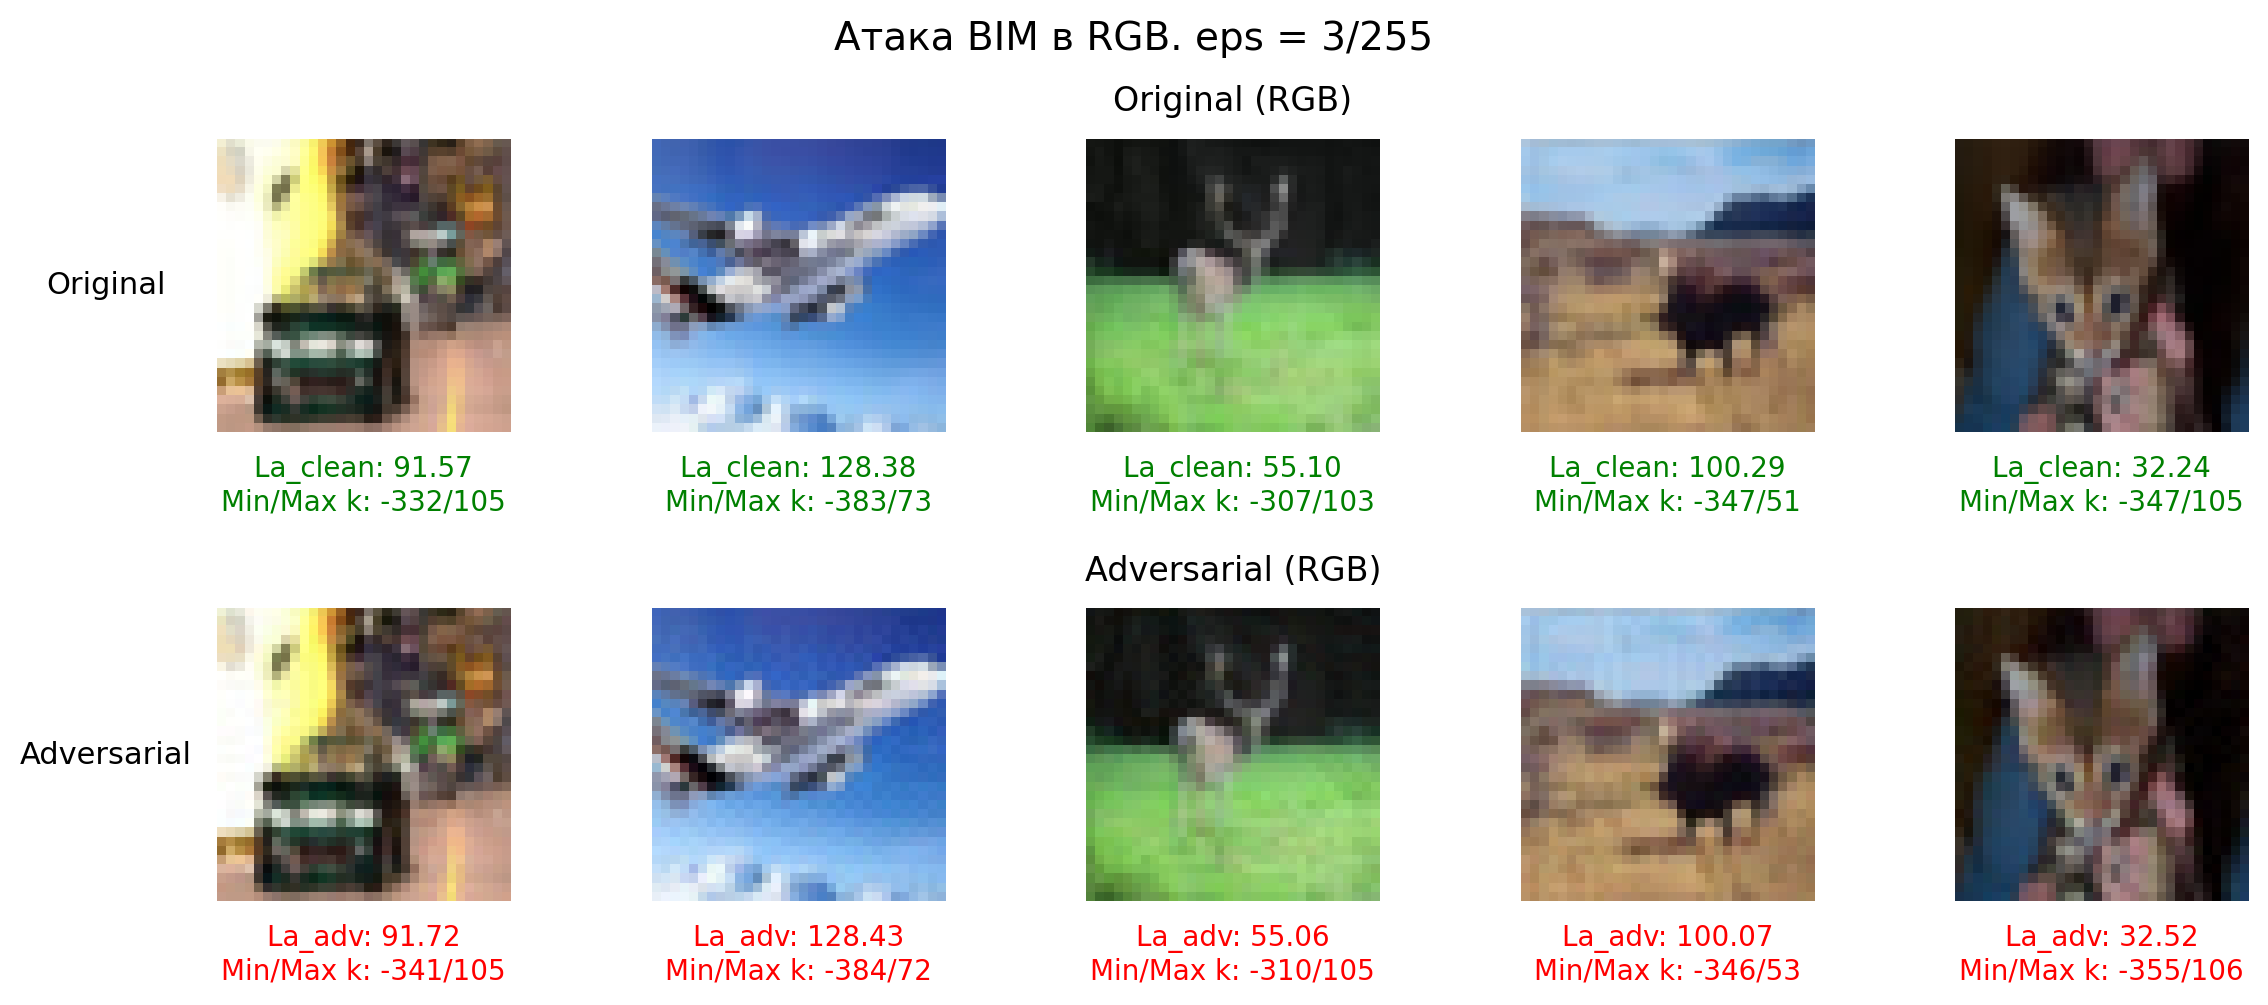

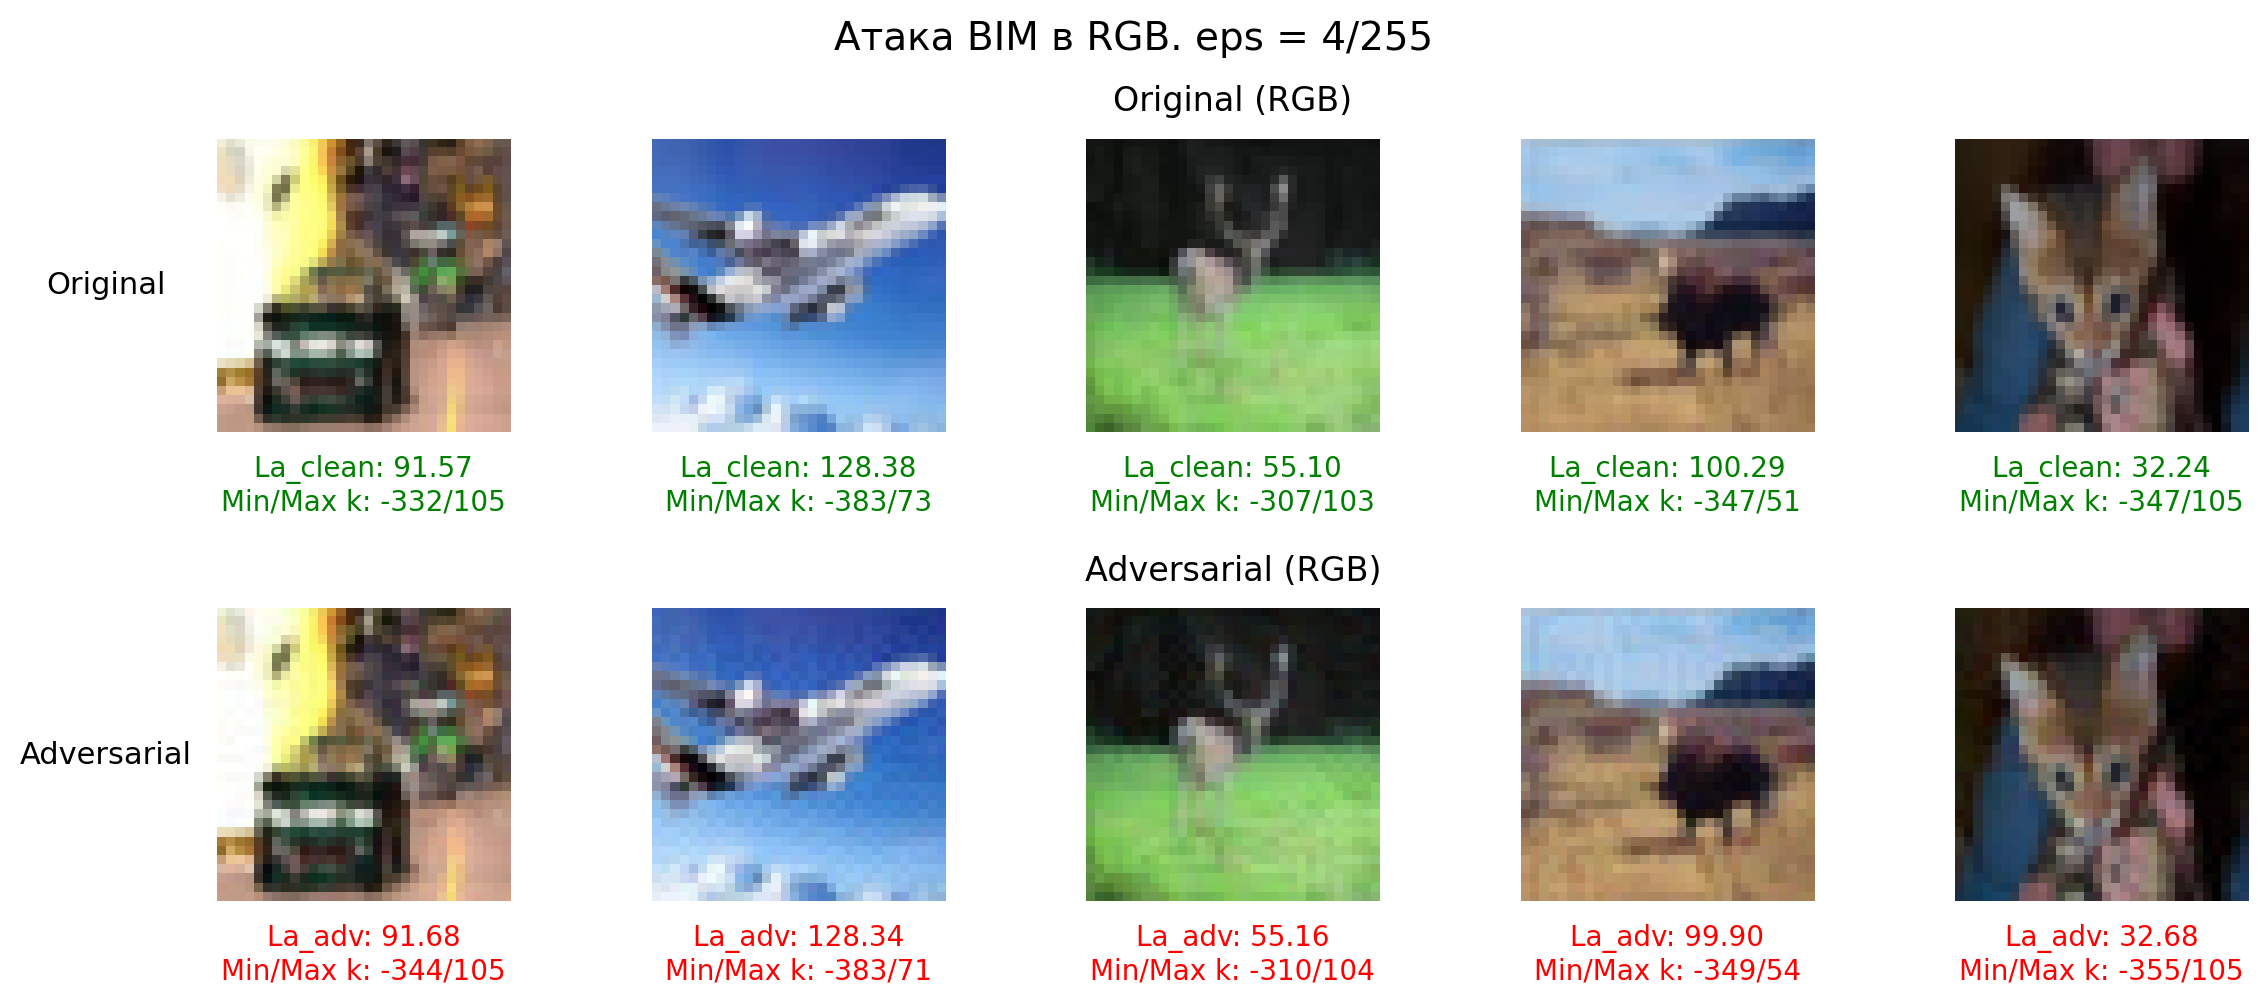

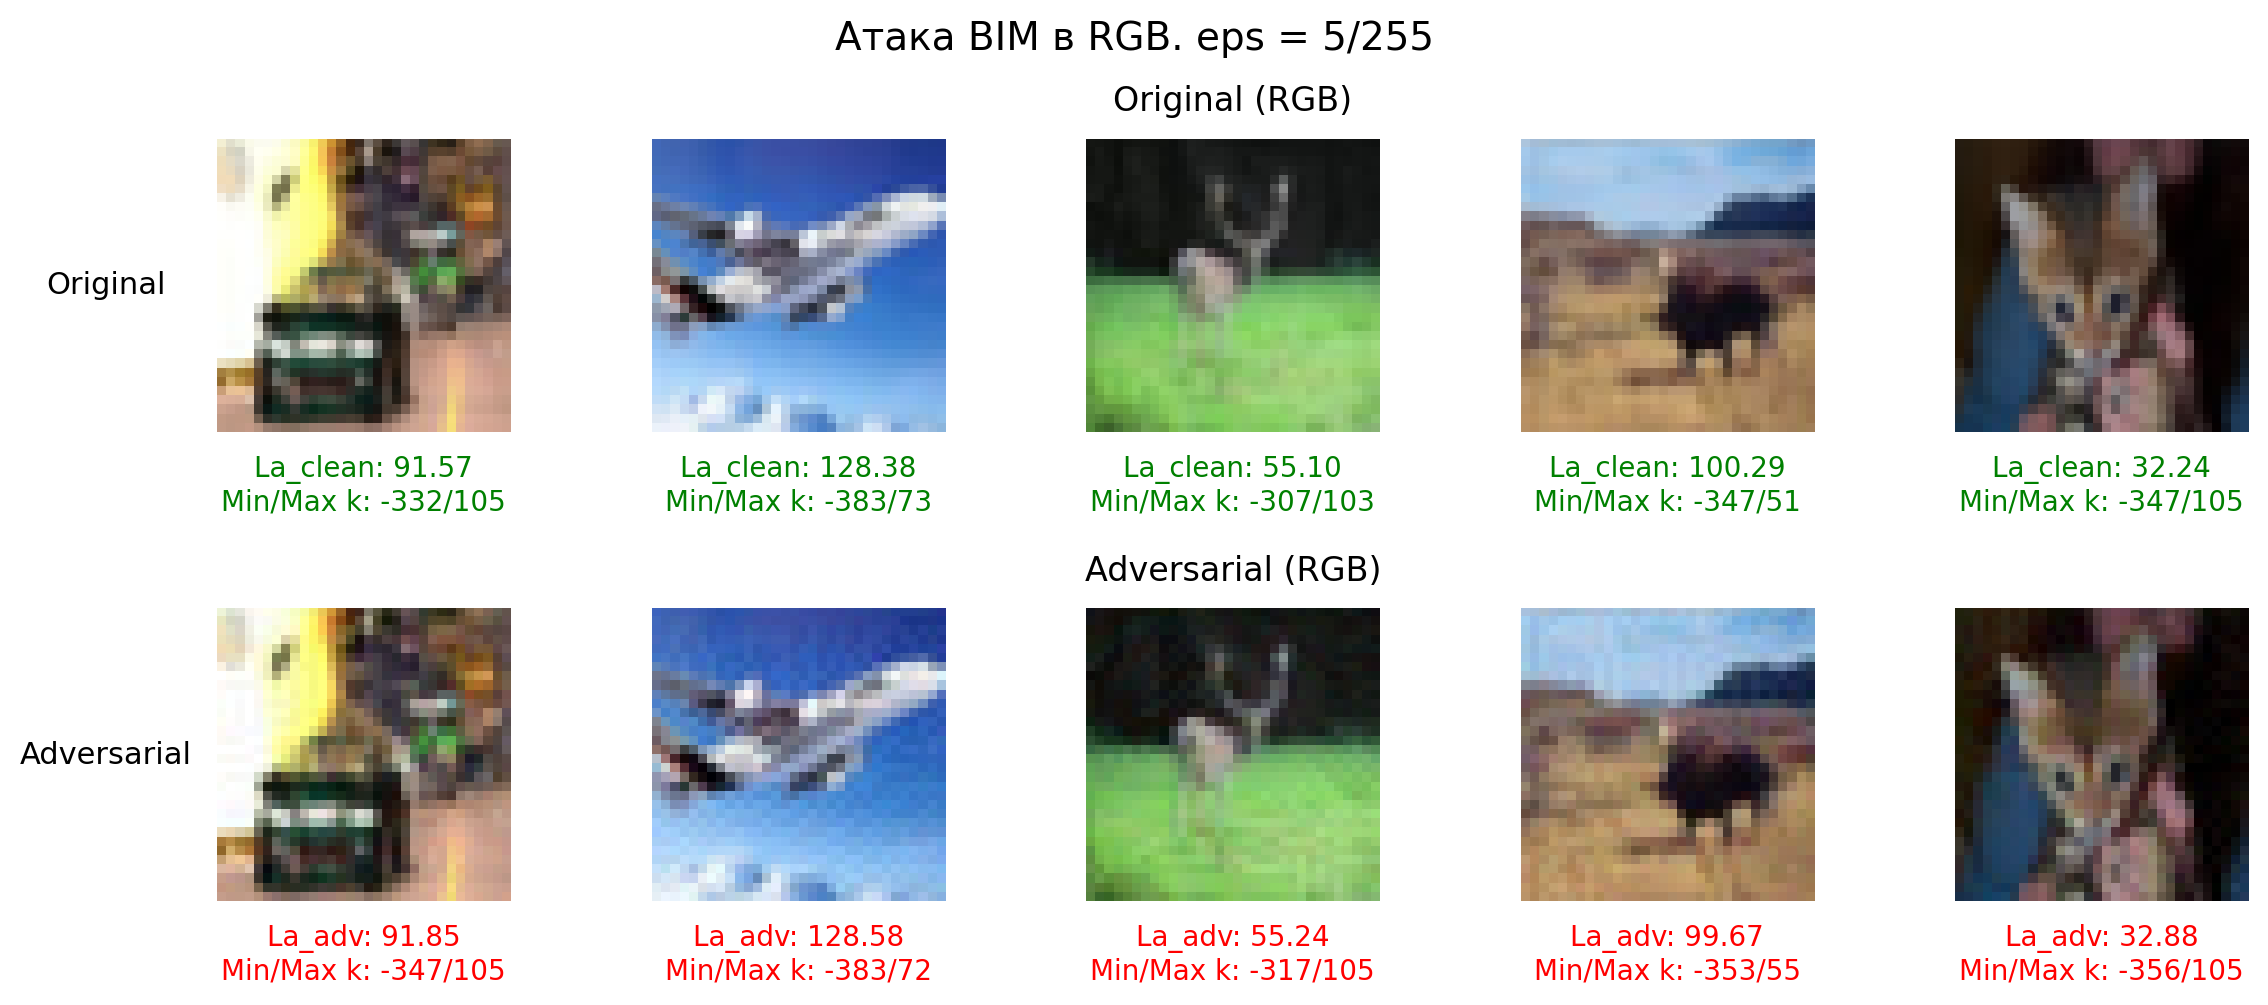

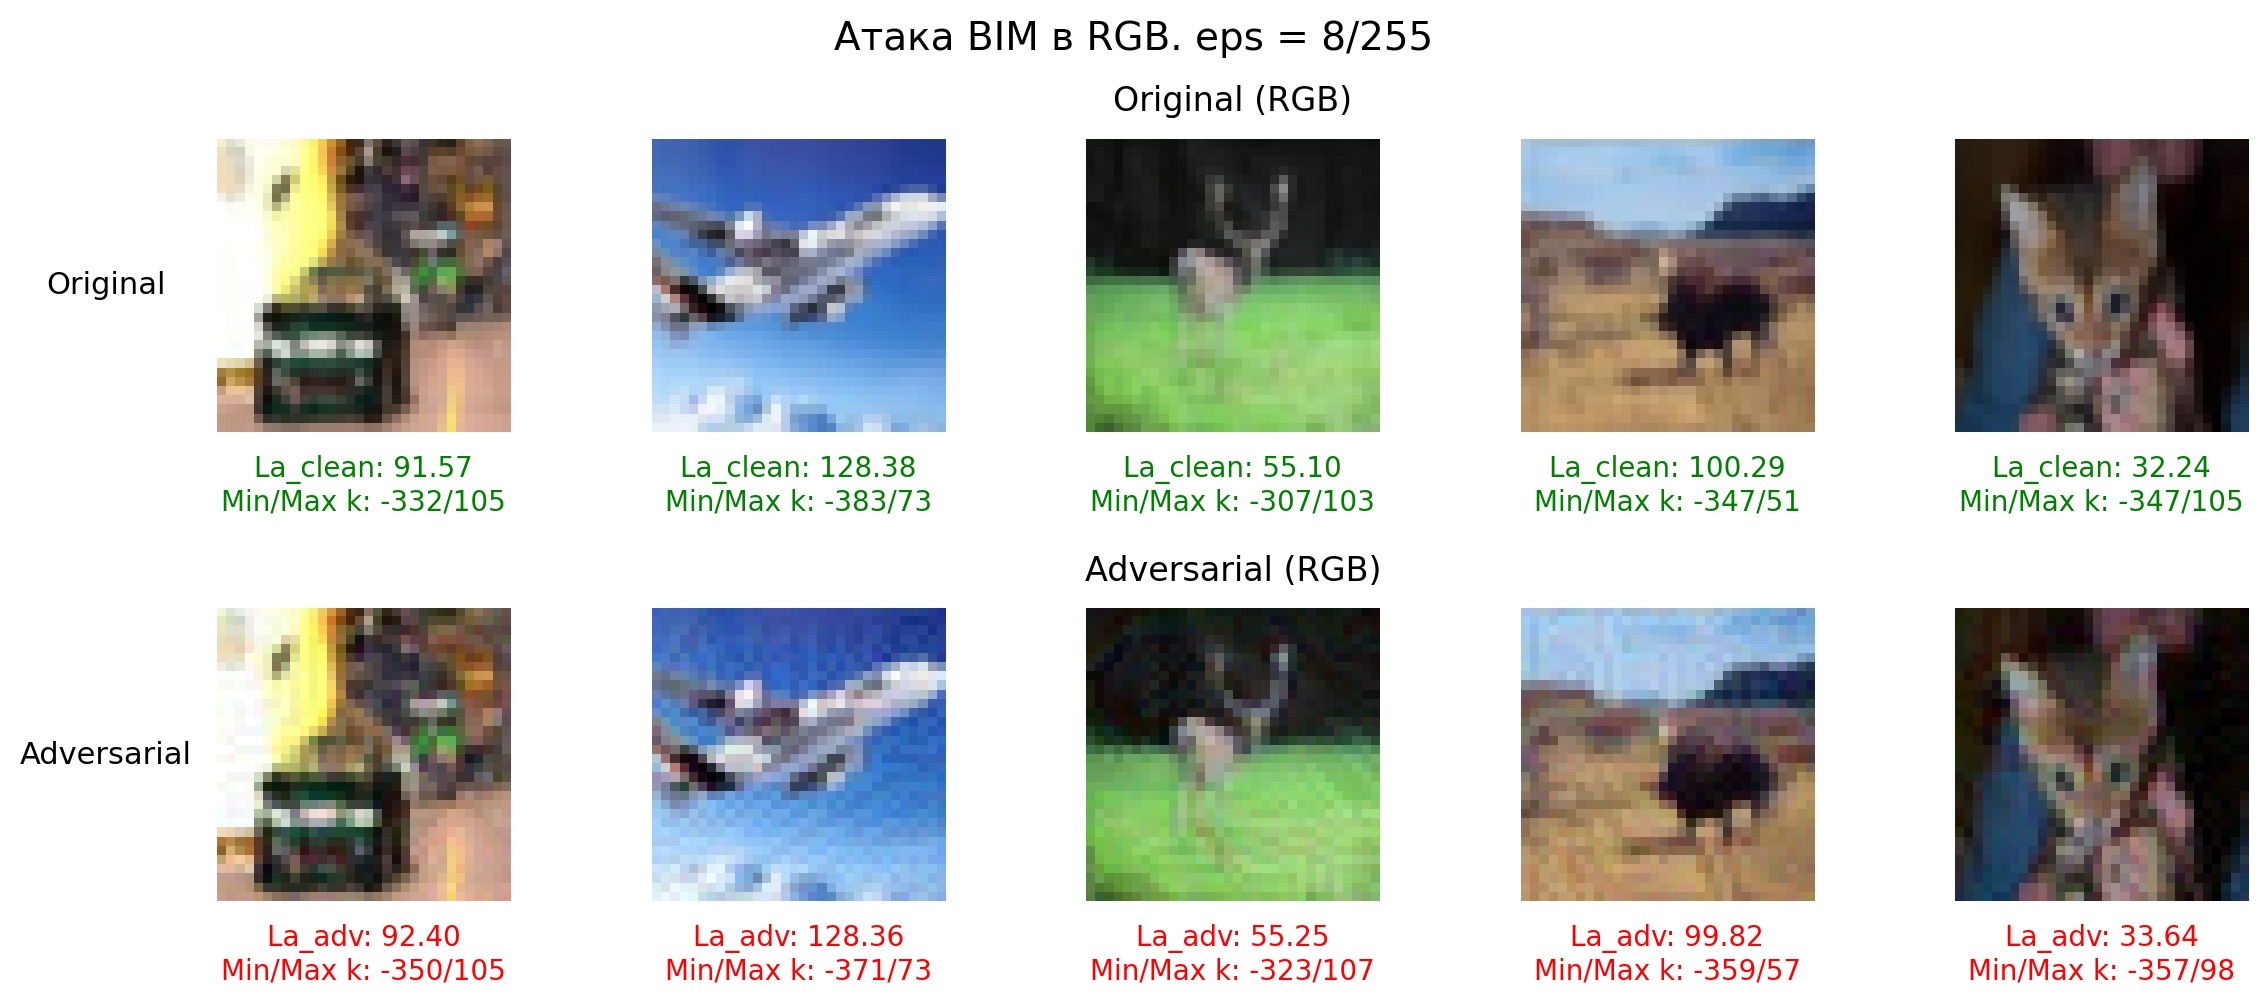

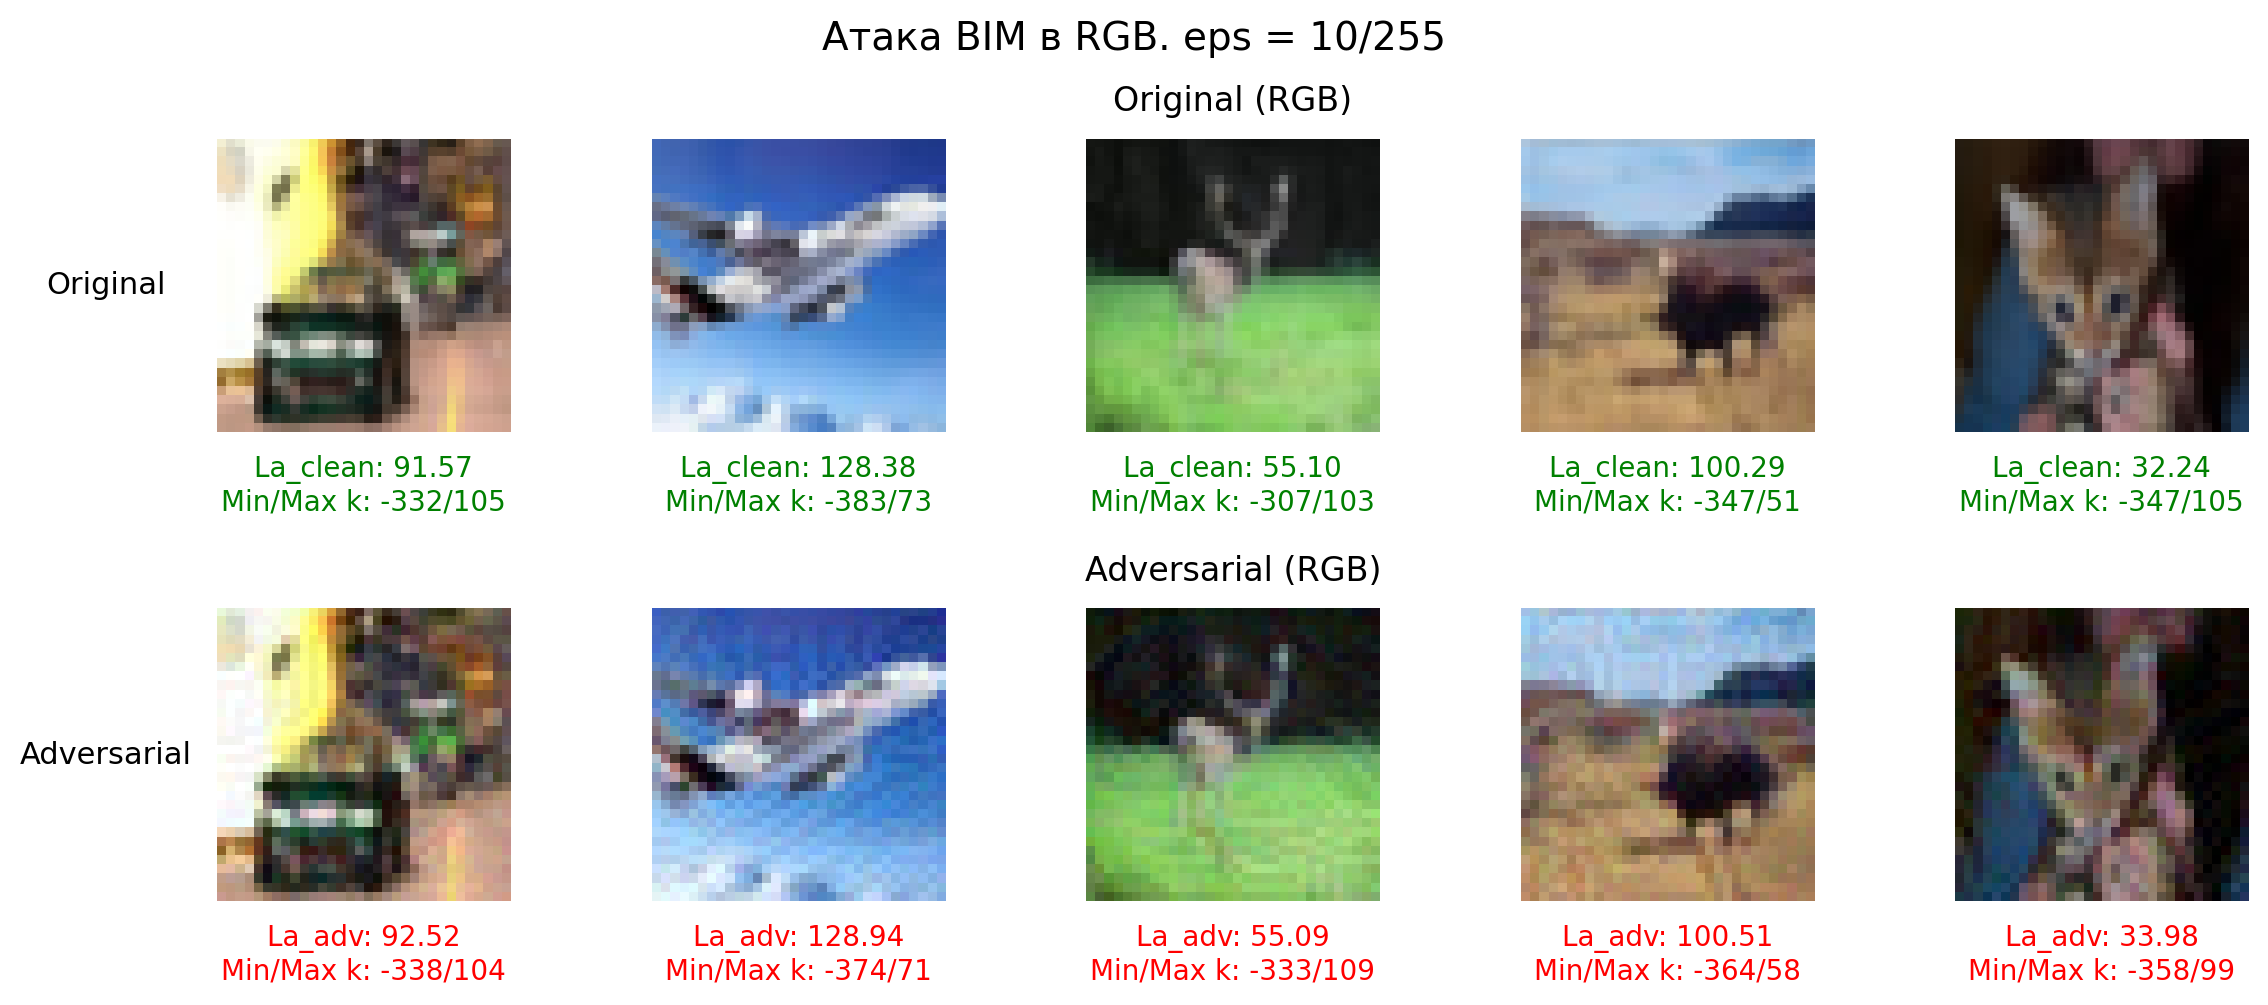

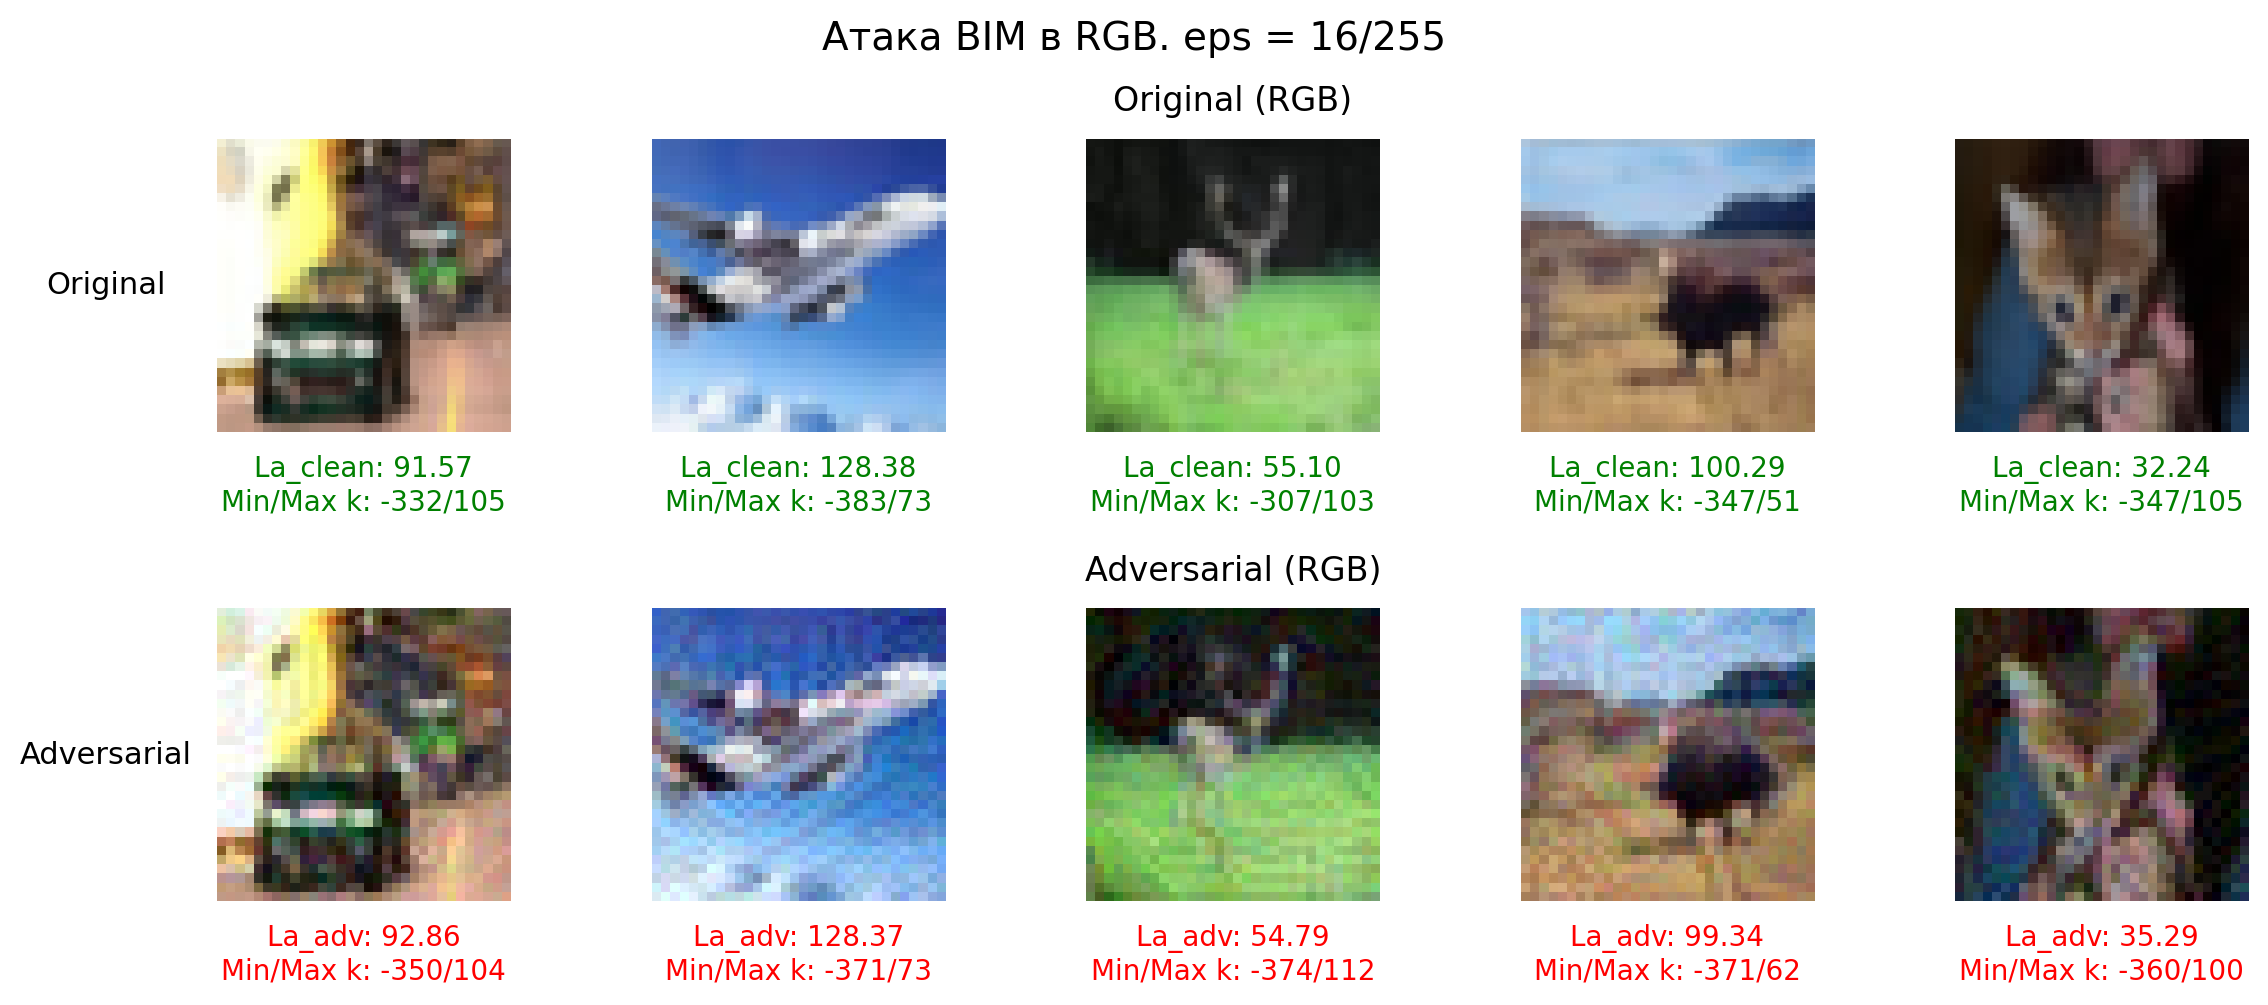

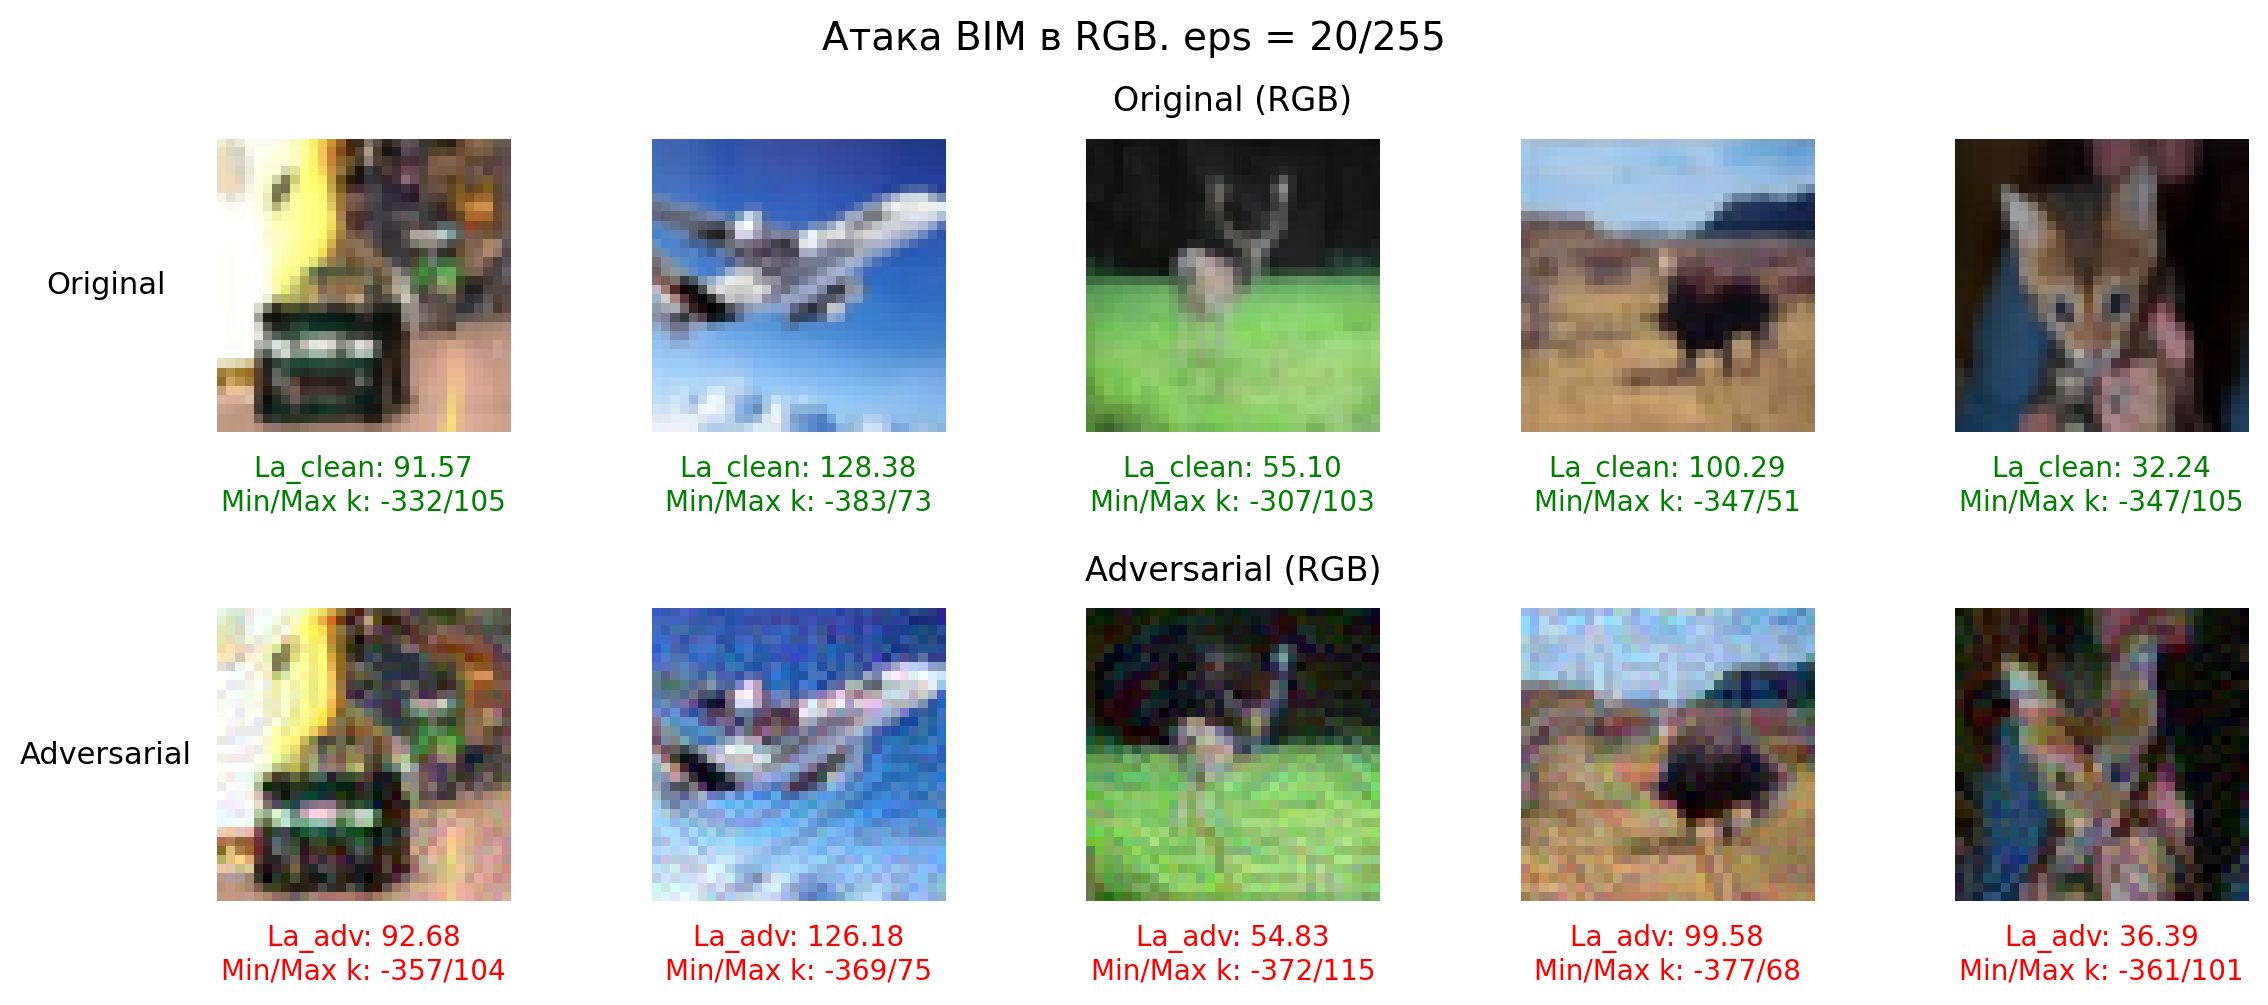

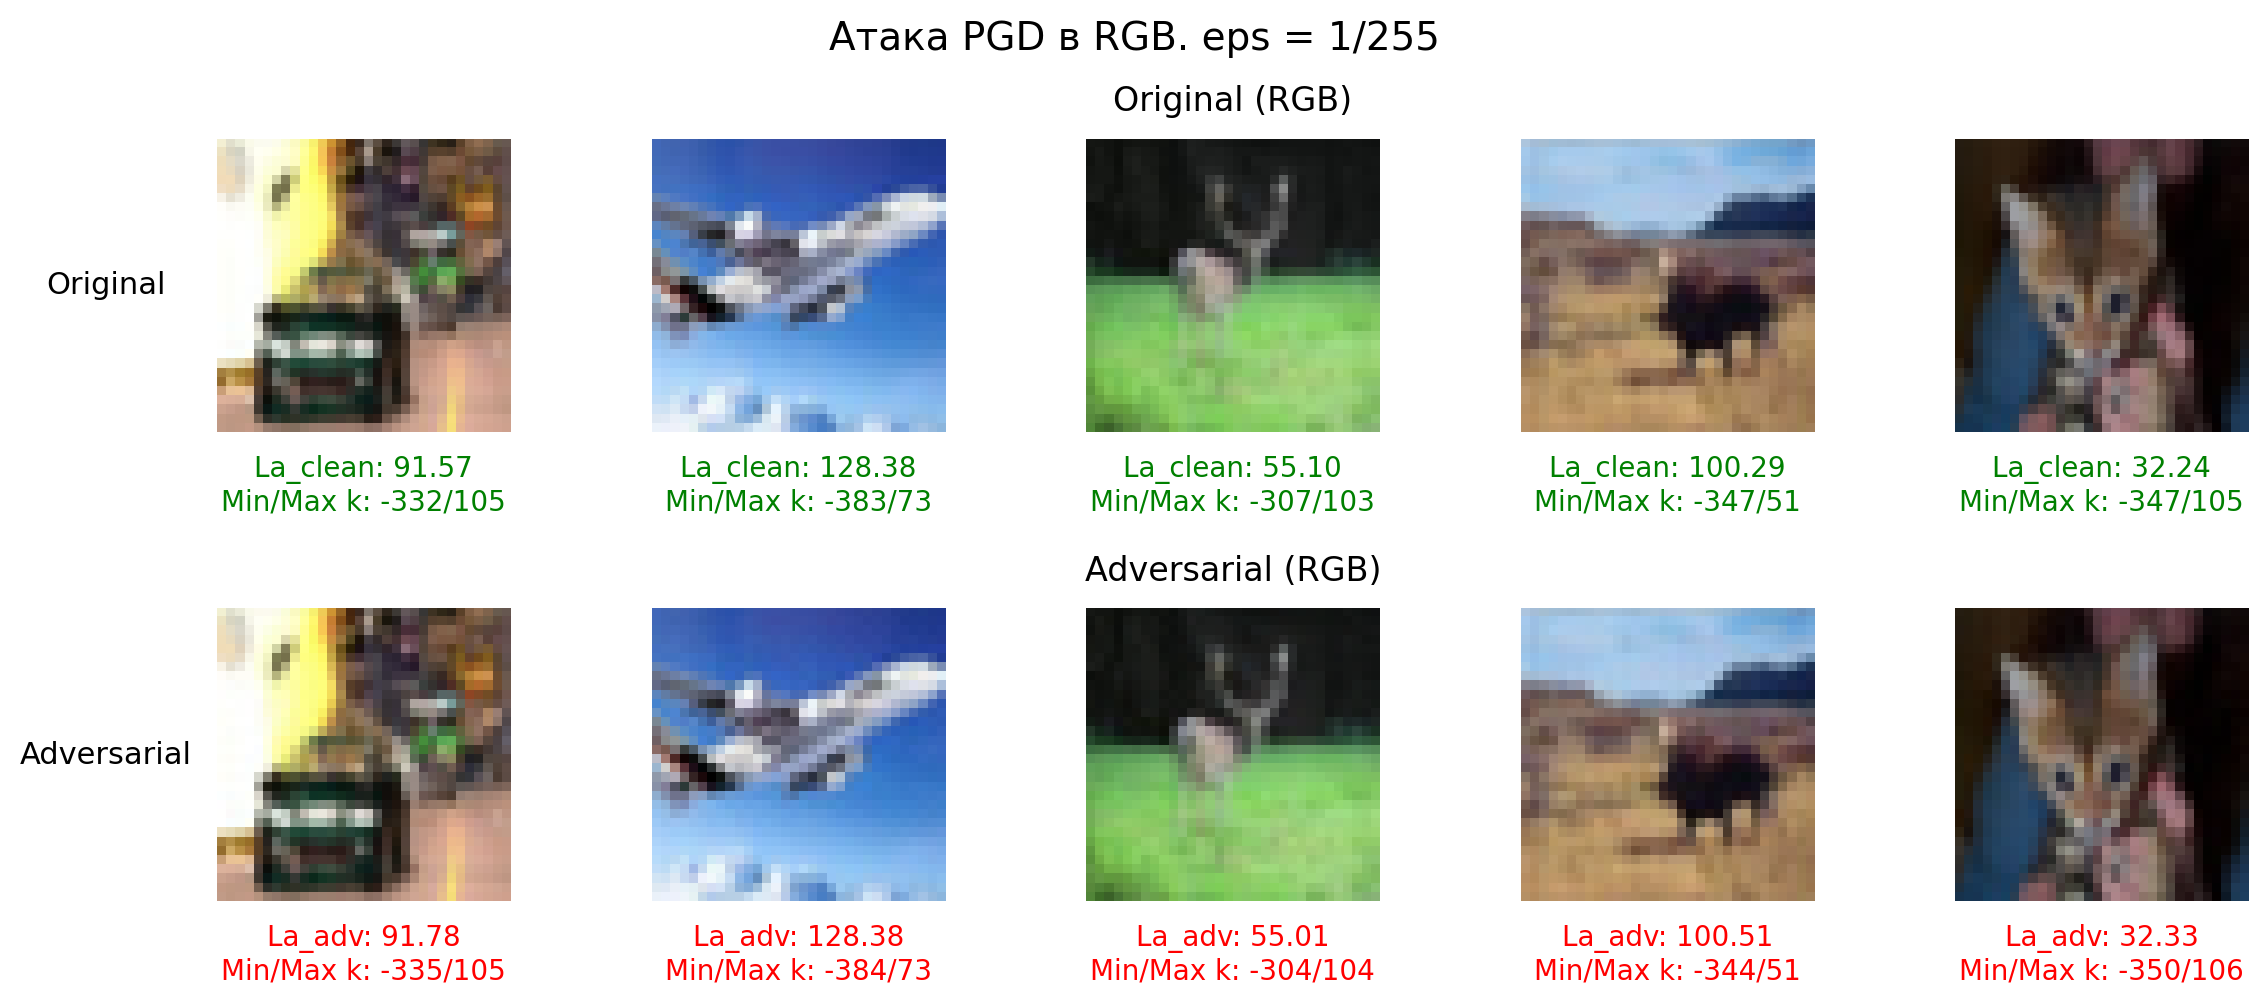

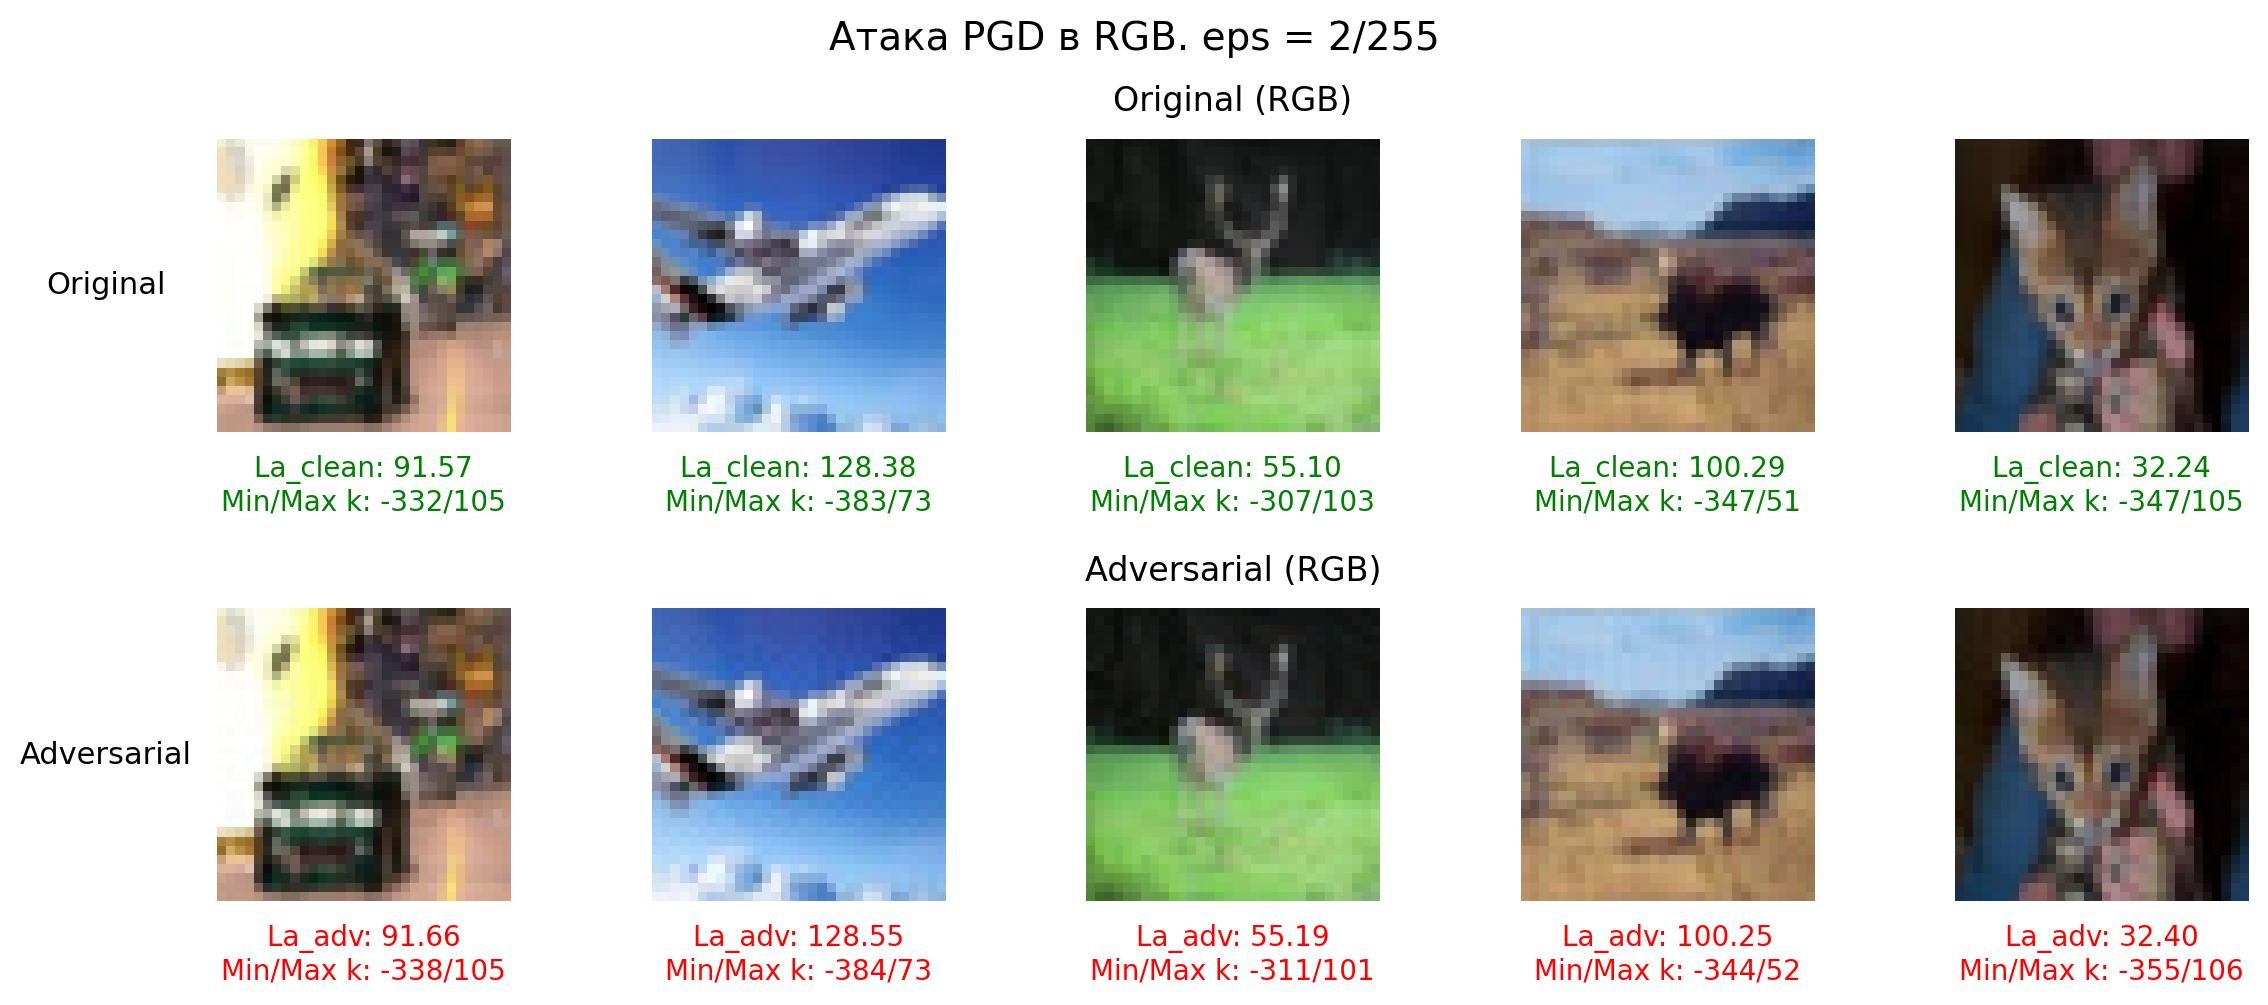

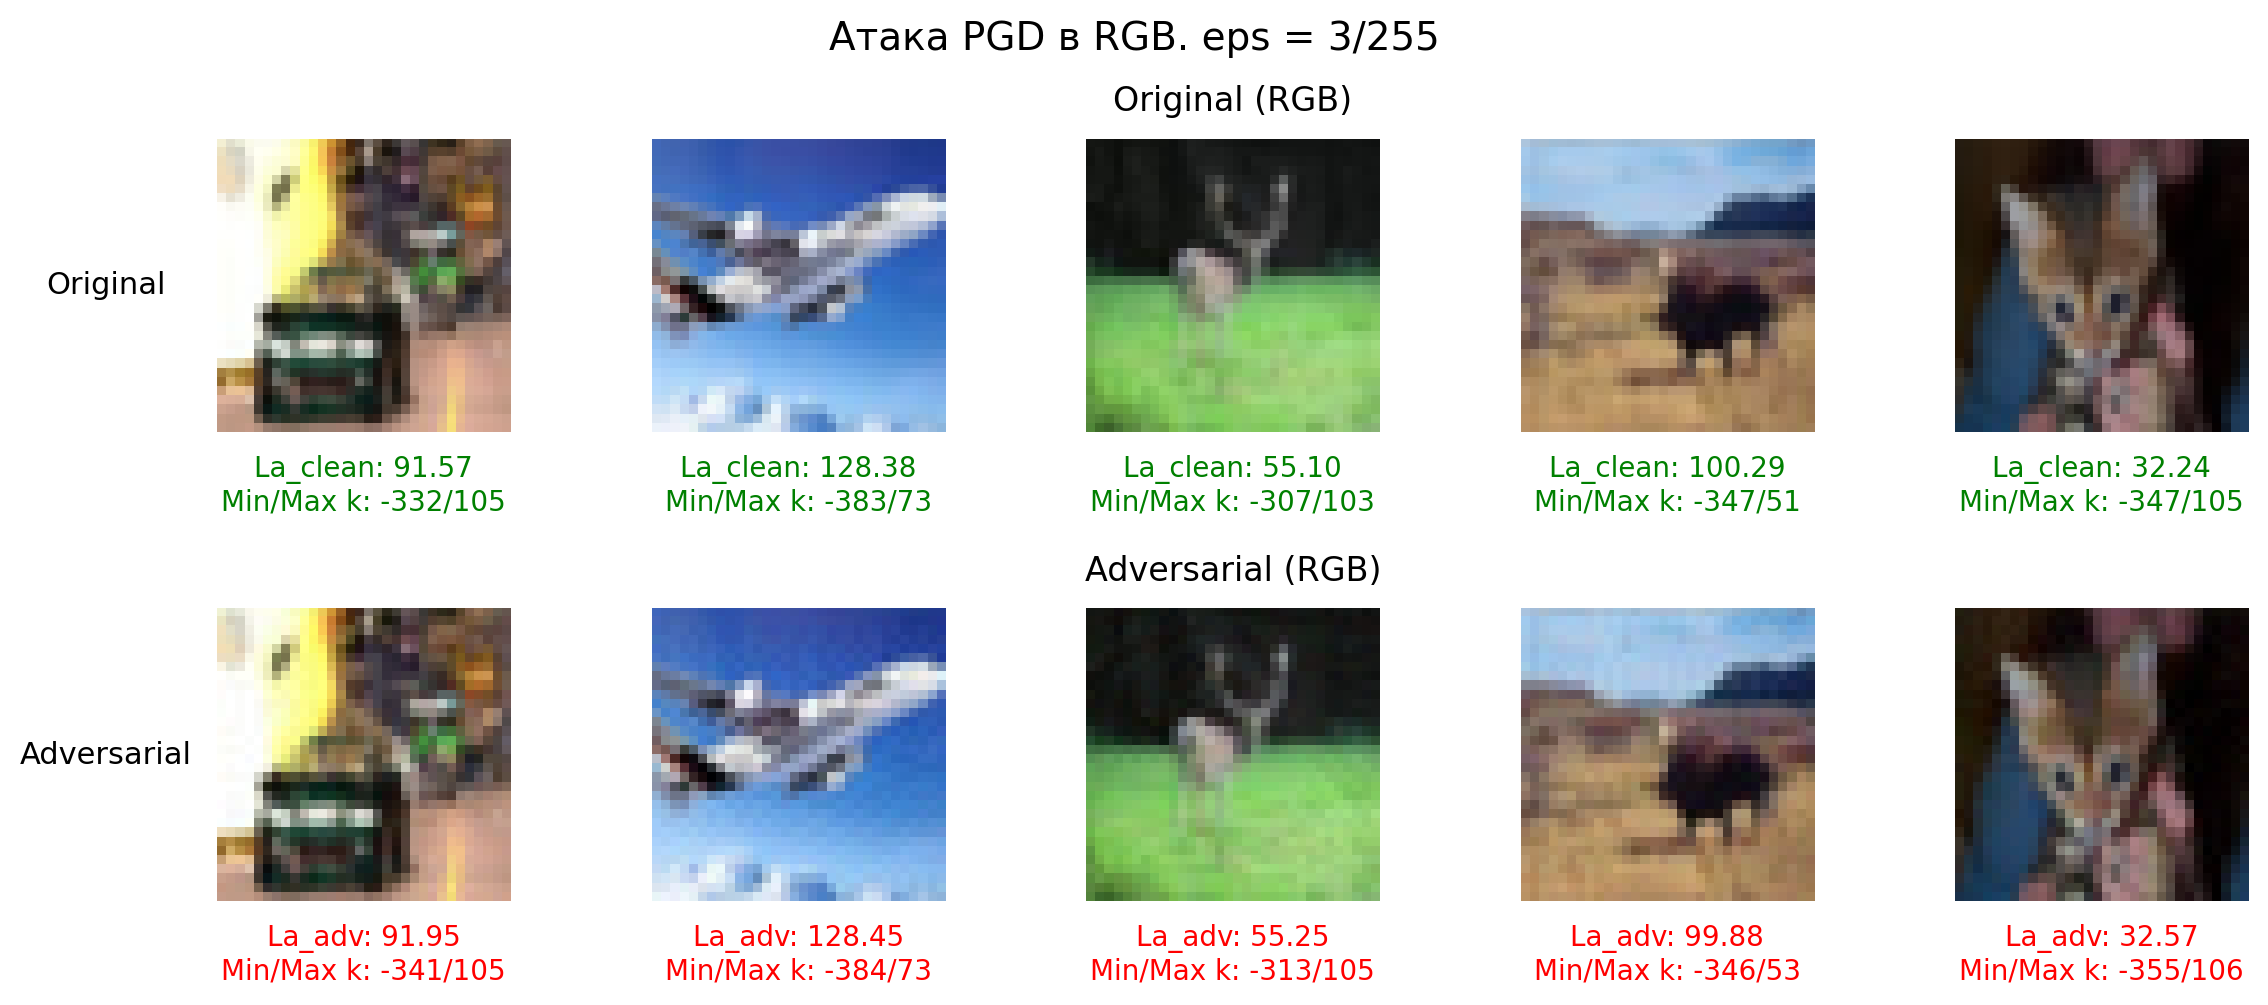

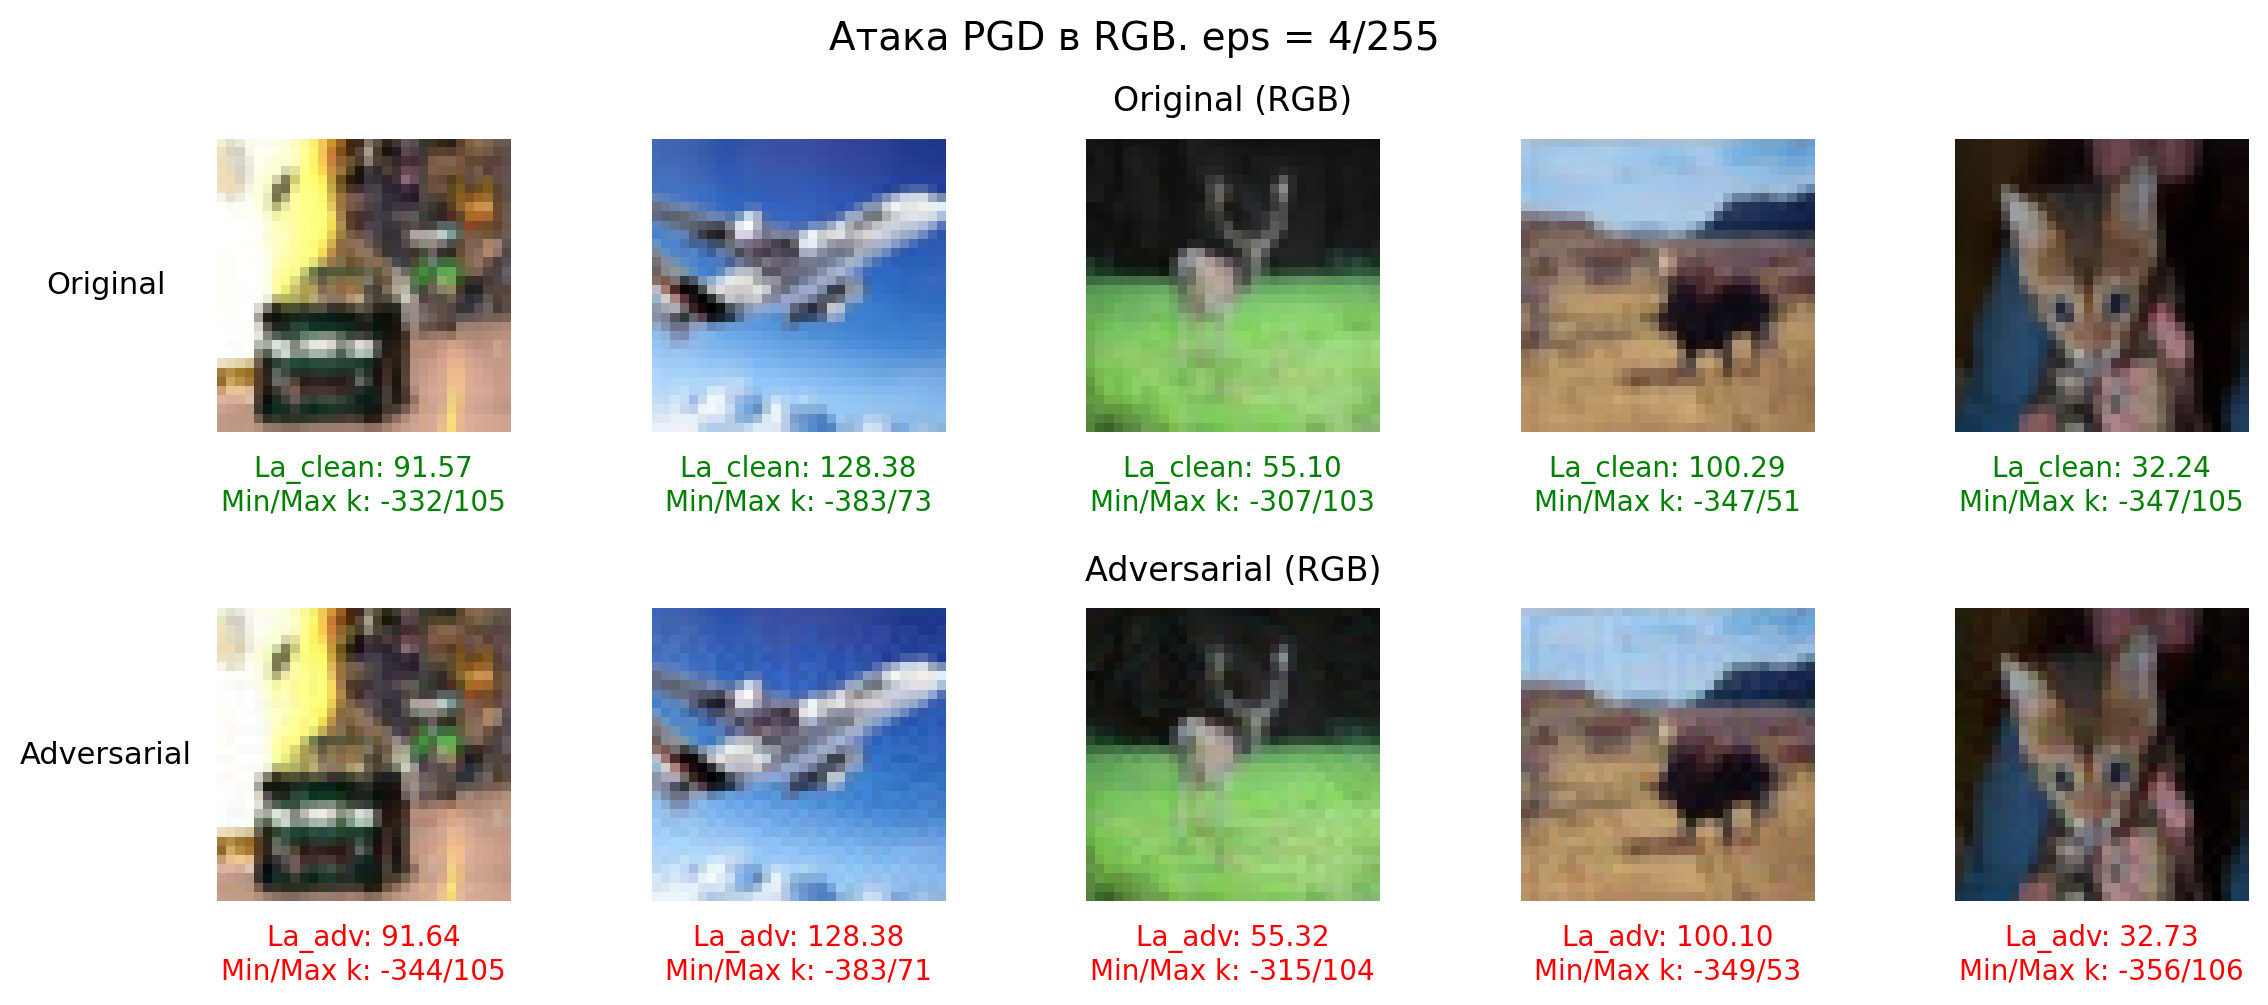

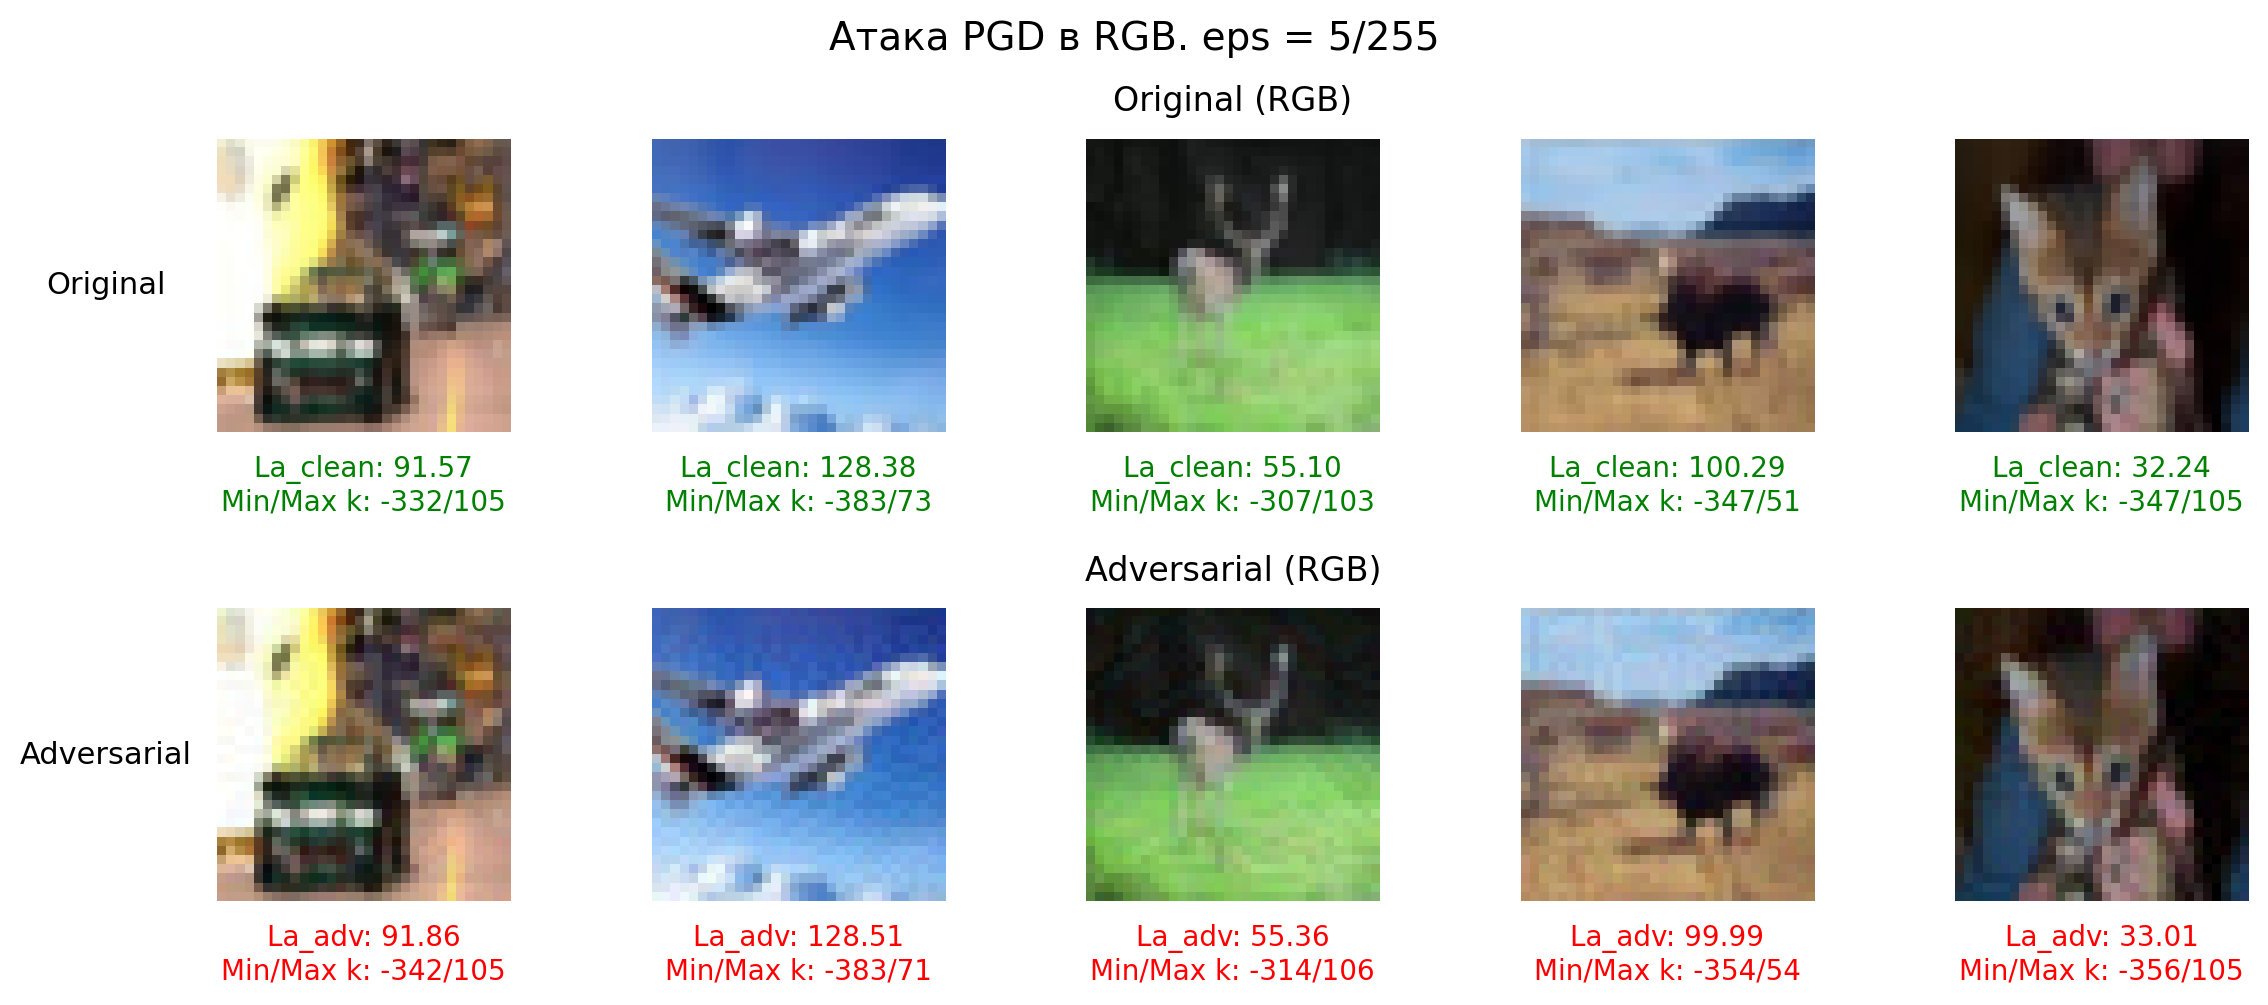

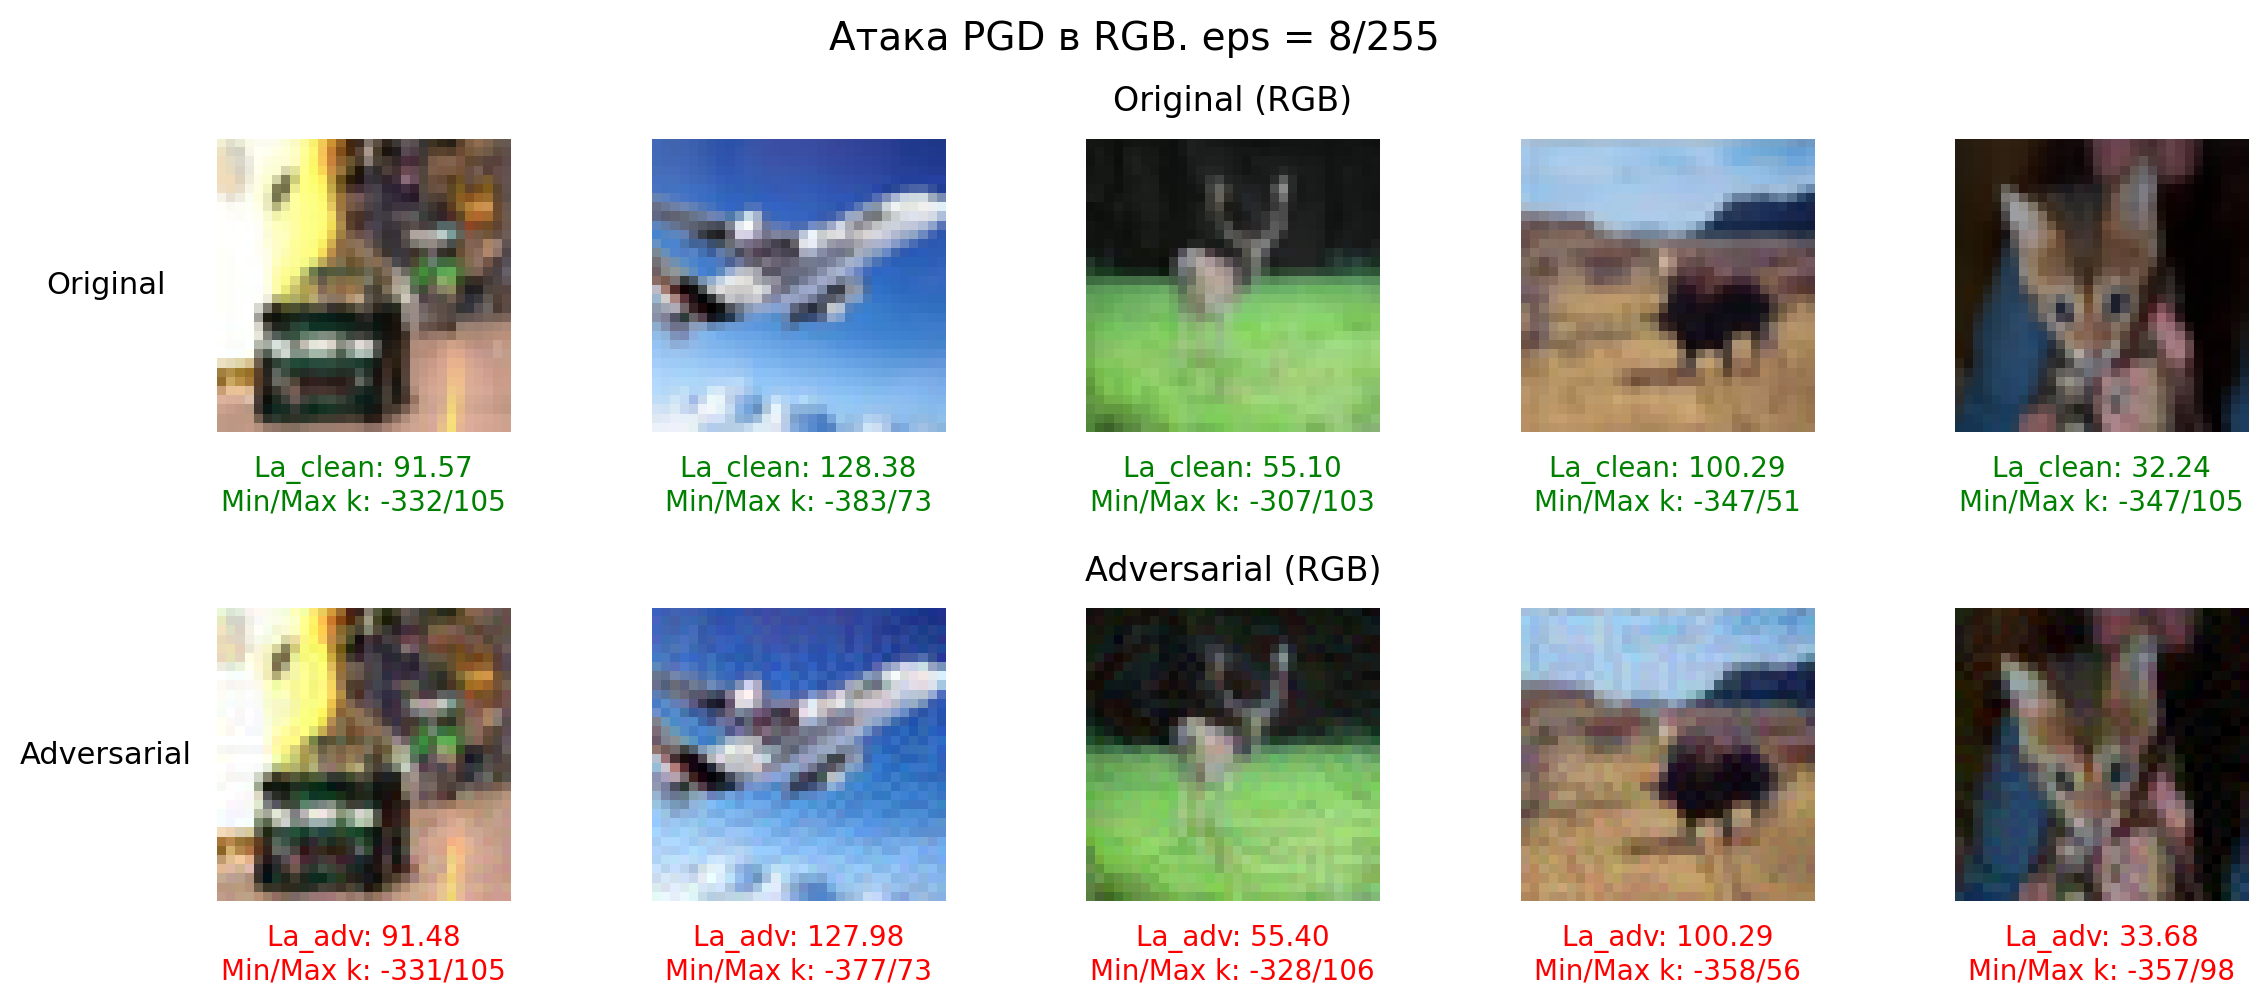

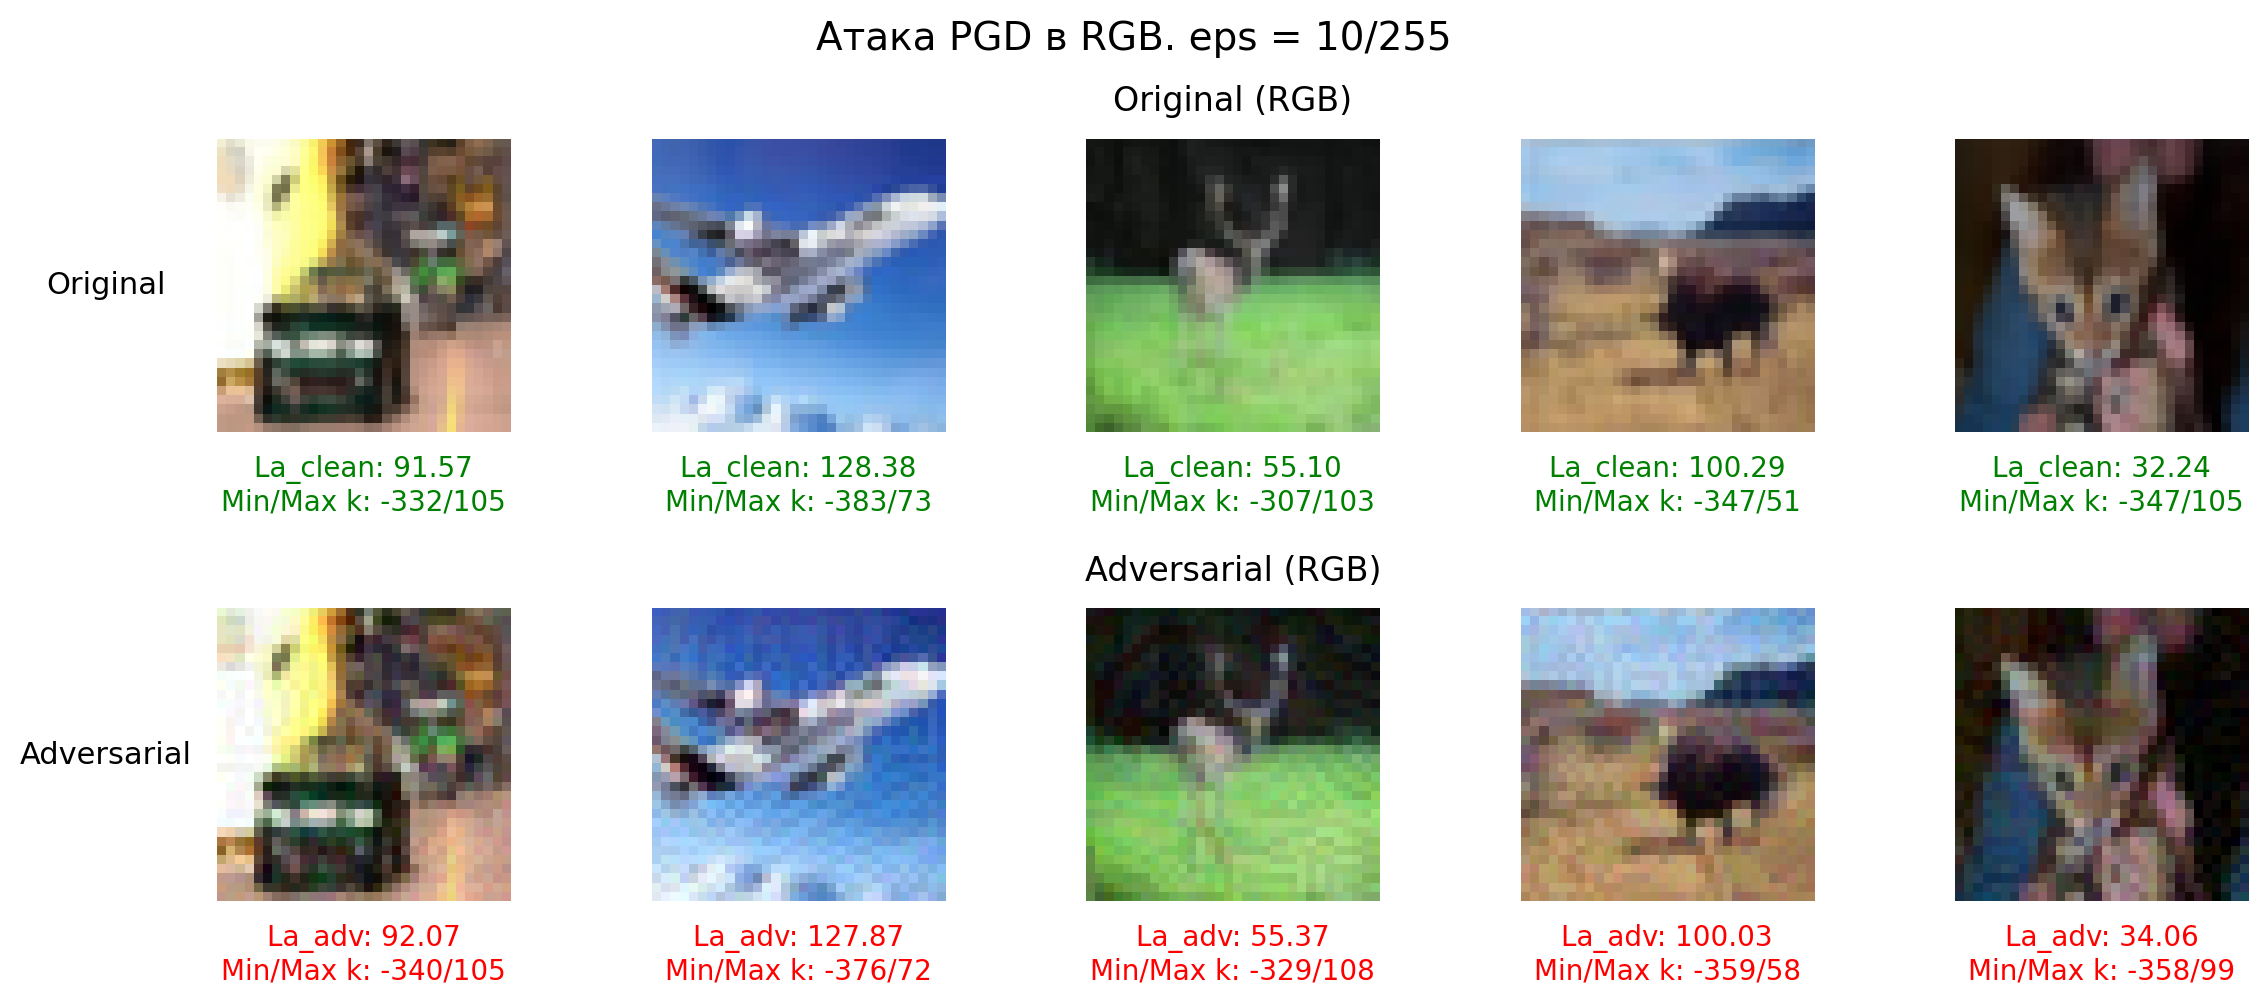

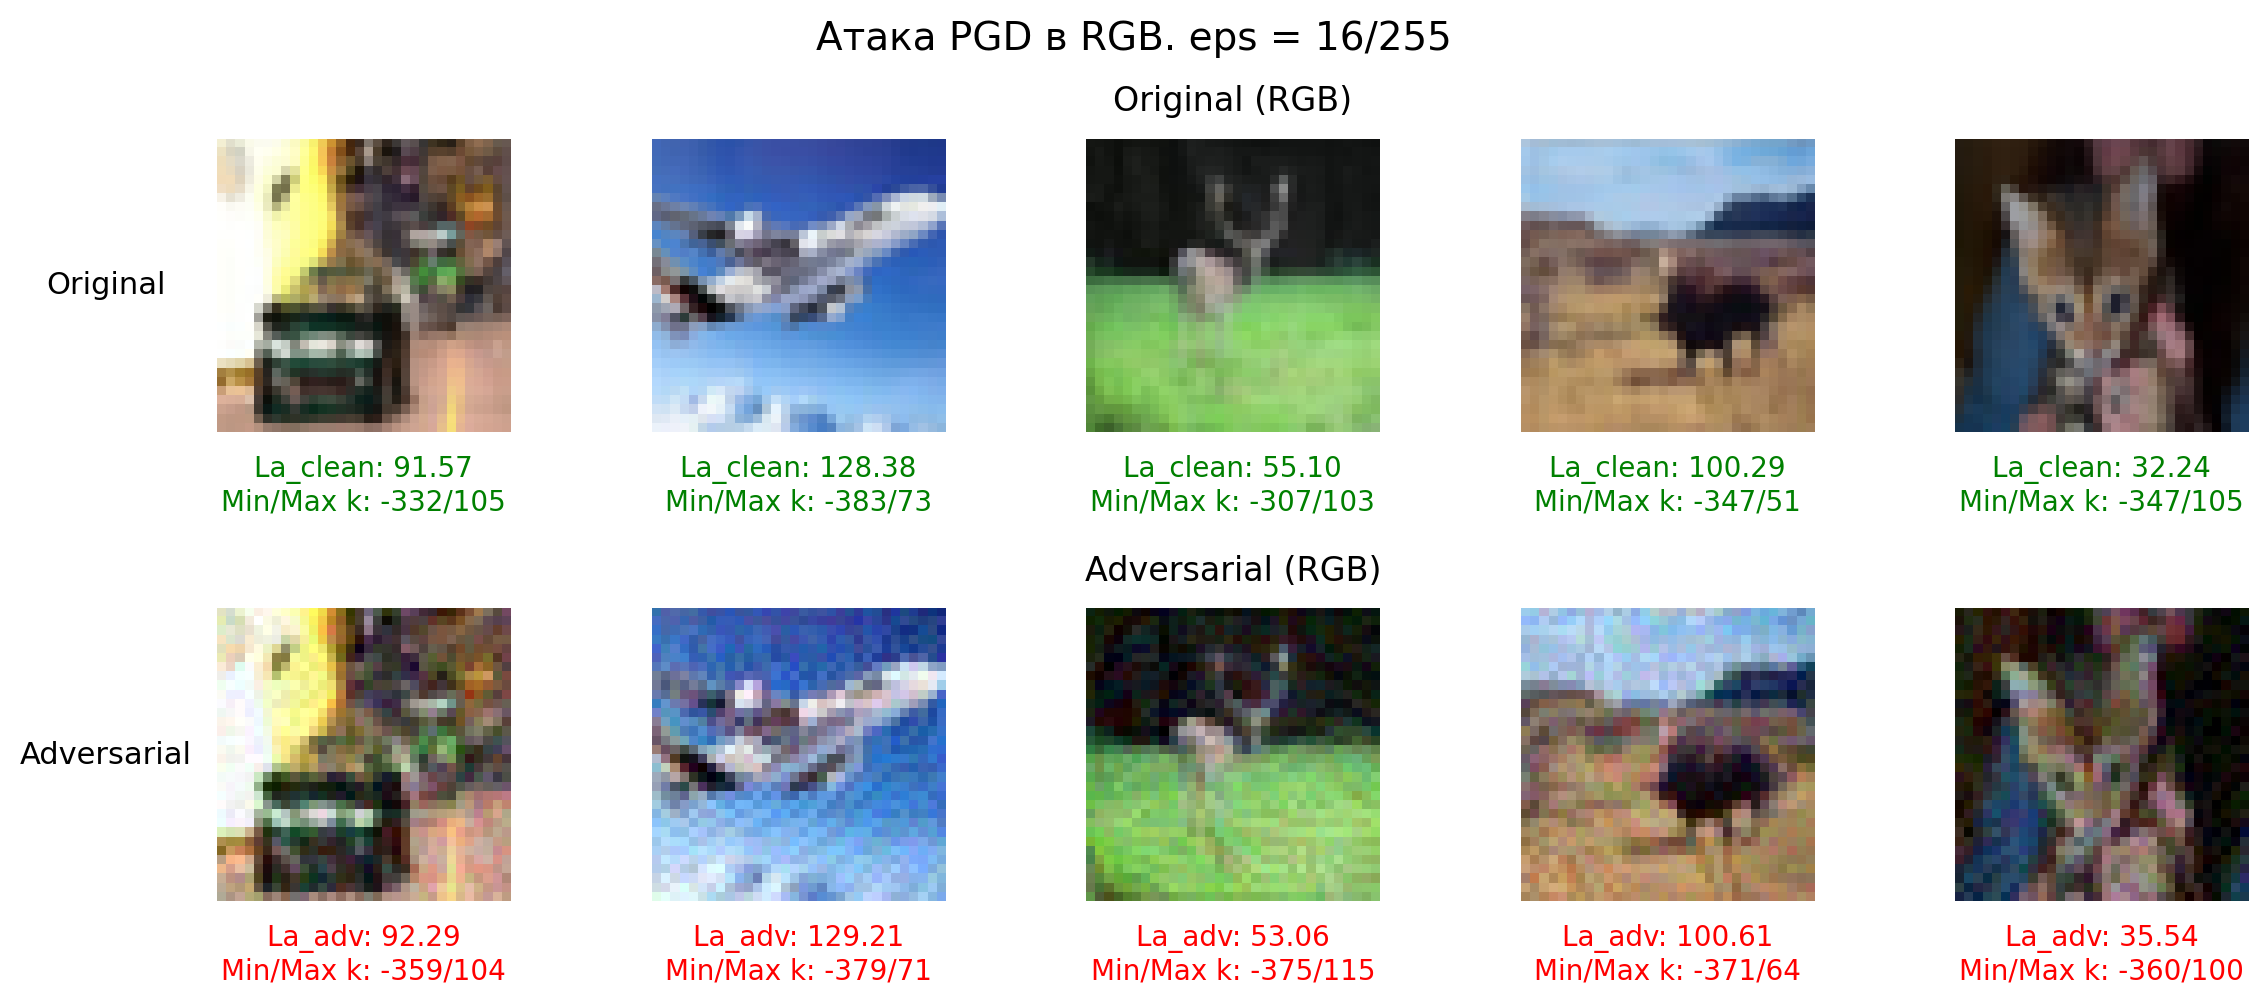

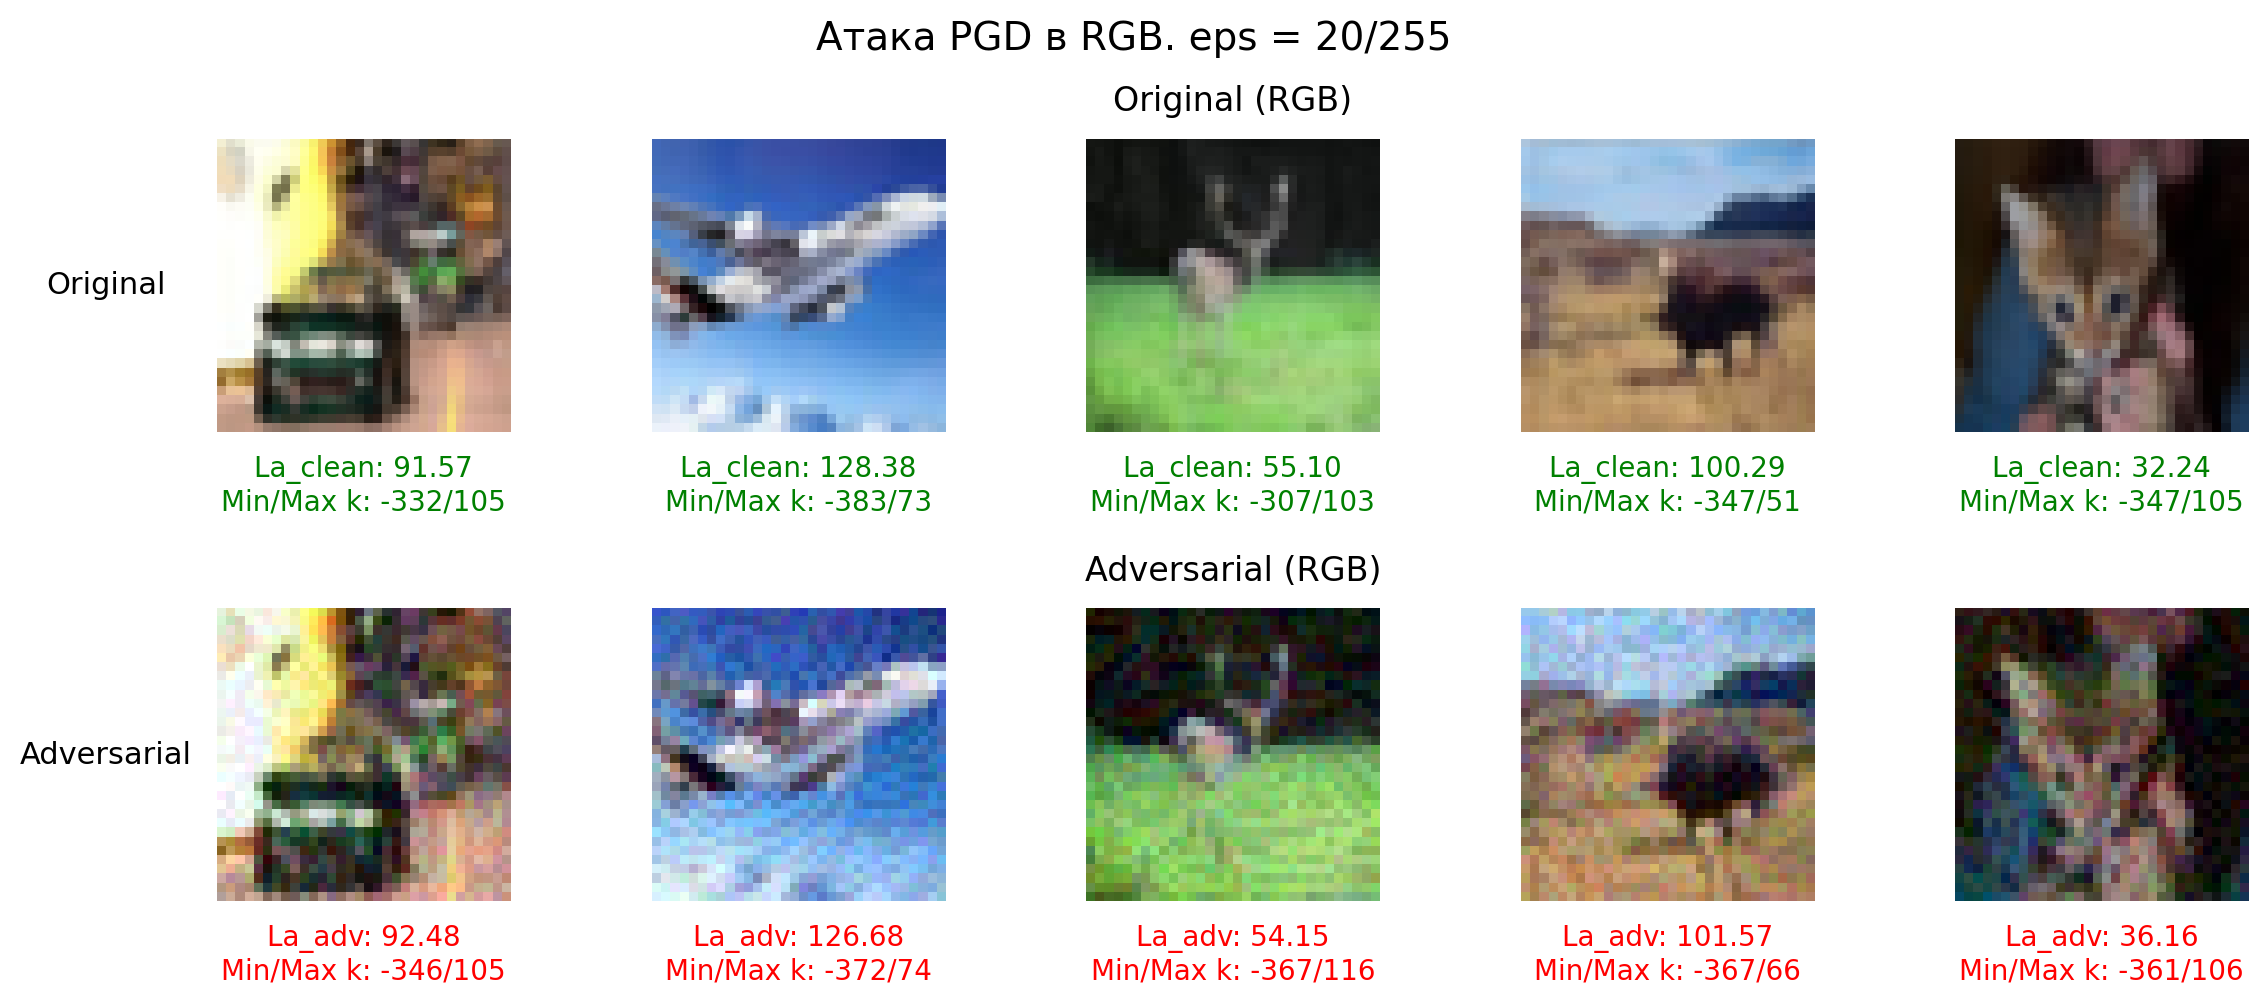

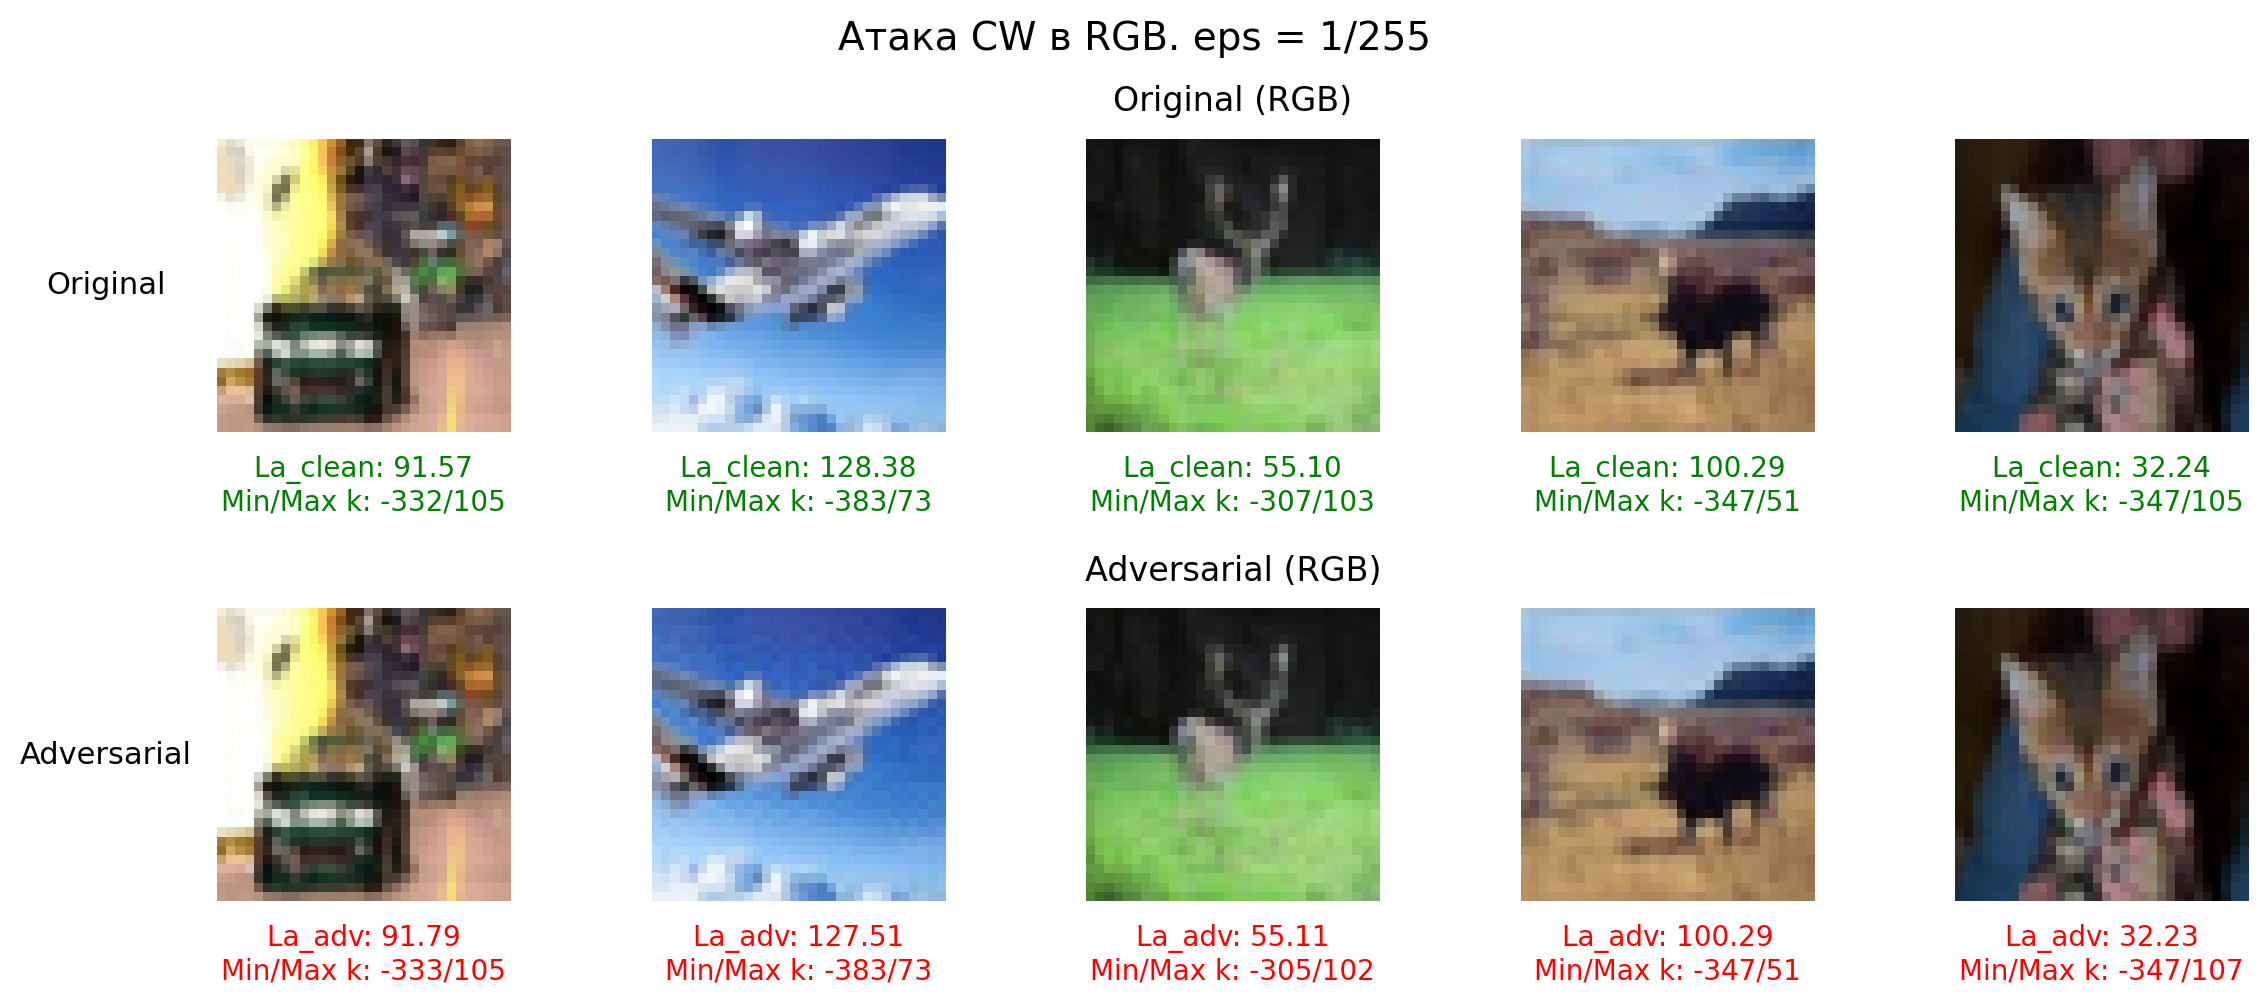

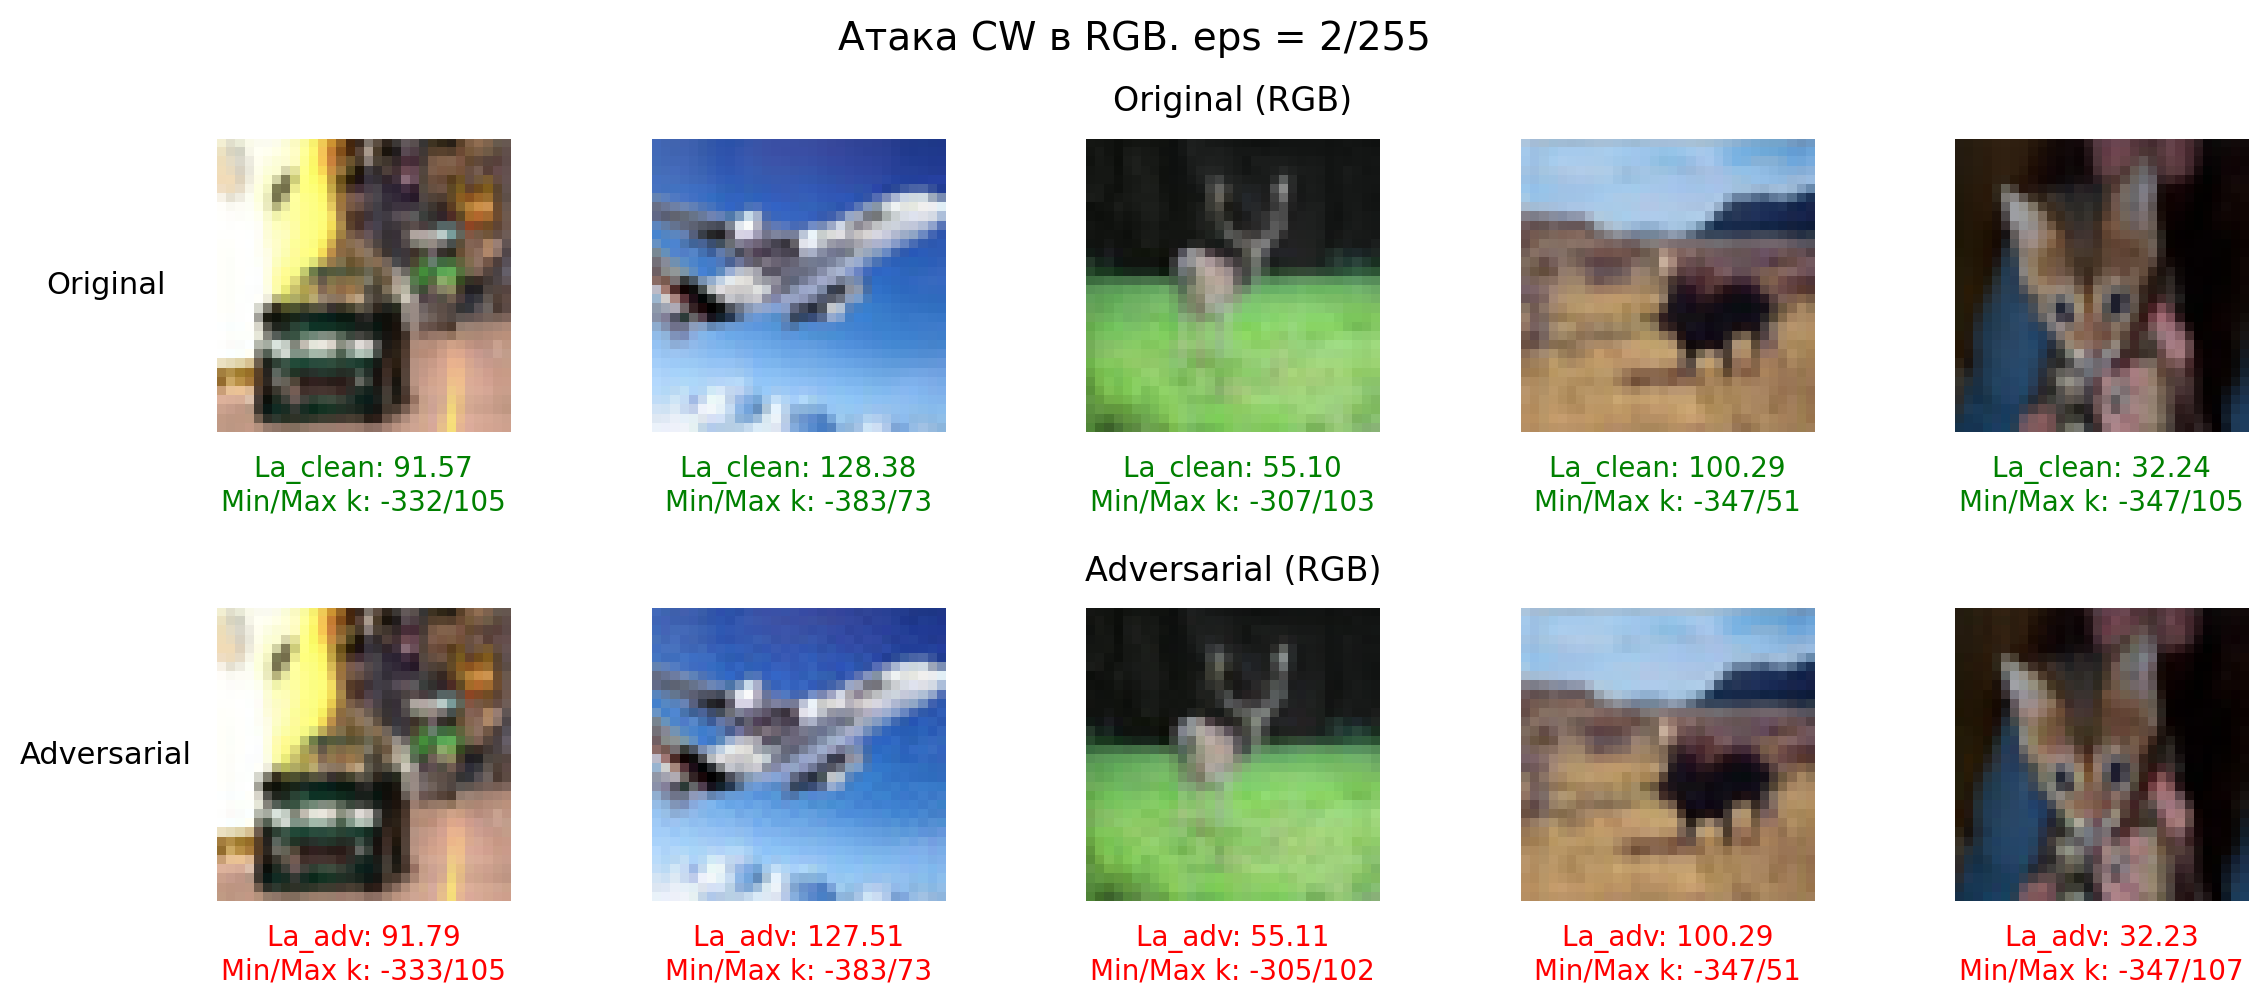

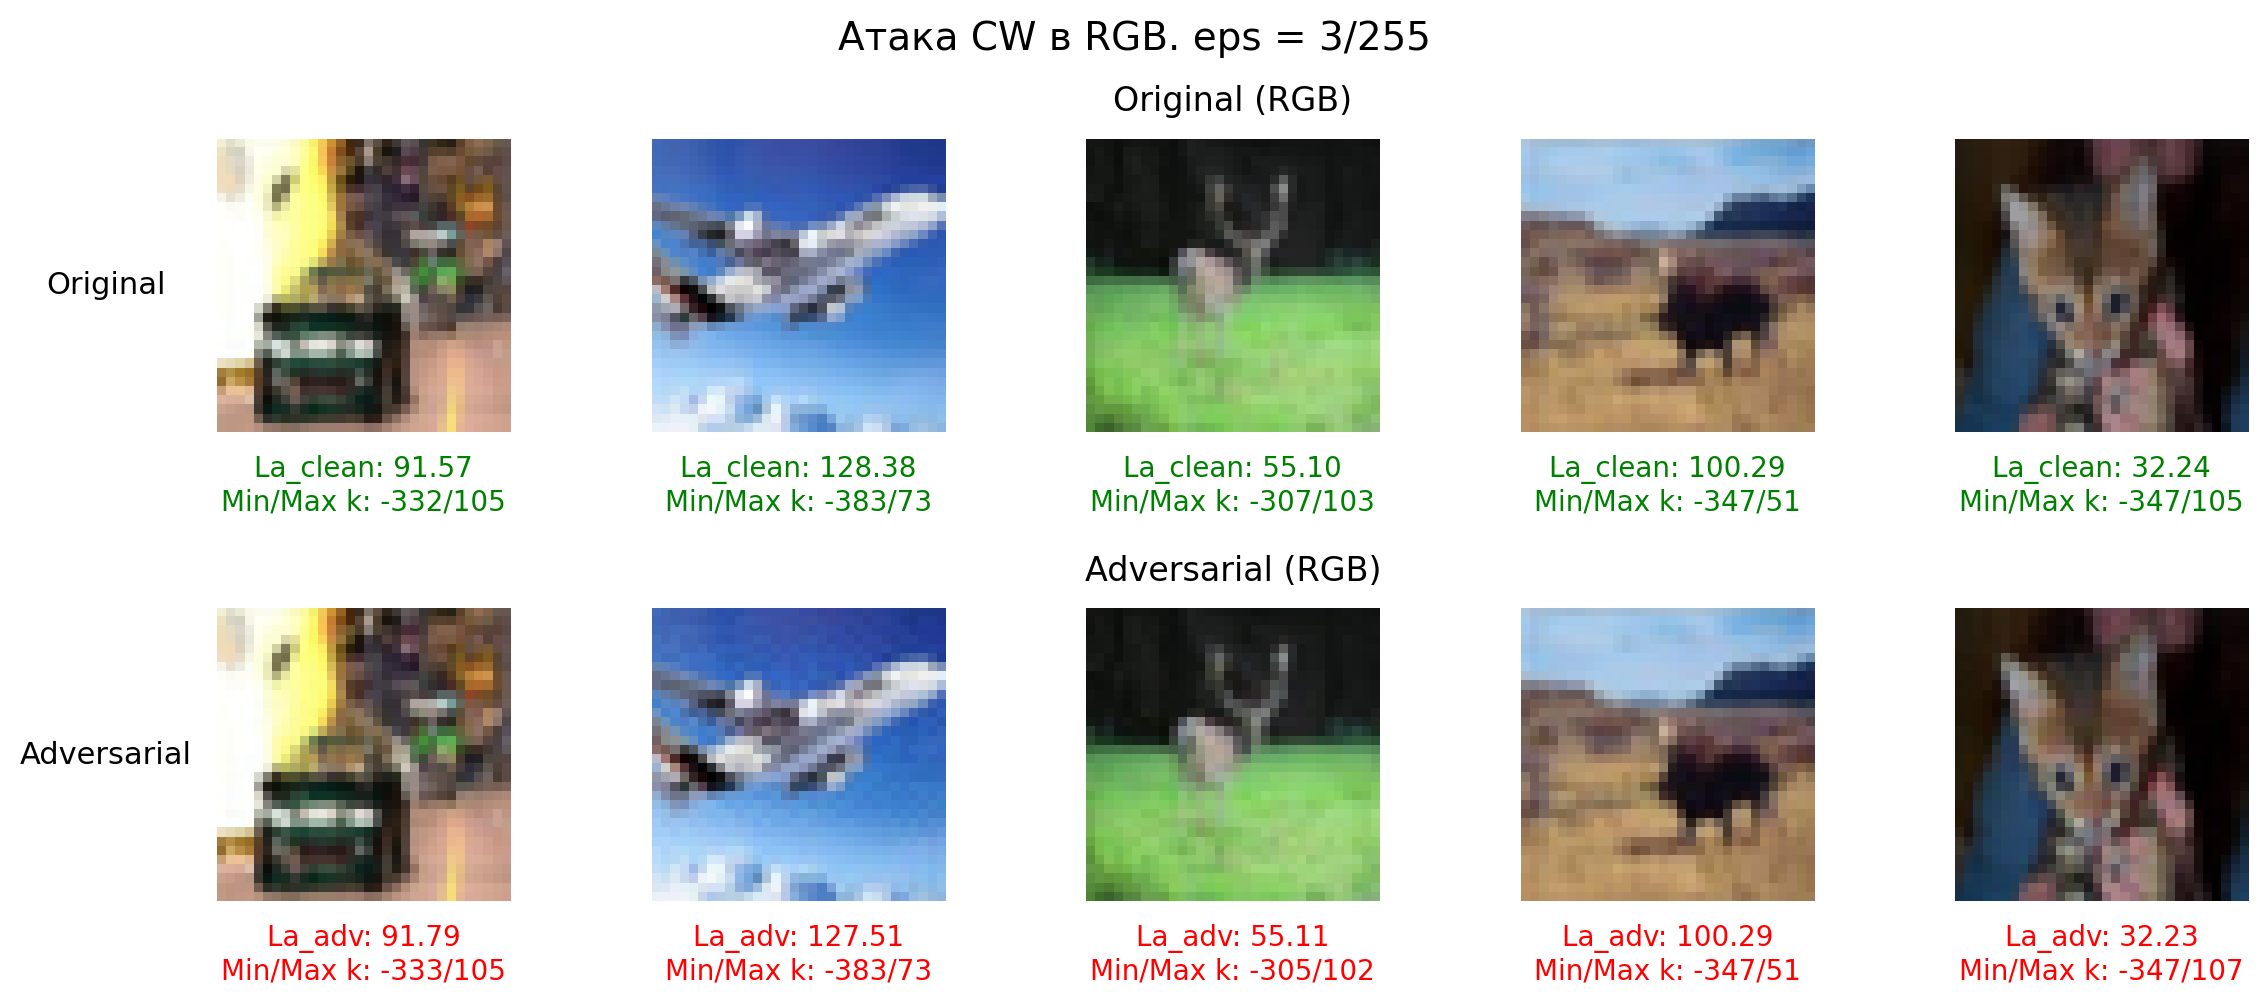

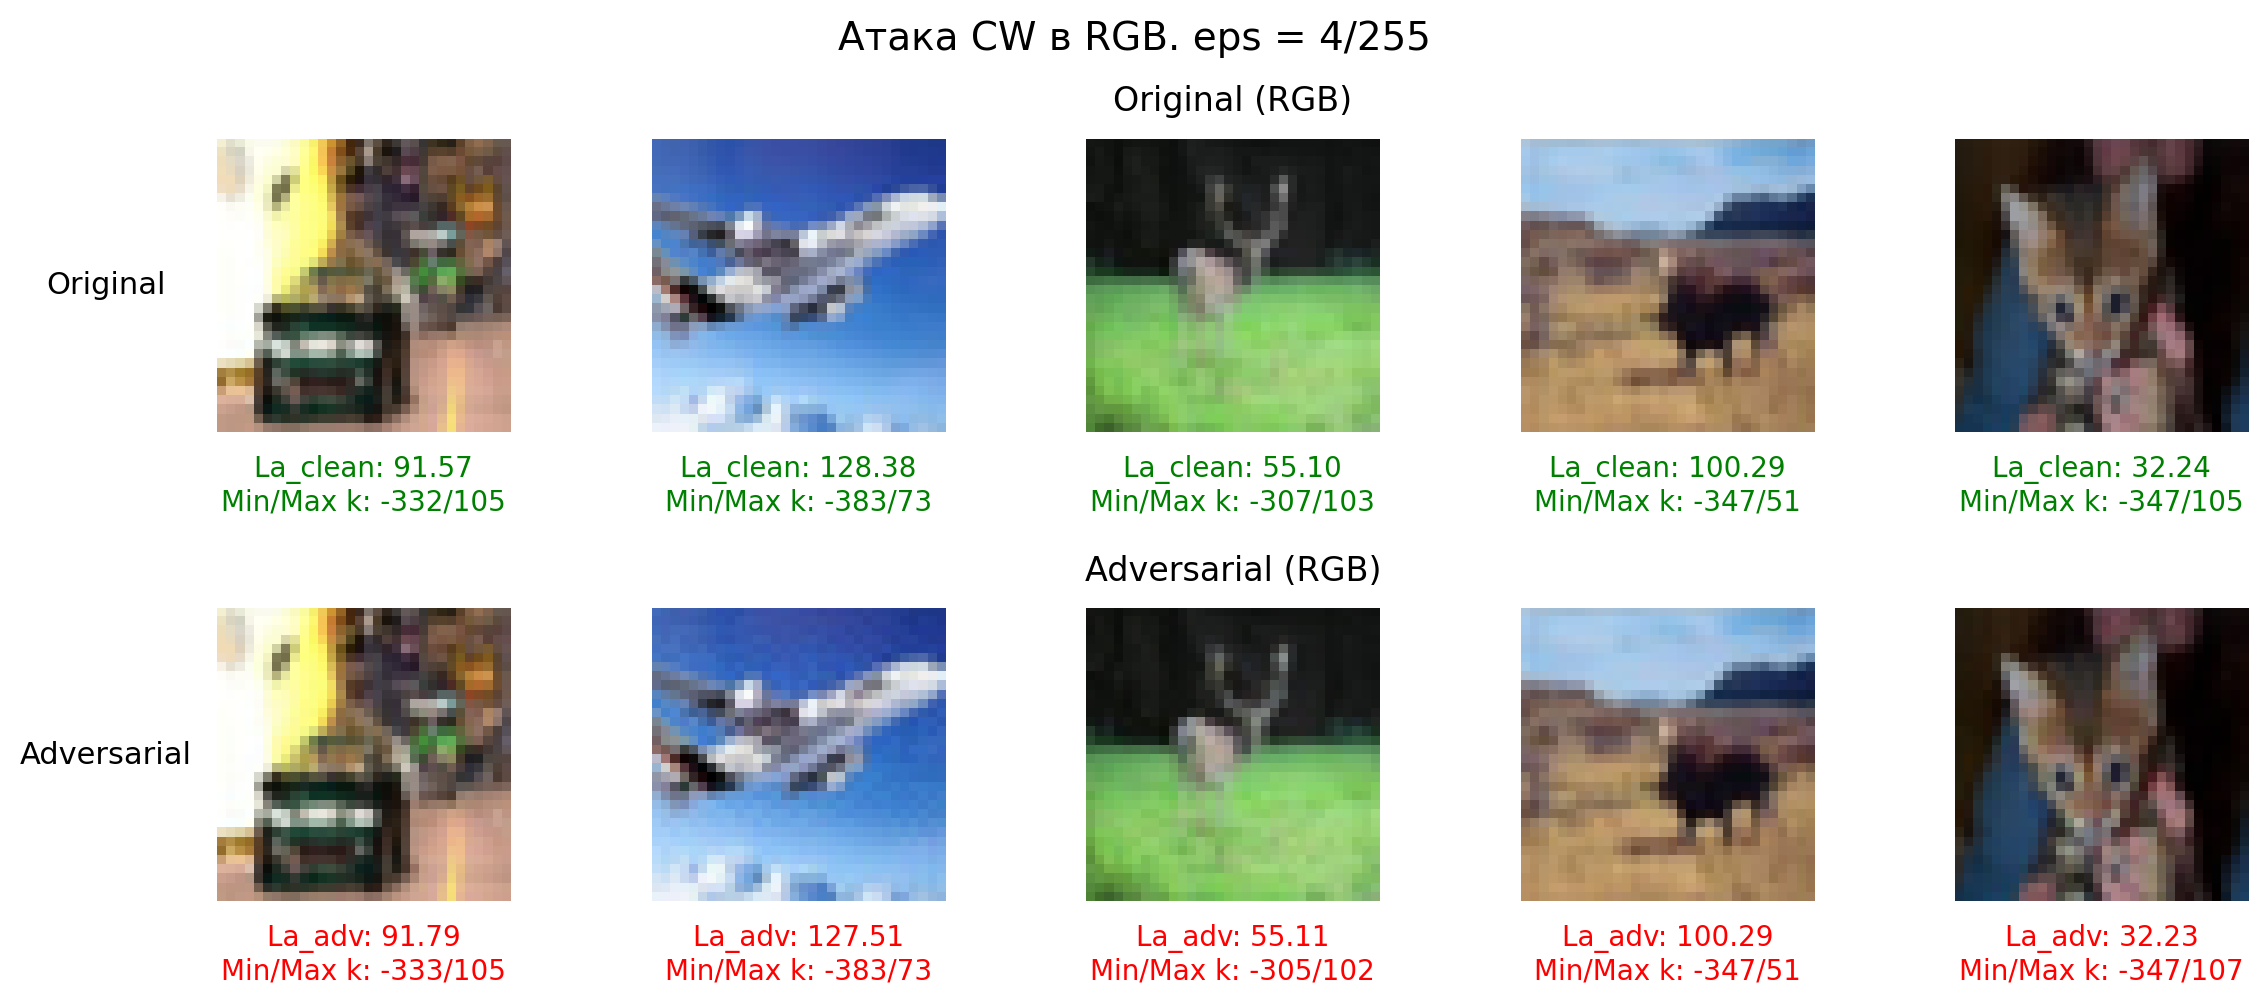

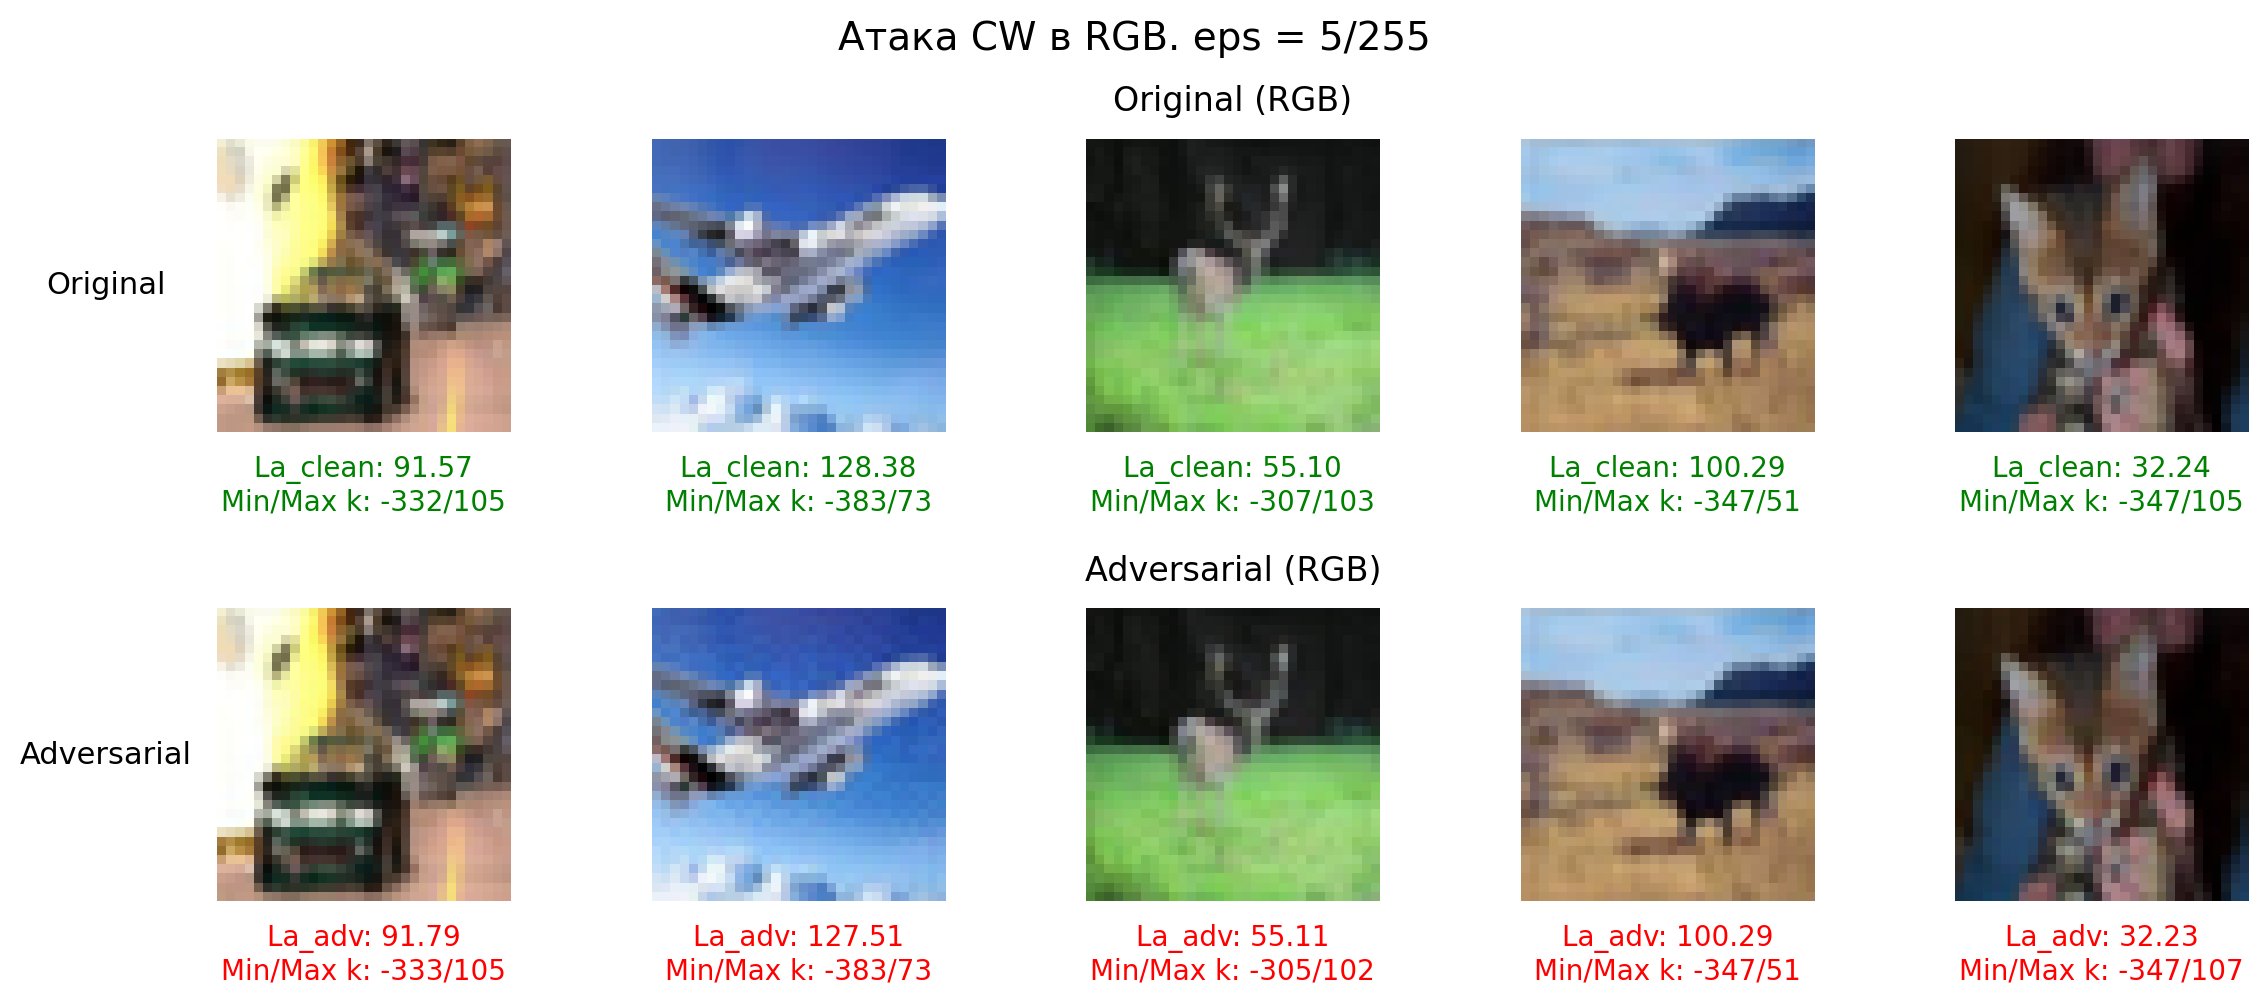

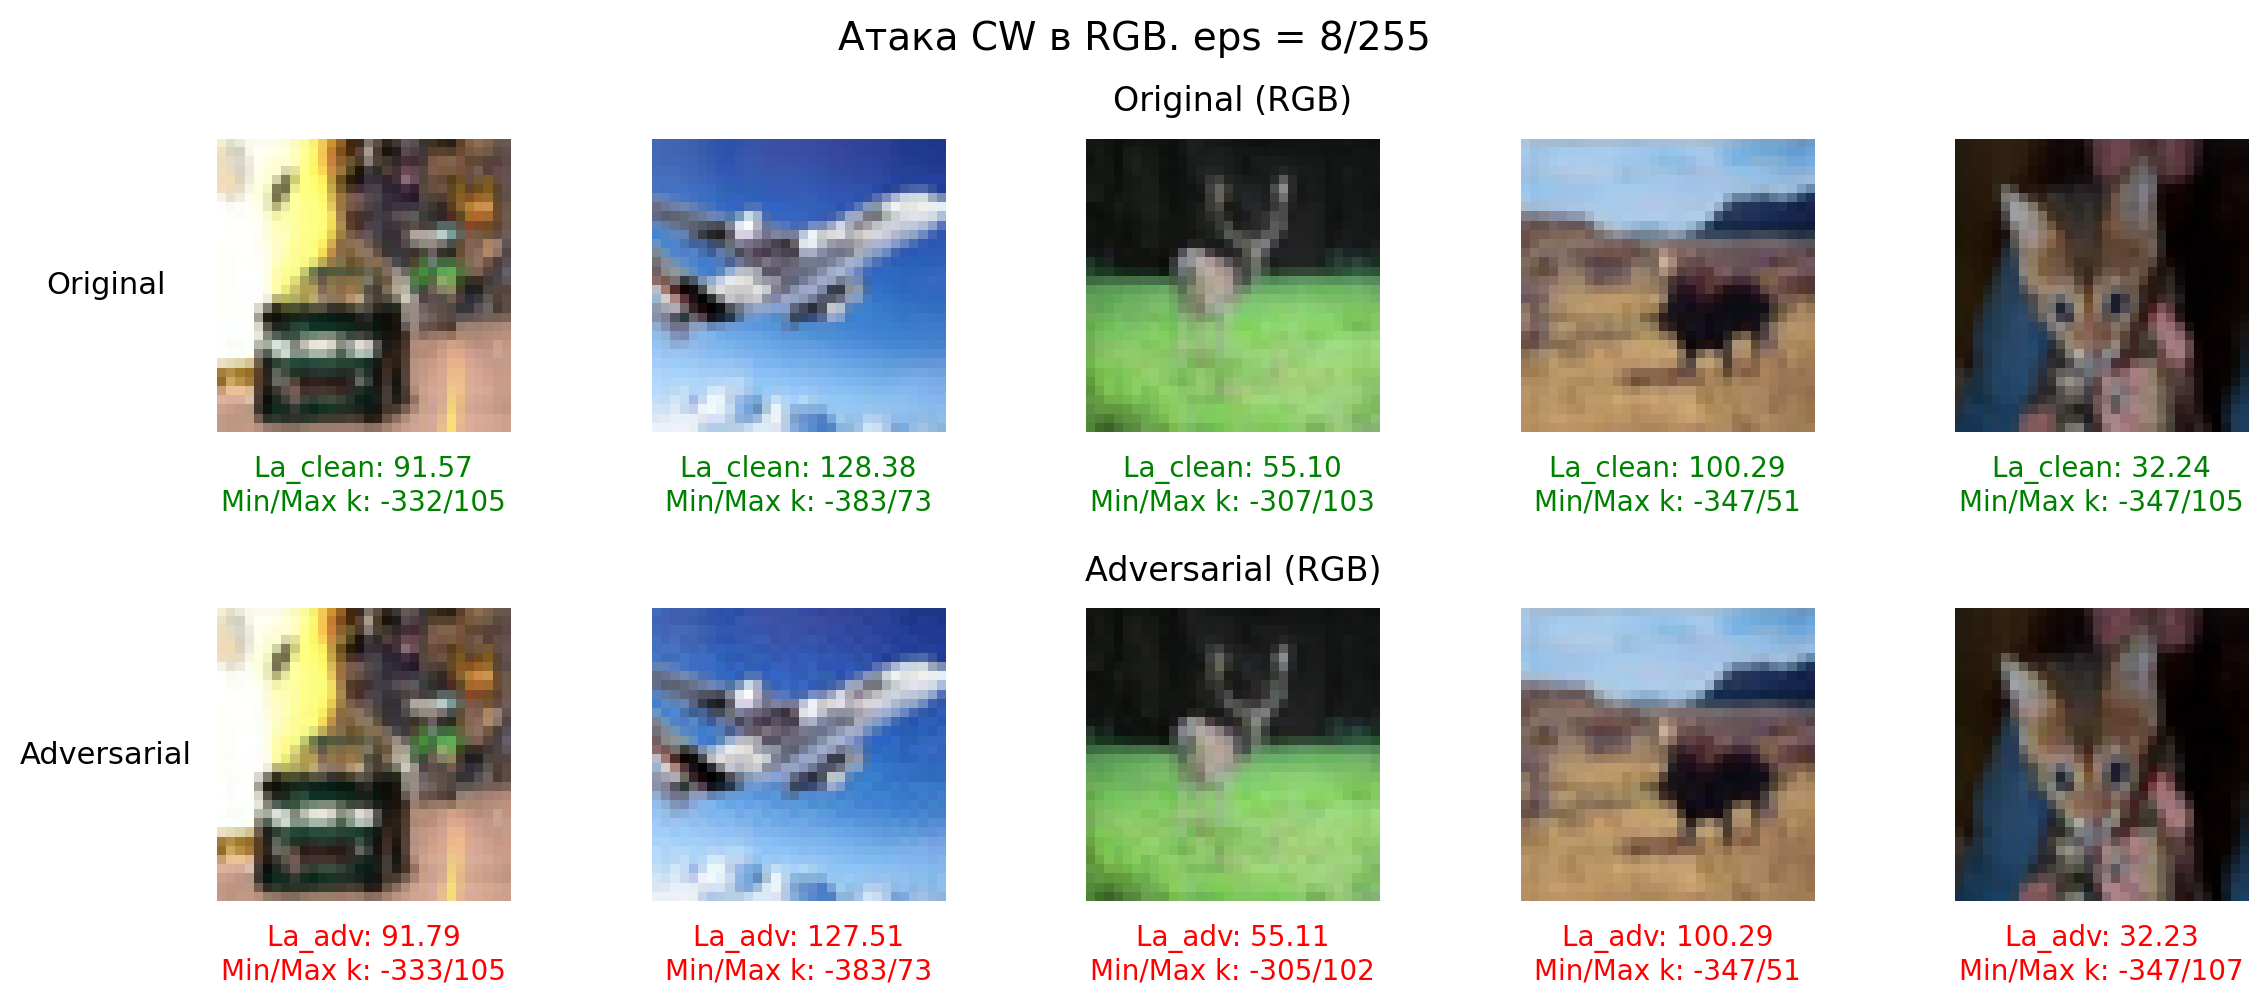

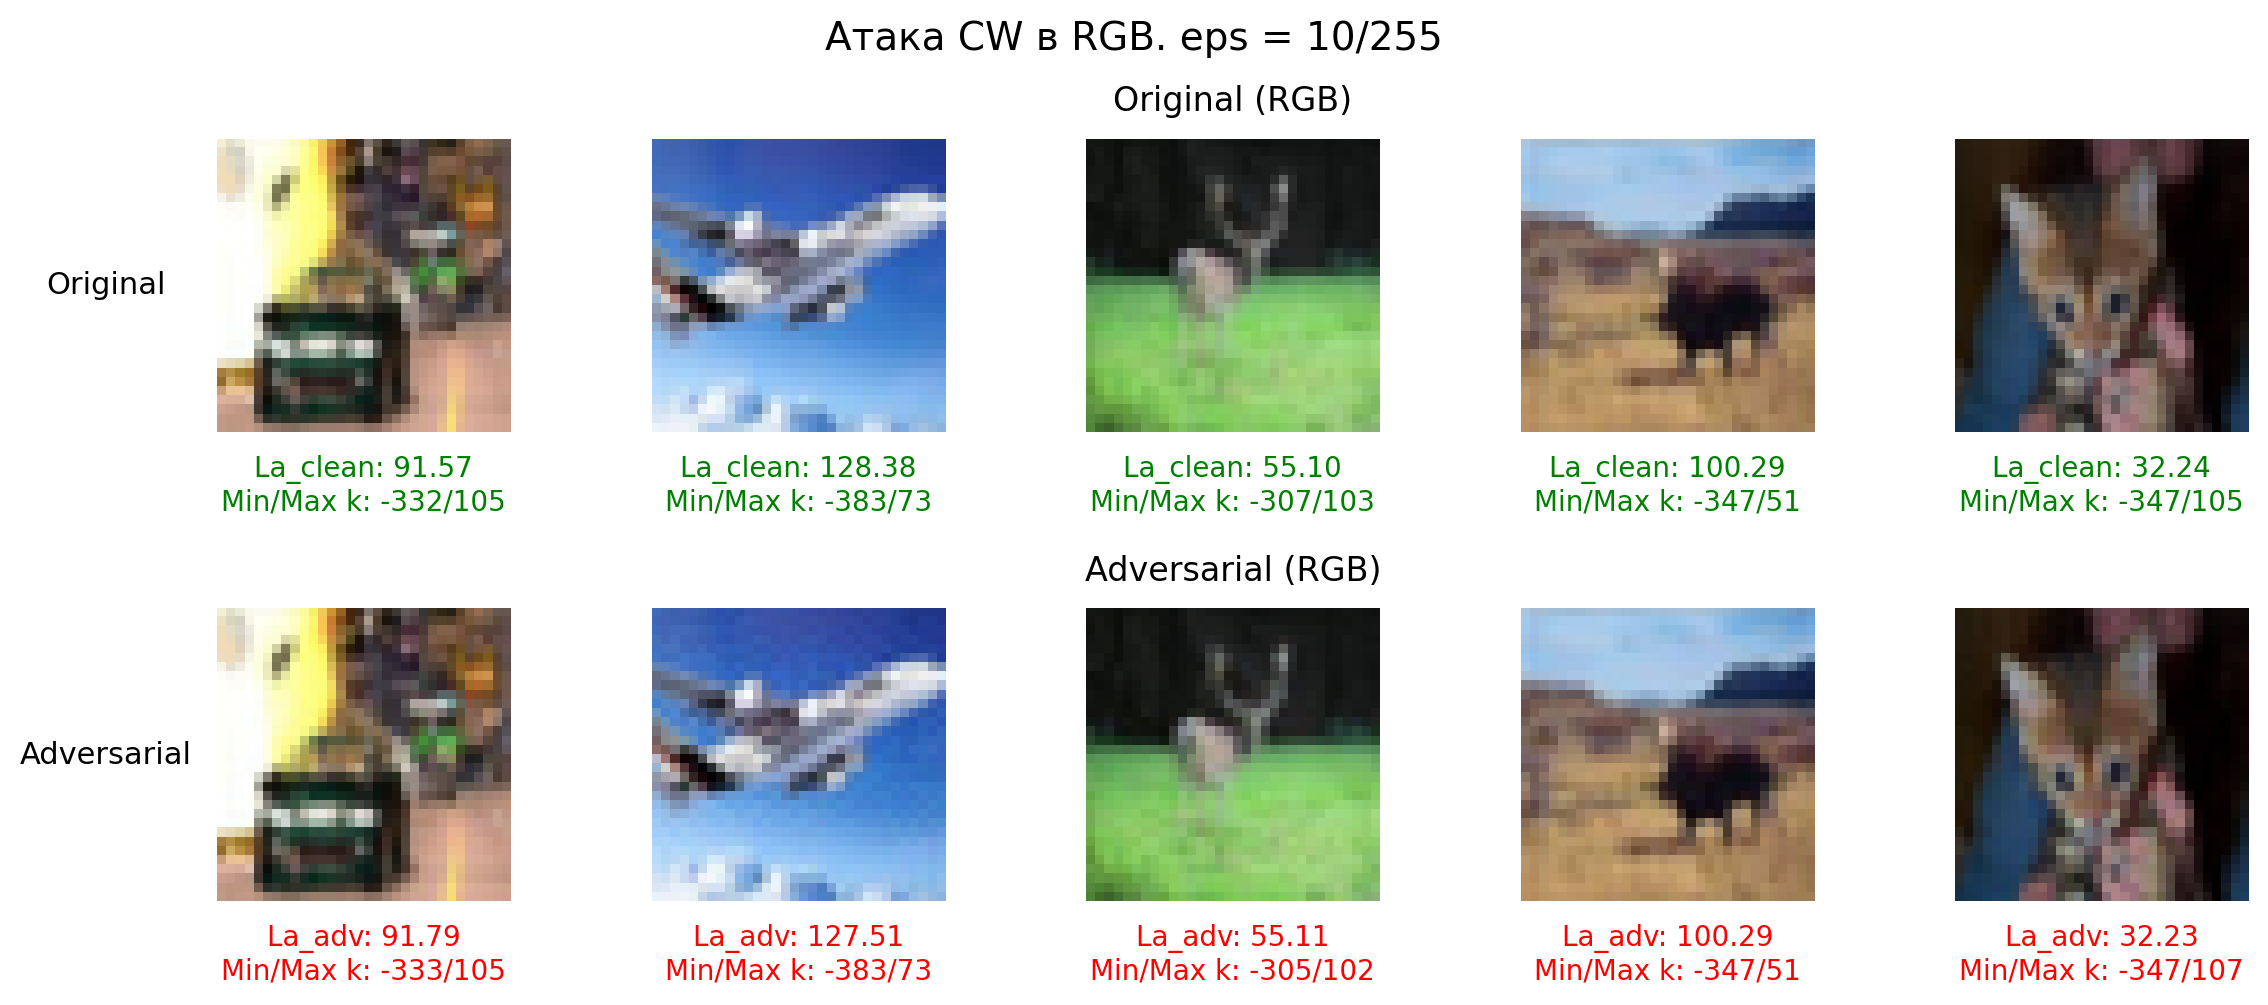

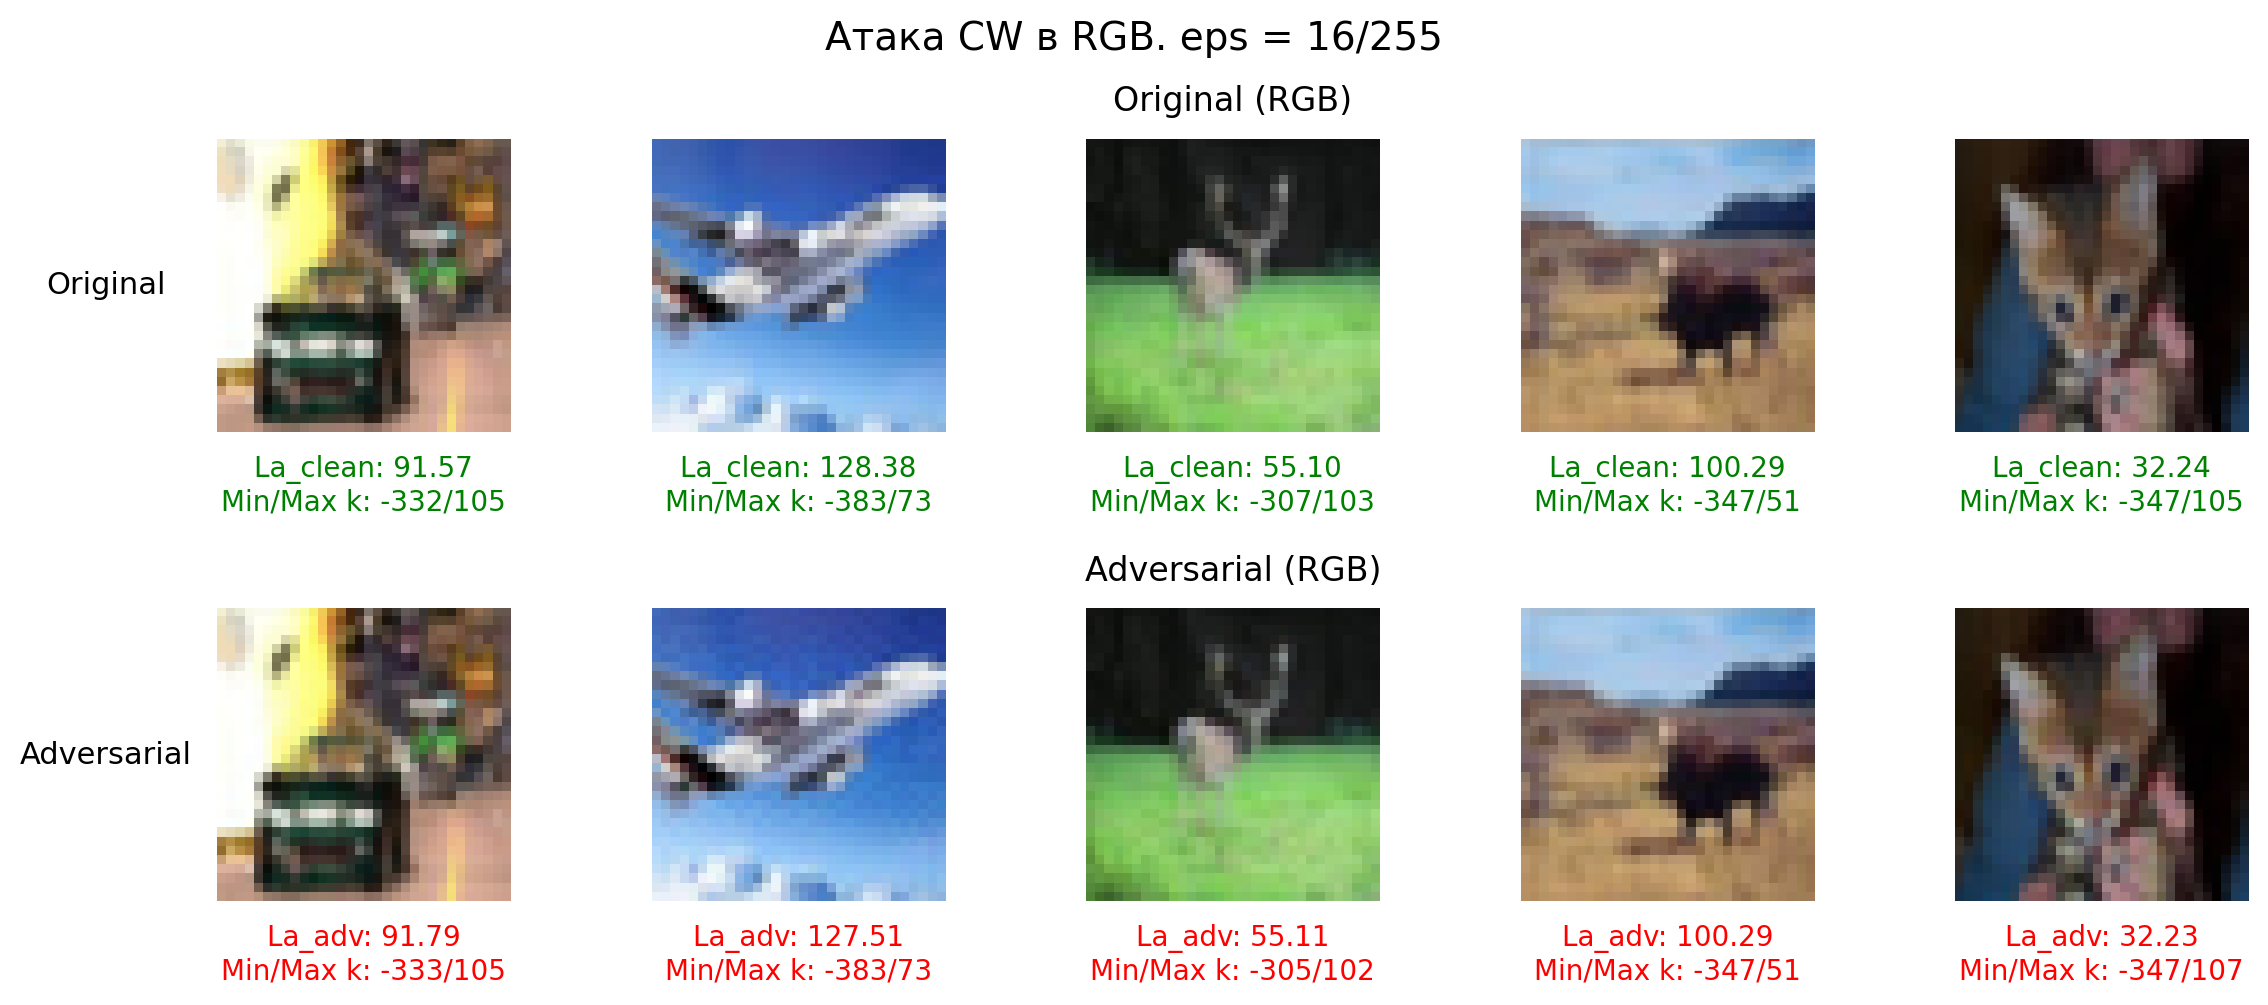

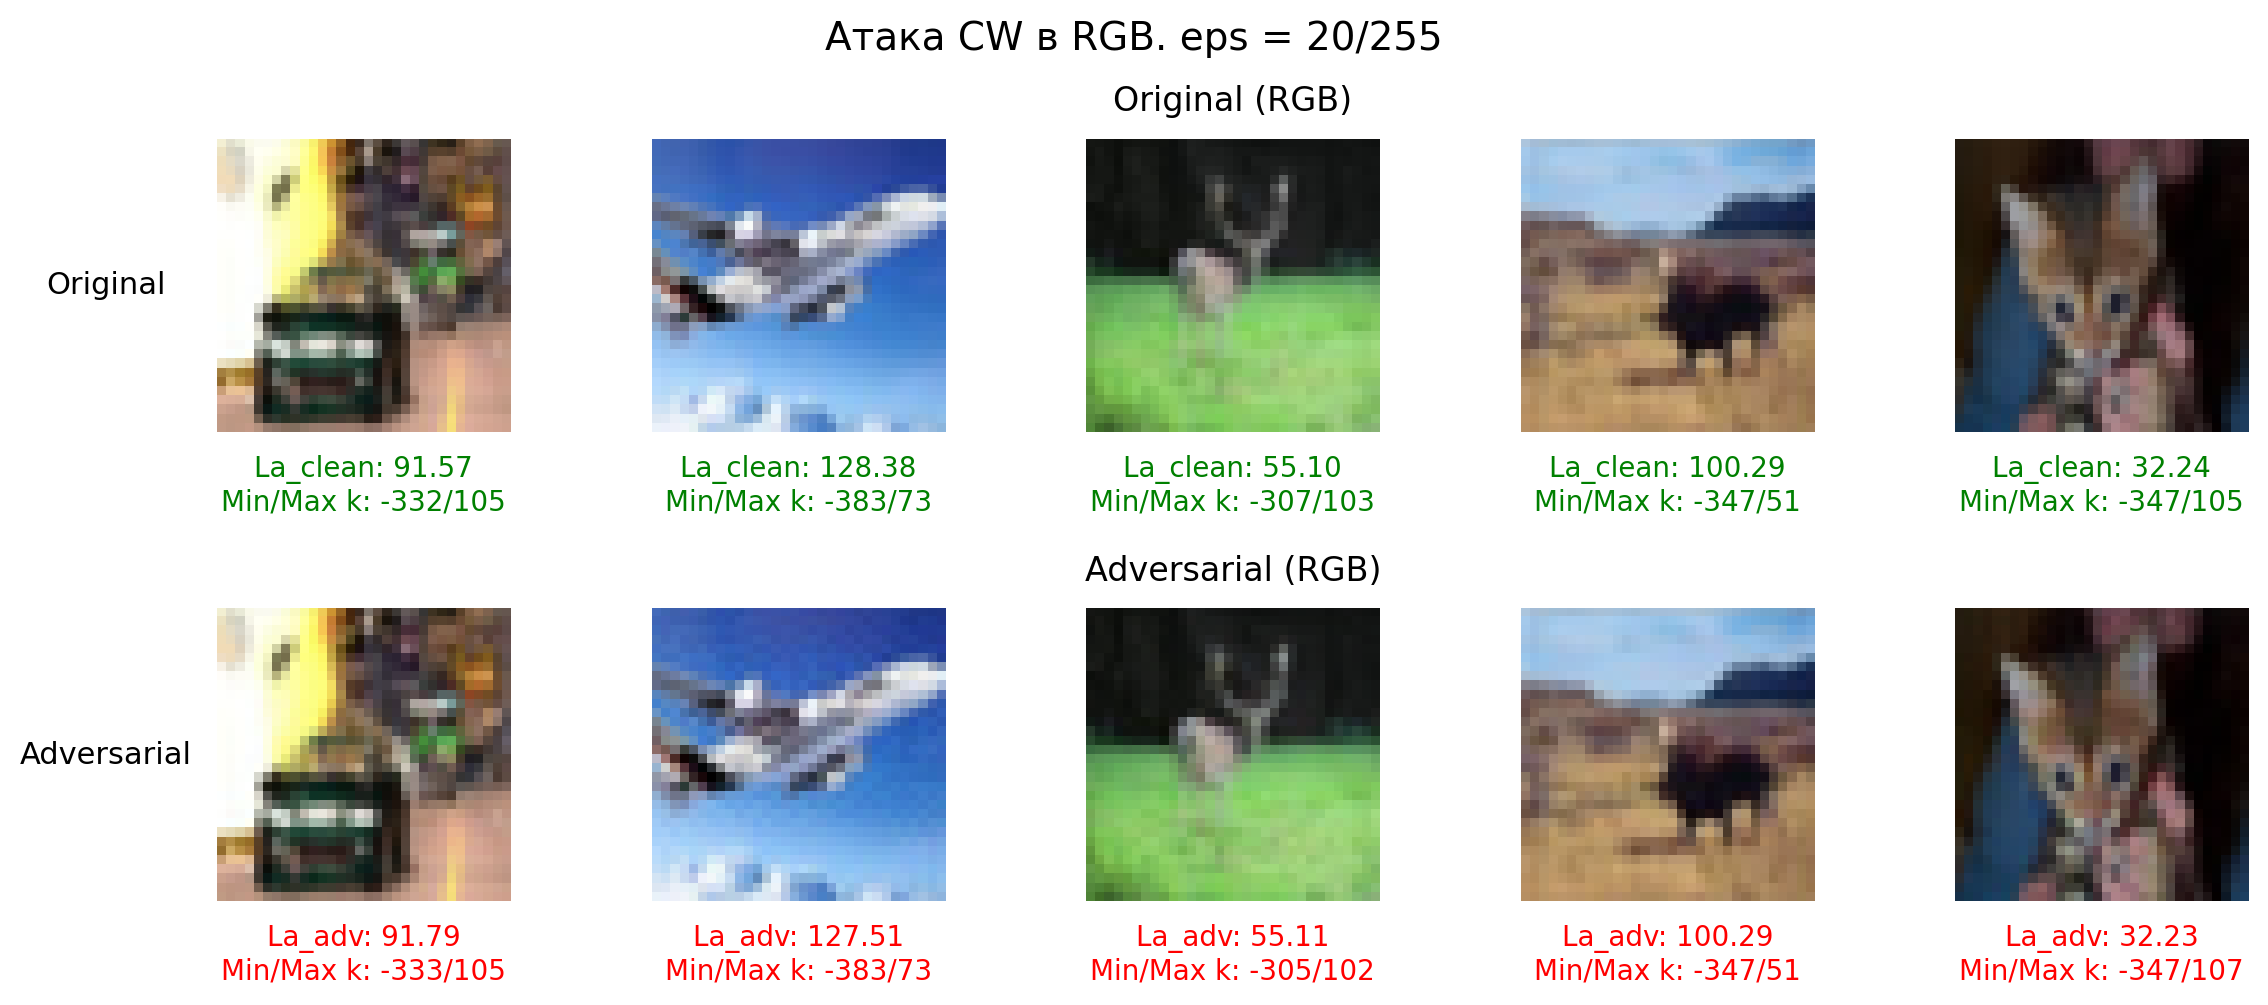

In [92]:
def evaluate_epsilon_robustness(
    model,
    attack_model,
    attack_class,
    loader,
    converter,
    jnd_model,
    L_MIN,
    L_MAX,
    layers="rgb",
    epsilons=None,
    **base_params,
):
    model.eval()
    attack_model.eval()
    device = next(model.parameters()).device

    acc_drop_series = []

    for eps in tqdm(epsilons, desc=f"Тестирование eps для {layers}", leave=False):
        if eps == 0.0:
            total_correct = 0
            total_images = 0
            for images, labels in tqdm(
                loader, desc="Чистый accuracy", leave=False
            ):
                images, labels = images.to(device), labels.to(device)

                if layers == "rgb":
                    clean_inputs = images
                else:
                    layer_mapping = {
                        "jnd_xyk": "x_y_jnd",
                        "jnd_kkk": "jnd_jnd_jnd",
                        "jnd_xkz": "X_jnd_Z",
                        "jnd_rkb": "R_jnd_B",
                    }
                    clean_inputs = rgb_tensor_to_tensor(
                        images,
                        converter,
                        jnd_model,
                        L_MIN,
                        L_MAX,
                        layers=layer_mapping.get(layers),
                    )

                with torch.no_grad():
                    outputs = model(clean_inputs)
                    _, predicted = torch.max(outputs.data, 1)
                    total_correct += (predicted == labels).sum().item()
                    total_images += len(labels)

            acc_drop_series.append(100 * total_correct / total_images)
            continue

        current_params = base_params.copy()
        if attack_class in [torchattacks.FGSM, torchattacks.BIM, torchattacks.PGD]:
            current_params["eps"] = eps
            if "alpha" in current_params:
                current_params["alpha"] = eps / 4
        elif attack_class == torchattacks.CW:
            if eps > 0:
                current_params["c"] = base_params.get("c", 1) * (eps * 255 / 8)

        attack = attack_class(attack_model, **current_params)

        total_adv_correct = 0
        total_images = 0

        for images, labels in tqdm(
            loader, desc=f"Атака eps = {eps:.4f}", leave=False
        ):
            images, labels = images.to(device), labels.to(device)

            try:
                adv_images_rgb = attack(images, labels)
            except:
                adv_images_rgb = images

            visualization_key = (attack_class.__name__, eps)
            if visualization_key not in rgb_visualizations and len(rgb_visualizations) < (4 * len(epsilons)):
                saved_samples = []
                take = min(5, images.size(0))
                for idx in range(take):
                    orig_img = (
                        images[idx].permute(1, 2, 0).cpu().numpy().clip(0, 1)
                    )
                    adv_img = (
                        adv_images_rgb[idx]
                        .permute(1, 2, 0)
                        .cpu()
                        .numpy()
                        .clip(0, 1)
                    )
                    diff = np.abs(orig_img - adv_img)
                    if diff.max() > 0:
                        diff = diff / diff.max()
                    else:
                        diff = np.zeros_like(orig_img)
                    saved_samples.append((orig_img, adv_img, diff))
                if len(saved_samples) == 5:
                    rgb_visualizations[visualization_key] = saved_samples

            if layers == "rgb":
                adv_inputs = adv_images_rgb
            else:
                layer_mapping = {
                    "jnd_xyk": "x_y_jnd",
                    "jnd_kkk": "jnd_jnd_jnd",
                    "jnd_xkz": "X_jnd_Z",
                    "jnd_rkb": "R_jnd_B",
                }
                adv_inputs = rgb_tensor_to_tensor(
                    adv_images_rgb,
                    converter,
                    jnd_model,
                    L_MIN,
                    L_MAX,
                    layers=layer_mapping.get(layers),
                )

            with torch.no_grad():
                outputs_adv = model(adv_inputs)
                _, predicted_adv = torch.max(outputs_adv.data, 1)
                total_adv_correct += (predicted_adv == labels).sum().item()
                total_images += len(labels)

        acc_drop_series.append(100 * total_adv_correct / total_images)

    return acc_drop_series

def get_physical_luminance(img_rgb):
    img_input = np.clip(img_rgb, 0, 1).astype(np.float64) 
    linRGBimg = converter.Inverse_sRGB_Companding(img_input)
    XYZ_image = converter.Linear_RGB_to_XYZ(linRGBimg)
    Y_relative = XYZ_image[..., 1]
    return L_MIN + (L_MAX - L_MIN) * Y_relative

L_MIN = 0.1
L_MAX = 300.0
converter = ImageConverter()
jnd_model = JNDModel(L_MIN, L_MAX)

eps_values = [
    0,
    1 / 255,
    2 / 255,
    3 / 255,
    4 / 255,
    5 / 255,
    8 / 255,
    10 / 255,
    16 / 255,
    20 / 255,
]

models_dict = {
    "rgb": model_rgb,
    "jnd_xyk": model_jnd,
    "jnd_kkk": model_3jnd,
    "jnd_xkz": model_XjndZ,
    "jnd_rkb": model_RjndB,
}

attacks_list = [
    (torchattacks.FGSM, {}),
    (torchattacks.BIM, {"steps": 10, "alpha": 2/255}),
    (torchattacks.PGD, {"steps": 10, "alpha": 1/255, "random_start": True}),
    (torchattacks.CW, {"c": 1, "kappa": 0, "steps": 50, "lr": 0.01})
]

all_results = {}
rgb_visualizations = {}

for attack_class, base_attack_params in attacks_list:
    attack_name = attack_class.__name__
    print(f"Атака: {attack_name}")
    all_results[attack_name] = {}
    
    for layer_type, current_model in tqdm(
        models_dict.items(), desc=f"Модели под {attack_name}"
    ):
        accuracies = evaluate_epsilon_robustness(
            model=current_model,
            attack_model=current_model,
            attack_class=attack_class,
            loader=val_loader_1000_rgb,
            converter=converter,
            jnd_model=jnd_model,
            L_MIN=L_MIN,
            L_MAX=L_MAX,
            layers=layer_type,
            epsilons=eps_values,
            **base_attack_params,
        )
        all_results[attack_name][layer_type] = accuracies

for attack_name in all_results.keys():
    plt.figure(figsize=(10, 6), dpi=150)
    linestyles = ["-", "--", "-.", ":", (0, (3, 5, 1, 5))]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    eps_labels = [f"{int(round(e*255))}/255" if e > 0 else "0" for e in eps_values]
     
    for i, (layer_type, acc_list) in enumerate(all_results[attack_name].items()):
        plt.plot(
            eps_values,
            acc_list,
            marker=".",
            linestyle=linestyles[i % len(linestyles)],
            color=colors[i % len(colors)],
            linewidth=2,
            markersize=7,
            label=f"Модель: {layer_type}",
        )

    plt.title(f"Устойчивость моделей к атаке {attack_name} при разных eps", fontsize=14, pad=15)
    plt.xlabel("Сила возмущения eps", fontsize=12)
    plt.ylabel("Accuracy (%)", fontsize=12)
    plt.xticks(eps_values, eps_labels, rotation=45)
    plt.ylim(-5, 105)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=11, loc="upper right")
    plt.tight_layout()
    plt.show()

print('Визуализация атак при разных eps')

for (attack_name, eps), samples in rgb_visualizations.items():
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(
        f"Атака {attack_name} в RGB. eps = {int(round(eps*255))}/255" if eps > 0 else f"Атака {attack_name} в RGB. Clean",
        fontsize=14
    )

    axes[0, 0].set_ylabel("Original", fontsize=11, rotation=0, labelpad=40, verticalalignment='center')
    axes[1, 0].set_ylabel("Adversarial", fontsize=11, rotation=0, labelpad=40, verticalalignment='center')

    for idx, (orig, adv, diff) in enumerate(samples):
        img_clean = orig
        img_adv = adv
    
        L_physical_clean = get_physical_luminance(img_clean)
        La_clean = jnd_model.find_La(L_physical_clean)
        jnd_model.build_level_boundaries() 
        k_map_clean = jnd_model.L_to_k(L_physical_clean)
    
        L_physical_adv = get_physical_luminance(img_adv)
        La_adv = jnd_model.find_La(L_physical_adv)
        jnd_model.build_level_boundaries()
        k_map_adv = jnd_model.L_to_k(L_physical_adv)
        
        min_k_clean = np.min(k_map_clean)
        max_k_clean = np.max(k_map_clean)
        min_k_adv = np.min(k_map_adv)
        max_k_adv = np.max(k_map_adv)
    
        axes[0, idx].imshow(np.clip(img_clean, 0, 1))
        axes[0, idx].set_xticks([])
        axes[0, idx].set_yticks([])
        if idx == 2: 
            axes[0, idx].set_title("Original (RGB)", fontsize=12, pad=10)
        
        clean_text = f"La_clean: {La_clean:.2f}\nMin/Max k: {int(min_k_clean)}/{int(max_k_clean)}"
        axes[0, idx].set_xlabel(clean_text, color="green", fontsize=10, labelpad=8)
            
        axes[1, idx].imshow(np.clip(img_adv, 0, 1))
        axes[1, idx].set_xticks([])
        axes[1, idx].set_yticks([])
        if idx == 2: 
            axes[1, idx].set_title("Adversarial (RGB)", fontsize=12, pad=10)
        
        adv_text = f"La_adv: {La_adv:.2f}\nMin/Max k: {int(min_k_adv)}/{int(max_k_adv)}"
        axes[1, idx].set_xlabel(adv_text, color="red", fontsize=10, labelpad=8)

    for row in range(2):
        for col in range(5):
            axes[row, col].spines['top'].set_visible(False)
            axes[row, col].spines['right'].set_visible(False)
            axes[row, col].spines['bottom'].set_visible(False)
            axes[row, col].spines['left'].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.6)
    plt.show()